# KRITIS–Philippines: Typhoon × Grid Disruption Screening

This notebook implements a first-pass **topological screening model** of typhoon-induced transmission grid disruption in the Philippines.

It combines three data layers into a unified benchmark system:

- **Hazard:** IBTrACS tropical cyclone track data (West Pacific)
- **Infrastructure:** PyPSA-PH transmission buses, lines, and generators
- **Exposure:** WorldPop gridded population data

The preferred model specification (**v5r**) includes:

- stylized wind-field hazard representation  
- sampled line-level hazard estimation  
- threshold-based cumulative line failure  
- unique nearest-bus population assignment  
- **capacity-aware relative adequacy** service screening  

## Interpretation and scope

This model is designed as a **comparative stress test on a common benchmark network**, not as a reconstruction of historical outages.

It evaluates how different typhoon events would affect the *same stylized system* under a consistent set of assumptions.

Key simplifications:

- static benchmark transmission network  
- fixed contemporary population distribution  
- stylized hazard field (no full wind-field reconstruction)  
- threshold-based or stylized probabilistic line failure  
- graph-based service logic (no AC/DC power flow)  
- no restoration dynamics  
- no historical infrastructure build-out by event year  

The objective is therefore:

> **to identify and compare potentially high-impact events under a transparent and internally consistent screening framework**

## How to read this notebook

The notebook is structured as a sequence of analytical modules:

1. **Case justification and hazard context**  
2. **Benchmark system construction (hazard, network, population)**  
3. **Core simulation loop (failure → disruption → impact)**  
4. **Event-level diagnostics and time series**  
5. **Catalogue-wide ranking and comparison**  
6. **Optional stochastic extensions and visual outputs**

## Why the Philippines as a case study?

The Philippines is used as a **defensible benchmark case** based on four aligned considerations:

1. **Physical / geographic logic**  
   The country lies within one of the most active tropical cyclone basins globally.

2. **Empirical / disaster-statistical logic**  
   Tropical cyclones are a central and recurrent hazard class in the national disaster record.

3. **Infrastructure logic**  
   The archipelagic transmission system is structurally prone to **corridor stress, fragmentation, and component separation**, making it well-suited for a topological disruption model.

4. **Data logic**  
   Hazard, infrastructure, and population datasets are available in compatible forms and can be coherently integrated.

This establishes the Philippines as a **well-suited benchmark environment**, not a uniquely optimal or exclusive case.

## Empirical hazard context (EM-DAT)

Historical disaster records support the structural relevance of tropical cyclones:

- tropical cyclones account for a large share of recorded disaster events  
- they dominate high-impact events in terms of affected population and damages  
- they represent a **recurrent, systemically relevant hazard class**

This motivates their use as the primary hazard driver in the screening model.

## From hazard context to model design

Given this structural hazard context, the modelling approach follows a deliberate simplification strategy:

- construct a **stylized but internally consistent benchmark system**  
- impose a transparent hazard → failure → disruption logic  
- simulate event evolution over time  
- derive comparable **impact metrics and rankings across storms**

The resulting model is not intended to predict exact outcomes, but to:

> **identify relative system stress patterns, exposure concentrations, and potentially critical events**

## Next step

The following sections implement this logic step by step, beginning with:

- data harmonization  
- benchmark network construction  
- and the definition of the core simulation workflow

In [178]:
# =========================
# Cell — Load and prepare EM-DAT (Philippines)
# =========================
# Purpose:
# - load the EM-DAT workbook
# - clean key numeric impact columns
# - create tropical-cyclone indicators used later
# - keep the output minimal and presentation-oriented

import pandas as pd
import numpy as np

PATH = "public_emdat.xlsx"

# -------------------------
# Load workbook
# -------------------------
df = pd.read_excel(PATH, sheet_name="EM-DAT Data").copy()

# -------------------------
# Numeric cleanup
# -------------------------
NUM_COLS = [
    "Total Deaths",
    "No. Injured",
    "No. Affected",
    "No. Homeless",
    "Total Affected",
    "Total Damage ('000 US$)",
    "Total Damage, Adjusted ('000 US$)",
]

for c in NUM_COLS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -------------------------
# Core indicators
# -------------------------
df["is_tc"] = df["Disaster Subtype"].eq("Tropical cyclone")
df["decade"] = (df["Start Year"] // 10) * 10

# Tropical-cyclone-only impact columns
df["tc_deaths"] = np.where(df["is_tc"], df["Total Deaths"], 0)
df["tc_affected"] = np.where(df["is_tc"], df["Total Affected"], 0)
df["tc_damage_adj"] = np.where(df["is_tc"], df["Total Damage, Adjusted ('000 US$)"], 0)

# -------------------------
# Minimal sanity check
# -------------------------
print(f"Rows: {len(df):,}")
print(f"Year range: {int(df['Start Year'].min())}–{int(df['Start Year'].max())}")
print(f"Tropical cyclone records: {int(df['is_tc'].sum()):,}")

Rows: 491
Year range: 2000–2026
Tropical cyclone records: 193


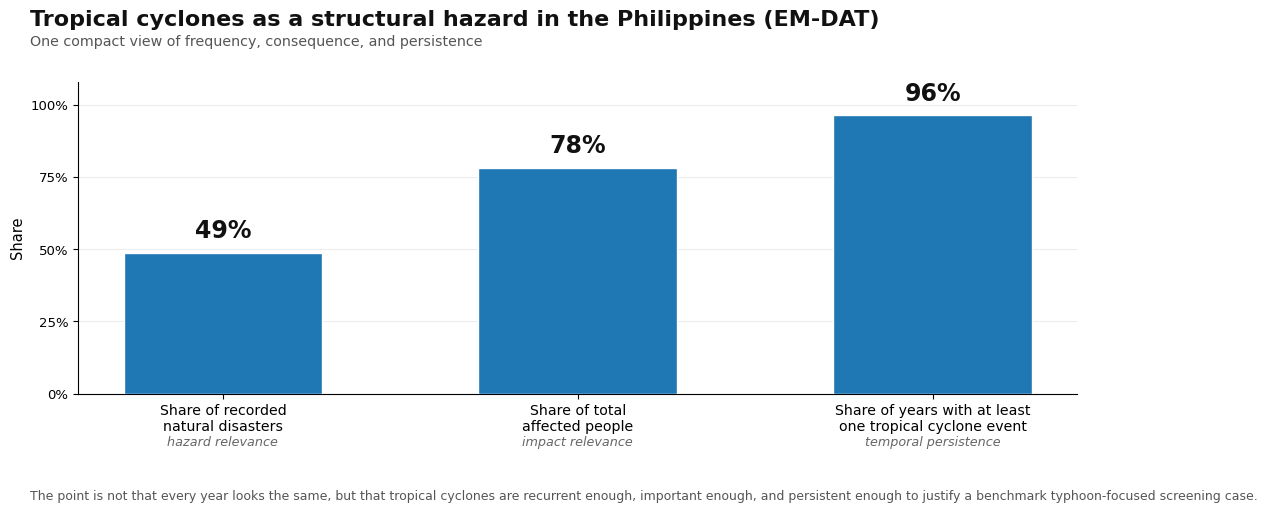


## Interpretation (EM-DAT)

The EM-DAT record supports three connected claims:

- tropical cyclones account for a large share of recorded **natural disasters**
- they account for a substantial share of **affected people**
- they recur across **most years** in the dataset

Taken together, this supports treating typhoon risk in the Philippines as a **structural national hazard context**, not as an isolated or exceptional event class.


In [179]:
# =========================
# Cell — EM-DAT summary: hazard relevance, impact relevance, and persistence
# =========================
# Purpose:
# - combine the main EM-DAT arguments into one compact, presentation-grade figure
# - show that tropical cyclones are frequent, consequential, and persistent
# - avoid fragmented one-line markdown outputs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# -------------------------
# Core metrics
# -------------------------
n_total = len(df)
n_natural = int((df["Disaster Group"] == "Natural").sum())
n_tc = int(df["is_tc"].sum())

share_nat = n_tc / n_natural if n_natural > 0 else np.nan

tc = df[df["is_tc"]].copy()

total_affected = df["Total Affected"].sum(skipna=True)
tc_affected = tc["Total Affected"].sum(skipna=True)
share_affected = (
    tc_affected / total_affected
    if pd.notna(total_affected) and total_affected != 0
    else np.nan
)

annual = (
    df.groupby("Start Year")
      .agg(tc_events=("is_tc", "sum"))
      .reset_index()
      .sort_values("Start Year")
)

years_with_tc = int((annual["tc_events"] > 0).sum())
n_years = len(annual)
share_years = years_with_tc / n_years if n_years > 0 else np.nan

# -------------------------
# Plot data
# -------------------------
labels = [
    "Share of recorded\nnatural disasters",
    "Share of total\naffected people",
    "Share of years with at least\none tropical cyclone event",
]
values = [share_nat, share_affected, share_years]
subnotes = [
    "hazard relevance",
    "impact relevance",
    "temporal persistence",
]

# -------------------------
# Figure
# -------------------------
fig, ax = plt.subplots(figsize=(11.8, 5.1), facecolor="white")

x = np.arange(len(values))
bars = ax.bar(
    x,
    values,
    width=0.56,
    edgecolor="white",
    linewidth=1.0,
    zorder=3,
)

# value labels
for xi, val in zip(x, values):
    ax.text(
        xi,
        val + 0.035,
        f"{val:.0%}",
        ha="center",
        va="bottom",
        fontsize=17,
        fontweight="bold",
        color="#111111",
    )

# subnotes below bars
for xi, txt in zip(x, subnotes):
    ax.text(
        xi,
        -0.145,
        txt,
        ha="center",
        va="top",
        fontsize=9.2,
        color="#666666",
        style="italic",
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10.2)
ax.set_ylim(0, 1.08)
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=9.5)
ax.set_ylabel("Share", fontsize=10.5)

ax.grid(axis="y", alpha=0.22, zorder=0)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.08, 0.96,
    "Tropical cyclones as a structural hazard in the Philippines (EM-DAT)",
    ha="left",
    fontsize=16,
    fontweight="bold",
    color="#111111",
)
fig.text(
    0.08, 0.92,
    "One compact view of frequency, consequence, and persistence",
    ha="left",
    fontsize=10.3,
    color="#555555",
)
fig.text(
    0.08, 0.03,
    "The point is not that every year looks the same, but that tropical cyclones are recurrent enough, "
    "important enough, and persistent enough to justify a benchmark typhoon-focused screening case.",
    ha="left",
    fontsize=9.0,
    color="#555555",
)

from IPython.display import display, Markdown

plt.tight_layout(rect=[0.05, 0.08, 0.98, 0.88])
plt.show()

display(Markdown("""
## Interpretation (EM-DAT)

The EM-DAT record supports three connected claims:

- tropical cyclones account for a large share of recorded **natural disasters**
- they account for a substantial share of **affected people**
- they recur across **most years** in the dataset

Taken together, this supports treating typhoon risk in the Philippines as a **structural national hazard context**, not as an isolated or exceptional event class.
"""))

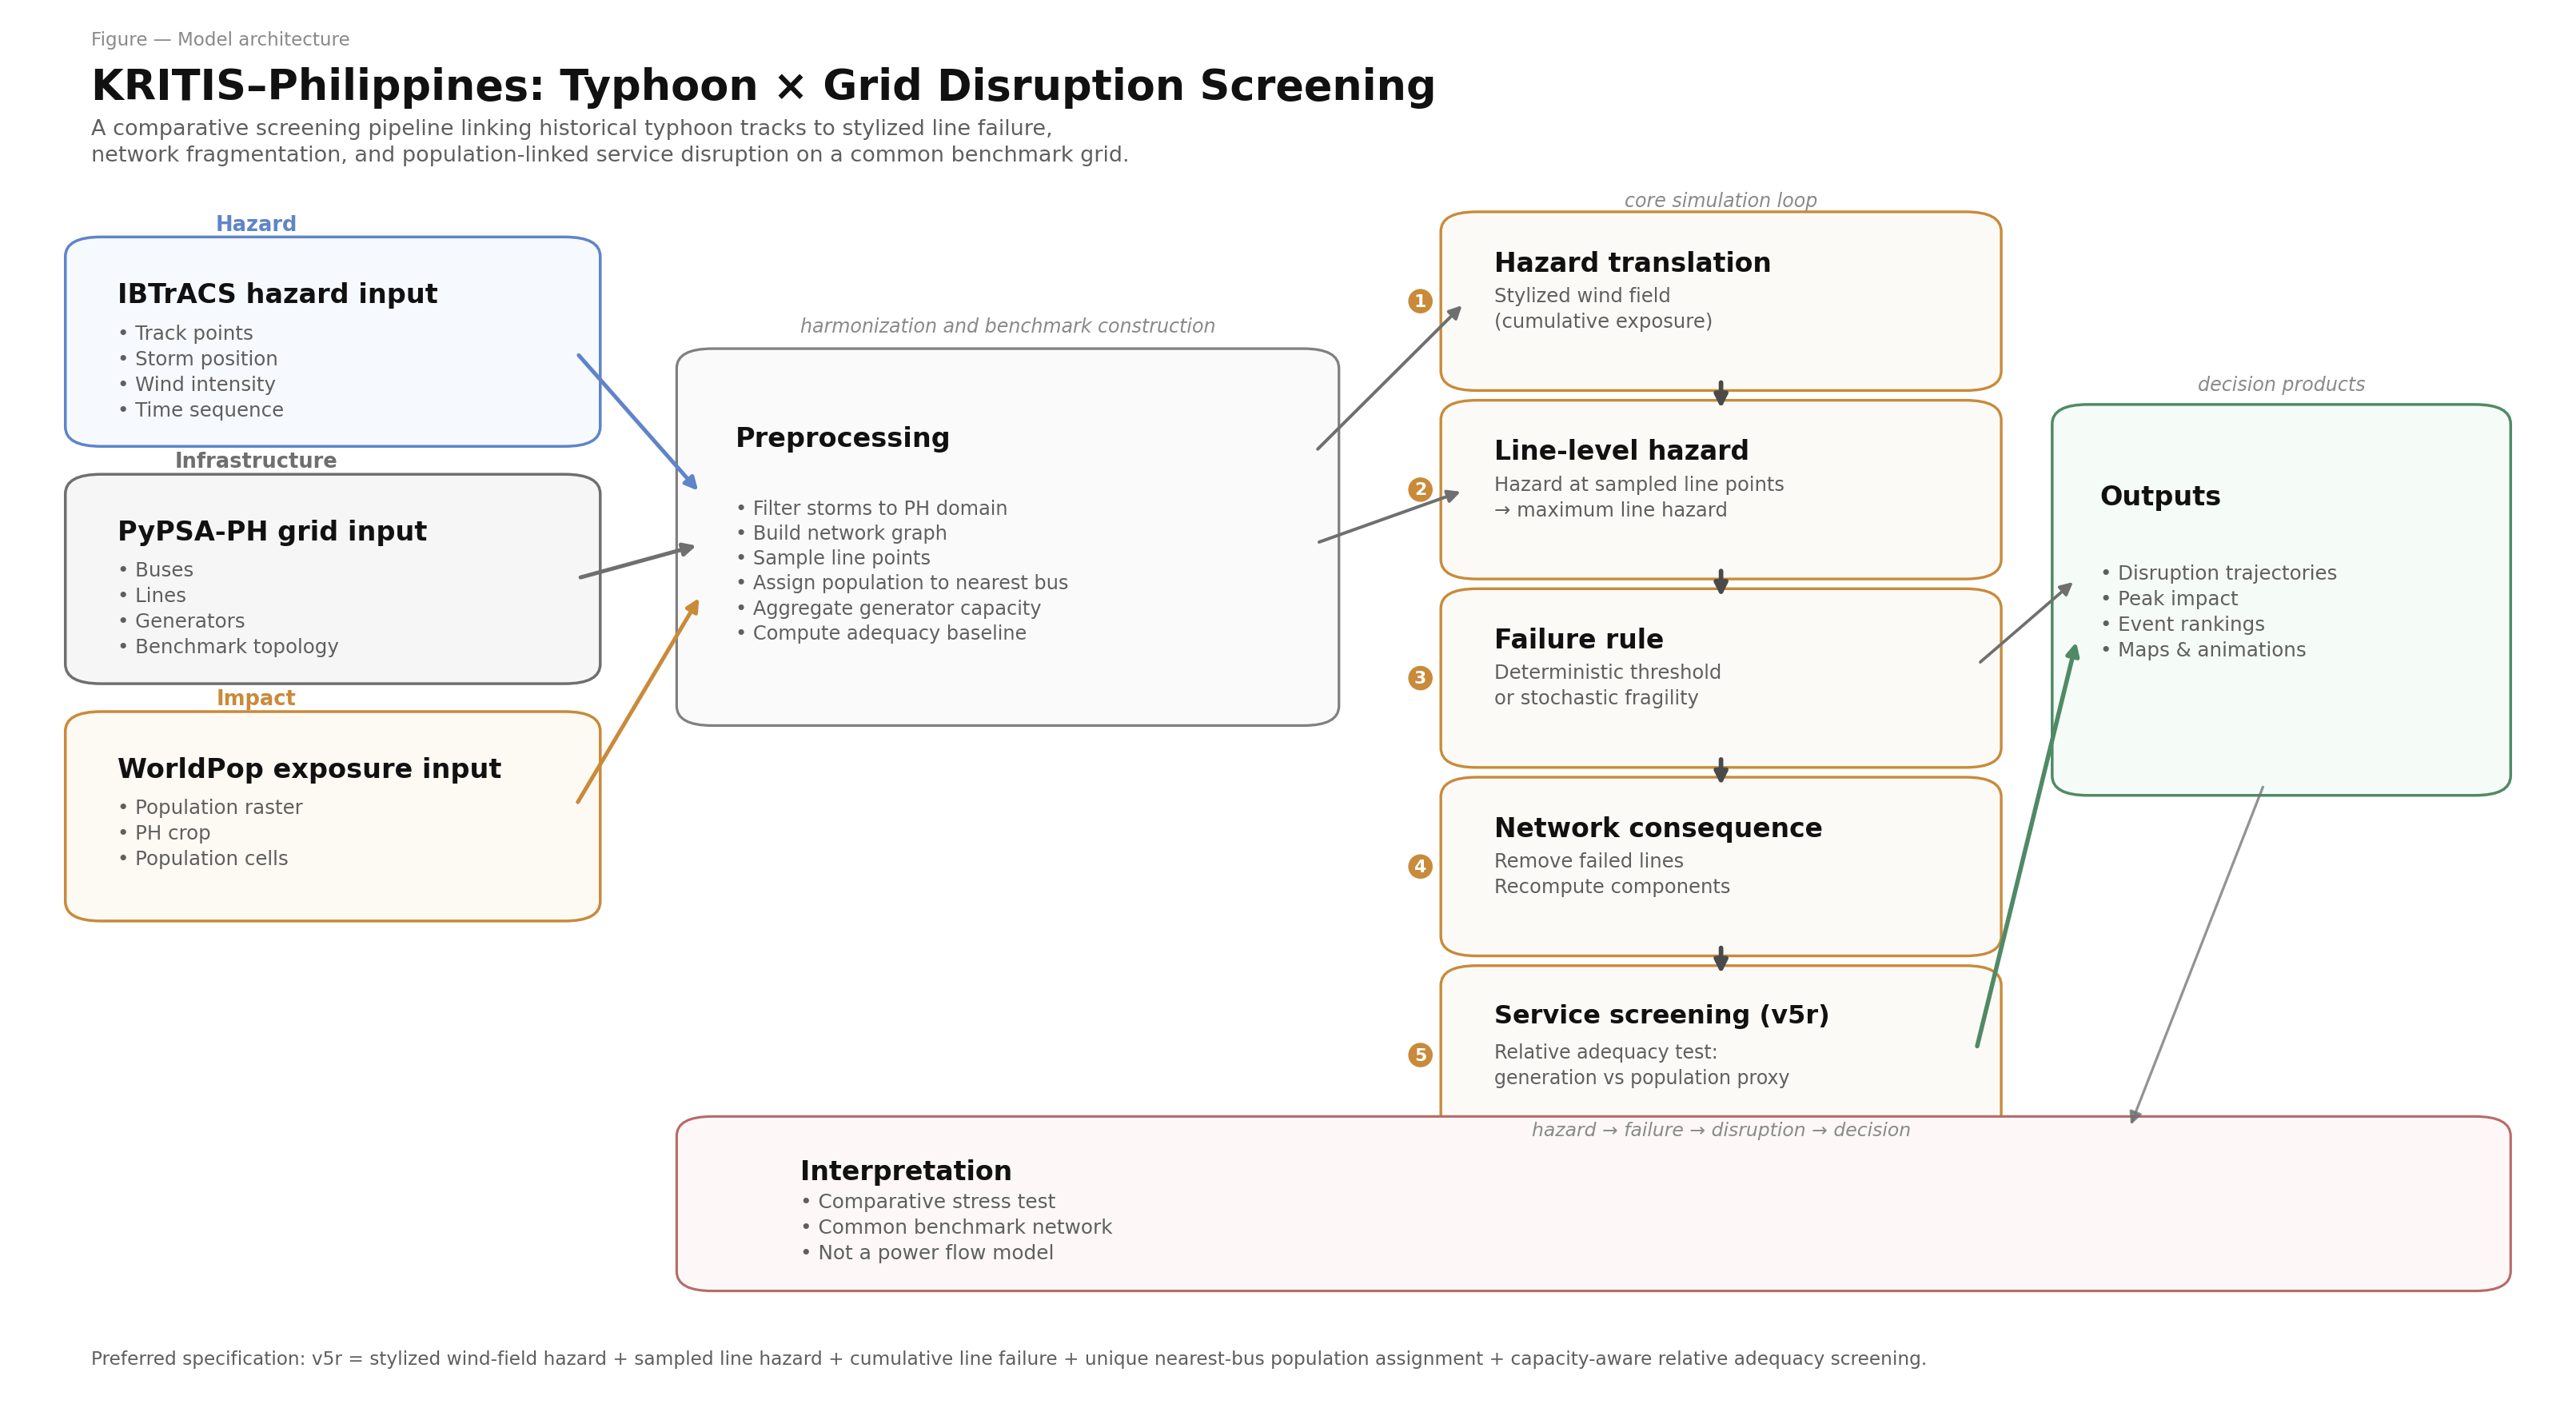

In [176]:
# =========================
# Clean presentation-grade model architecture diagram
# No internal divider lines, more label spacing, better conceptual caption placement
# =========================

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# -------------------------
# Figure setup
# -------------------------
fig, ax = plt.subplots(figsize=(18, 10), dpi=180)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# -------------------------
# Palette
# -------------------------
COLORS = {
    "text": "#111111",
    "muted": "#5F5F5F",
    "light_muted": "#8A8A8A",
    "line_dark": "#4A4A4A",
    "line_mid": "#6F6F6F",

    "hazard": "#5F84C9",
    "hazard_fill": "#F6F9FE",

    "infra": "#6F6F6F",
    "infra_fill": "#F6F6F6",

    "impact": "#C98A3A",
    "impact_fill": "#FDF9F3",

    "pre": "#808080",
    "pre_fill": "#FAFAFA",

    "model": "#C98A3A",
    "model_fill": "#FCFAF6",

    "output": "#4F8A66",
    "output_fill": "#F5FBF7",

    "limit": "#B86A6A",
    "limit_fill": "#FDF7F7",
}

# -------------------------
# Helpers
# -------------------------
def add_box(
    x, y, w, h,
    title, body="",
    fc="white", ec="#444444", lw=1.35,
    title_size=13.6, body_size=9.8,
    rounding=0.014, z=2,
    title_pad=0.14, body_pad=0.37,
    text_x_pad=0.055,
    line_spacing=1.42,
):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle=f"round,pad=0.010,rounding_size={rounding}",
        linewidth=lw,
        edgecolor=ec,
        facecolor=fc,
        zorder=z,
    )
    ax.add_patch(patch)

    ax.text(
        x + text_x_pad * w,
        y + h - title_pad * h,
        title,
        ha="left", va="top",
        fontsize=title_size,
        fontweight="bold",
        color=COLORS["text"],
        zorder=z + 2,
        clip_on=True,
    )

    if body:
        ax.text(
            x + text_x_pad * w,
            y + h - body_pad * h,
            body,
            ha="left", va="top",
            fontsize=body_size,
            color=COLORS["muted"],
            linespacing=line_spacing,
            zorder=z + 2,
            clip_on=True,
        )

def add_arrow(
    p1, p2,
    color="#666666",
    lw=1.8,
    style="-|>",
    ms=13,
    z=3,
    shrinkA=3,
    shrinkB=3,
    alpha=1.0,
):
    arr = FancyArrowPatch(
        p1, p2,
        arrowstyle=style,
        mutation_scale=ms,
        linewidth=lw,
        color=color,
        alpha=alpha,
        shrinkA=shrinkA,
        shrinkB=shrinkB,
        zorder=z,
        connectionstyle="arc3,rad=0.0",
    )
    ax.add_patch(arr)

def top_mid(x, y, w, h):
    return (x + w / 2, y + h)

def bottom_mid(x, y, w, h):
    return (x + w / 2, y)

def add_step_badge(x, y, number, color):
    ax.text(
        x, y,
        str(number),
        fontsize=8.8,
        fontweight="bold",
        color="white",
        ha="center", va="center",
        bbox=dict(boxstyle="circle,pad=0.24", facecolor=color, edgecolor="none"),
        zorder=6,
    )

# -------------------------
# Title block
# -------------------------
ax.text(
    0.03, 0.988,
    "Figure — Model architecture",
    fontsize=9.2,
    color=COLORS["light_muted"],
    ha="left", va="top",
)

ax.text(
    0.03, 0.962,
    "KRITIS–Philippines: Typhoon × Grid Disruption Screening",
    fontsize=21,
    fontweight="bold",
    ha="left", va="top",
    color=COLORS["text"],
)

ax.text(
    0.03, 0.925,
    "A comparative screening pipeline linking historical typhoon tracks to stylized line failure,\n"
    "network fragmentation, and population-linked service disruption on a common benchmark grid.",
    fontsize=10.8,
    ha="left", va="top",
    color=COLORS["muted"],
    linespacing=1.34,
)

# -------------------------
# Layout
# -------------------------
A1 = (0.03, 0.70, 0.19, 0.13)
A2 = (0.03, 0.53, 0.19, 0.13)
A3 = (0.03, 0.36, 0.19, 0.13)

B  = (0.27, 0.50, 0.24, 0.25)

C1 = (0.57, 0.74, 0.20, 0.108)
C2 = (0.57, 0.605, 0.20, 0.108)
C3 = (0.57, 0.470, 0.20, 0.108)
C4 = (0.57, 0.335, 0.20, 0.108)
C5 = (0.57, 0.200, 0.20, 0.108)

D  = (0.81, 0.45, 0.16, 0.26)
E  = (0.27, 0.095, 0.70, 0.105)

# -------------------------
# Floating section labels
# -------------------------
# Left stack labels: more vertical clearance above boxes
ax.text(0.095, A1[1] + A1[3] + 0.015, "Hazard",
        fontsize=10.3, fontweight="bold", color=COLORS["hazard"], ha="center")

ax.text(0.095, A2[1] + A2[3] + 0.015, "Infrastructure",
        fontsize=10.3, fontweight="bold", color=COLORS["infra"], ha="center")

ax.text(0.095, A3[1] + A3[3] + 0.015, "Impact",
        fontsize=10.3, fontweight="bold", color=COLORS["impact"], ha="center")

# Middle labels: lifted further away from boxes
ax.text(B[0] + B[2] / 2, B[1] + B[3] + 0.022, "harmonization and benchmark construction",
        fontsize=9.5, color=COLORS["light_muted"], style="italic", ha="center")

ax.text(C1[0] + C1[2] / 2, C1[1] + C1[3] + 0.014, "core simulation loop",
        fontsize=9.5, color=COLORS["light_muted"], style="italic", ha="center")

ax.text(D[0] + D[2] / 2, D[1] + D[3] + 0.020, "decision products",
        fontsize=9.5, color=COLORS["light_muted"], style="italic", ha="center")

# -------------------------
# Input boxes
# -------------------------
add_box(
    *A1,
    title="IBTrACS hazard input",
    body="• Track points\n• Storm position\n• Wind intensity\n• Time sequence",
    fc=COLORS["hazard_fill"], ec=COLORS["hazard"], lw=1.4,
    title_size=13.4, body_size=9.8, title_pad=0.17, body_pad=0.40
)

add_box(
    *A2,
    title="PyPSA-PH grid input",
    body="• Buses\n• Lines\n• Generators\n• Benchmark topology",
    fc=COLORS["infra_fill"], ec=COLORS["infra"], lw=1.4,
    title_size=13.4, body_size=9.8, title_pad=0.17, body_pad=0.40
)

add_box(
    *A3,
    title="WorldPop exposure input",
    body="• Population raster\n• PH crop\n• Population cells",
    fc=COLORS["impact_fill"], ec=COLORS["impact"], lw=1.4,
    title_size=13.4, body_size=9.8, title_pad=0.17, body_pad=0.40
)

# -------------------------
# Preprocessing
# -------------------------
add_box(
    *B,
    title="Preprocessing",
    body=(
        "• Filter storms to PH domain\n"
        "• Build network graph\n"
        "• Sample line points\n"
        "• Assign population to nearest bus\n"
        "• Aggregate generator capacity\n"
        "• Compute adequacy baseline"
    ),
    fc=COLORS["pre_fill"], ec=COLORS["pre"], lw=1.3,
    title_size=13.4, body_size=9.6, title_pad=0.18, body_pad=0.39, line_spacing=1.38
)

# -------------------------
# Core model boxes
# -------------------------
add_box(
    *C1,
    title="Hazard translation",
    body="Stylized wind field\n(cumulative exposure)",
    fc=COLORS["model_fill"], ec=COLORS["model"], lw=1.35,
    title_size=13.2, body_size=9.7, title_pad=0.16, body_pad=0.40
)

add_box(
    *C2,
    title="Line-level hazard",
    body="Hazard at sampled line points\n→ maximum line hazard",
    fc=COLORS["model_fill"], ec=COLORS["model"], lw=1.35,
    title_size=13.2, body_size=9.7, title_pad=0.16, body_pad=0.40
)

add_box(
    *C3,
    title="Failure rule",
    body="Deterministic threshold\nor stochastic fragility",
    fc=COLORS["model_fill"], ec=COLORS["model"], lw=1.35,
    title_size=13.2, body_size=9.7, title_pad=0.16, body_pad=0.40
)

add_box(
    *C4,
    title="Network consequence",
    body="Remove failed lines\nRecompute components",
    fc=COLORS["model_fill"], ec=COLORS["model"], lw=1.35,
    title_size=13.2, body_size=9.7, title_pad=0.16, body_pad=0.40
)

add_box(
    *C5,
    title="Service screening (v5r)",
    body="Relative adequacy test:\ngeneration vs population proxy",
    fc=COLORS["model_fill"], ec=COLORS["model"], lw=1.35,
    title_size=12.8, body_size=9.5, title_pad=0.16, body_pad=0.42
)

# Step badges
for i, box in enumerate([C1, C2, C3, C4, C5], start=1):
    x, y, w, h = box
    add_step_badge(x - 0.018, y + h / 2, i, COLORS["model"])

# -------------------------
# Outputs
# -------------------------
add_box(
    *D,
    title="Outputs",
    body="• Disruption trajectories\n• Peak impact\n• Event rankings\n• Maps & animations",
    fc=COLORS["output_fill"], ec=COLORS["output"], lw=1.4,
    title_size=13.4, body_size=9.8, title_pad=0.18, body_pad=0.40
)

# -------------------------
# Interpretation
# -------------------------
add_box(
    *E,
    title="Interpretation",
    body="• Comparative stress test\n• Common benchmark network\n• Not a power flow model",
    fc=COLORS["limit_fill"], ec=COLORS["limit"], lw=1.25,
    title_size=13.3, body_size=9.9, title_pad=0.19, body_pad=0.42
)

# Conceptual bridge caption:
# place it clearly between the core stack and the interpretation box
gap_center_y = E[1] + E[3] + (C5[1] - (E[1] + E[3])) * 0.45
ax.text(
    C5[0] + C5[2] / 2,
    gap_center_y,
    "hazard → failure → disruption → decision",
    fontsize=9.4,
    color=COLORS["light_muted"],
    style="italic",
    ha="center",
    va="center",
)

# -------------------------
# Arrow routing — straight only
# -------------------------
# Inputs -> preprocessing
add_arrow(
    (A1[0] + A1[2], A1[1] + A1[3] * 0.45),
    (B[0], B[1] + B[3] * 0.62),
    color=COLORS["hazard"], lw=2.0
)
add_arrow(
    (A2[0] + A2[2], A2[1] + A2[3] * 0.50),
    (B[0], B[1] + B[3] * 0.48),
    color=COLORS["line_mid"], lw=2.0
)
add_arrow(
    (A3[0] + A3[2], A3[1] + A3[3] * 0.55),
    (B[0], B[1] + B[3] * 0.34),
    color=COLORS["impact"], lw=2.0
)

# Preprocessing -> core
add_arrow(
    (B[0] + B[2], B[1] + B[3] * 0.74),
    (C1[0], C1[1] + C1[3] * 0.50),
    color=COLORS["line_mid"], lw=1.6
)
add_arrow(
    (B[0] + B[2], B[1] + B[3] * 0.48),
    (C2[0], C2[1] + C2[3] * 0.50),
    color=COLORS["line_mid"], lw=1.6
)

# Core spine
add_arrow(bottom_mid(*C1), top_mid(*C2), color=COLORS["line_dark"], lw=2.3)
add_arrow(bottom_mid(*C2), top_mid(*C3), color=COLORS["line_dark"], lw=2.3)
add_arrow(bottom_mid(*C3), top_mid(*C4), color=COLORS["line_dark"], lw=2.3)
add_arrow(bottom_mid(*C4), top_mid(*C5), color=COLORS["line_dark"], lw=2.3)

# Core -> outputs
add_arrow(
    (C3[0] + C3[2], C3[1] + C3[3] * 0.58),
    (D[0], D[1] + D[3] * 0.56),
    color=COLORS["line_mid"], lw=1.5
)
add_arrow(
    (C5[0] + C5[2], C5[1] + C5[3] * 0.52),
    (D[0], D[1] + D[3] * 0.40),
    color=COLORS["output"], lw=2.2
)

# Outputs -> interpretation
add_arrow(
    (D[0] + D[2] * 0.46, D[1]),
    (E[0] + E[2] * 0.80, E[1] + E[3]),
    color=COLORS["line_mid"], lw=1.3, alpha=0.75
)

# -------------------------
# Footer
# -------------------------
ax.text(
    0.03, 0.03,
    "Preferred specification: v5r = stylized wind-field hazard + sampled line hazard + cumulative line failure + "
    "unique nearest-bus population assignment + capacity-aware relative adequacy screening.",
    fontsize=9.3,
    color=COLORS["muted"],
    ha="left",
    va="bottom",
)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# Cell 1 — Imports & configuration
# =========================
# This cell imports all required packages and defines
# the main model parameters used throughout the notebook.

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle
from IPython.display import display, HTML

import networkx as nx
from tropycal import tracks
from scipy.spatial import cKDTree
from scipy.ndimage import gaussian_filter

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -------------------------
# Repository / file paths
# -------------------------
REPO_ROOT = Path.cwd().resolve()

BUSES_CSV = REPO_ROOT / "PyPSA-PH/data/buses.csv"
LINES_CSV = REPO_ROOT / "PyPSA-PH/data/lines.csv"
GENERATORS_CSV = REPO_ROOT / "PyPSA-PH/data/generators.csv"
WORLDPOP_CSV = REPO_ROOT / "data/worldpop_ph_2020_1km/phl_pd_2020_1km_ASCII_XYZ.csv"

OUTPUT_DIR = REPO_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# -------------------------
# Model scope
# -------------------------
START_YEAR = None

PH_BOUNDS = {
    "lat_min": 4.0,
    "lat_max": 22.0,
    "lon_min": 116.0,
    "lon_max": 128.0,
}

# -------------------------
# Hazard / failure settings
# -------------------------
SEARCH_RADIUS_KM = 200.0
FAIL_THRESHOLD = 0.55
LINE_SAMPLE_POINTS = 7

# Optional historical filtering for generator commissioning year
USE_GENERATOR_COMMISSION_YEAR = False
GENERATOR_YEAR_COLUMN = "commissioning_year"

# Stylized wind-field parameters
RMAX_KM_DEFAULT = 35.0
RMAX_SCALING = False
INNER_CORE_FLOOR = 0.85
OUTER_DECAY_POWER = 1.35
MIN_EFFECTIVE_WIND_KPH = 30.0

# Capacity-aware adequacy settings
GEN_CAPACITY_COL = "p_nom"
MIN_TOTAL_GEN_MW = 1.0
MIN_RELATIVE_RATIO_MULTI = 0.35
MIN_RELATIVE_RATIO_SINGLE = 0.75

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Python:", sys.version.split()[0])
print("REPO_ROOT:", REPO_ROOT)

Python: 3.12.3
REPO_ROOT: /home/krawalker/coding/KRITIS-PH


In [ ]:
# =========================
# Cell 2 — Shared mapping & plotting helpers
# =========================
# These helpers standardize the visual language across
# infrastructure maps, storm maps, and population maps.

import cartopy.crs as ccrs
import cartopy.feature as cfeature

PROJ = ccrs.PlateCarree()

MAP_COLORS = {
    "ocean": "white",
    "land": "#f7f7f7",
    "coast": "#6f6f6f",
    "border": "#9a9a9a",
    "grid": "#d9d9d9",
    "line": "#4a4a4a",
    "bus_fill": "white",
    "bus_edge": "#2b2b2b",
    "text": "#111111",
    "frame": "#cccccc",
}

def setup_ph_map(
    ax,
    bounds=PH_BOUNDS,
    title=None,
    coastline_lw=0.8,
    border_lw=0.45,
    grid_alpha=0.16,
    land_color=None,
    ocean_color=None,
):
    """
    Standard Philippines map setup for geographic plots.
    """
    land_color = MAP_COLORS["land"] if land_color is None else land_color
    ocean_color = MAP_COLORS["ocean"] if ocean_color is None else ocean_color

    ax.set_extent(
        [bounds["lon_min"], bounds["lon_max"], bounds["lat_min"], bounds["lat_max"]],
        crs=PROJ,
    )

    ax.add_feature(cfeature.OCEAN, facecolor=ocean_color, zorder=0)
    ax.add_feature(cfeature.LAND, facecolor=land_color, zorder=0)
    ax.add_feature(
        cfeature.COASTLINE,
        linewidth=coastline_lw,
        edgecolor=MAP_COLORS["coast"],
        zorder=1,
    )
    ax.add_feature(
        cfeature.BORDERS,
        linewidth=border_lw,
        edgecolor=MAP_COLORS["border"],
        alpha=0.5,
        zorder=1,
    )

    gl = ax.gridlines(draw_labels=False, alpha=grid_alpha, linewidth=0.6)
    gl.x_inline = False
    gl.y_inline = False

    if title is not None:
        ax.set_title(title)

def plot_lines(
    ax,
    line_df,
    color=None,
    alpha=0.22,
    linewidth=0.55,
    zorder=3,
):
    """
    Plot transmission lines from line_df.
    Expects lon0, lat0, lon1, lat1 columns.
    """
    color = MAP_COLORS["line"] if color is None else color

    for _, row in line_df.iterrows():
        ax.plot(
            [row["lon0"], row["lon1"]],
            [row["lat0"], row["lat1"]],
            color=color,
            alpha=alpha,
            linewidth=linewidth,
            transform=PROJ,
            zorder=zorder,
        )

def plot_buses(
    ax,
    buses,
    size=12,
    color=None,
    edgecolor=None,
    linewidth=0.45,
    alpha=0.9,
    marker="o",
    label=None,
    zorder=4,
):
    """
    Plot buses from a bus DataFrame.
    Expects lon and lat columns.
    """
    color = MAP_COLORS["bus_fill"] if color is None else color
    edgecolor = MAP_COLORS["bus_edge"] if edgecolor is None else edgecolor

    ax.scatter(
        buses["lon"],
        buses["lat"],
        s=size,
        c=color,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=alpha,
        marker=marker,
        label=label,
        transform=PROJ,
        zorder=zorder,
    )

In [ ]:
# =========================
# Cell 3 — Generic utility helpers
# =========================
# These are low-level helpers used for distance calculations,
# normalization, coordinate conversion, and reading population data.

def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance in kilometers between two points on Earth.
    Supports NumPy arrays.
    """
    earth_radius_km = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2.0 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

def storm_name_map_from_ib(ib_ds):
    """
    Build a dictionary storm_id -> uppercase storm name from the tropycal dataset.
    """
    out = {}
    for sid, storm in ib_ds.data.items():
        name = storm.get("name")
        if name is None or str(name).strip() == "":
            name = "UNNAMED"
        out[str(sid)] = str(name).upper()
    return out

def minmax_normalize(series):
    """
    Normalize a pandas Series to [0, 1].
    If the series is constant, return all zeros.
    """
    s = pd.to_numeric(series, errors="coerce").astype(float)
    s_min = s.min()
    s_max = s.max()

    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)

    return (s - s_min) / (s_max - s_min)

def latlon_to_km_xy(lat, lon, lat_ref=None):
    """
    Rough lat/lon -> planar km conversion for local nearest-neighbor logic.
    Good enough for screening-level population assignment.
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)

    if lat_ref is None:
        lat_ref = np.nanmean(lat)

    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.radians(lat_ref))

    x = lon * km_per_deg_lon
    y = lat * km_per_deg_lat
    return x, y

def load_worldpop_xyz(path):
    """
    Read a WorldPop-style XYZ table robustly.
    Tries normal CSV first, then falls back to whitespace-separated parsing.
    """
    try:
        df = pd.read_csv(path)
        if df.shape[1] < 3:
            raise ValueError
    except Exception:
        df = pd.read_csv(
            path,
            sep=r"\s+",
            header=None,
            names=["lon", "lat", "pop_value"],
            engine="python",
            comment="#",
        )

    if list(df.columns)[:3] != ["lon", "lat", "pop_value"]:
        df = df.iloc[:, :3].copy()
        df.columns = ["lon", "lat", "pop_value"]

    for c in ["lon", "lat", "pop_value"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["lon", "lat", "pop_value"]).copy()

    # If longitudes appear in -180..180 format, convert to 0..360
    if (df["lon"] < 0).any():
        df.loc[df["lon"] < 0, "lon"] += 360

    return df

In [ ]:
# =========================
# Cell 4 — Population assignment and network sampling helpers
# =========================
# The key move here is to assign each population raster cell to exactly
# one nearest bus. That avoids the double-counting problem from radius sums.

def assign_population_to_nearest_bus(pop_ph, buses):
    """
    Assign each population cell to the nearest bus in approximate km space.

    Returns
    -------
    buses_out : DataFrame
        Original bus table with a new column 'bus_pop_local_nb'.
    pop_assignment : DataFrame
        Population table with nearest-bus metadata.
    """
    if pop_ph.empty:
        raise ValueError("pop_ph is empty.")
    if buses.empty:
        raise ValueError("buses is empty.")

    buses_out = buses.copy()

    lat_ref = np.nanmean(
        np.concatenate([
            pop_ph["lat"].to_numpy(dtype=float),
            buses["lat"].to_numpy(dtype=float),
        ])
    )

    bus_x, bus_y = latlon_to_km_xy(
        buses_out["lat"].to_numpy(),
        buses_out["lon"].to_numpy(),
        lat_ref=lat_ref,
    )
    pop_x, pop_y = latlon_to_km_xy(
        pop_ph["lat"].to_numpy(),
        pop_ph["lon"].to_numpy(),
        lat_ref=lat_ref,
    )

    tree = cKDTree(np.column_stack([bus_x, bus_y]))
    dist_km, idx = tree.query(np.column_stack([pop_x, pop_y]), k=1)

    pop_assignment = pop_ph.copy()
    pop_assignment["nearest_bus_idx"] = idx.astype(int)
    pop_assignment["nearest_bus_dist_km"] = dist_km.astype(float)
    pop_assignment["nearest_bus_id"] = buses_out.iloc[idx]["bus_id"].to_numpy()

    bus_pop_nb = (
        pop_assignment.groupby("nearest_bus_id", as_index=False)["pop_value"]
        .sum()
        .rename(columns={"nearest_bus_id": "bus_id", "pop_value": "bus_pop_local_nb"})
    )

    buses_out = buses_out.merge(bus_pop_nb, on="bus_id", how="left")
    buses_out["bus_pop_local_nb"] = buses_out["bus_pop_local_nb"].fillna(0.0)

    return buses_out, pop_assignment

def build_line_samples(line_df, n_samples=7):
    """
    Sample points along each line so hazard can be evaluated over the full line
    rather than just at line endpoints or midpoints.
    """
    sample_rows = []

    for _, row in line_df.iterrows():
        lats = np.linspace(row["lat0"], row["lat1"], n_samples)
        lons = np.linspace(row["lon0"], row["lon1"], n_samples)

        for sample_idx, (lat, lon) in enumerate(zip(lats, lons)):
            sample_rows.append(
                {
                    "line_id": str(row["line_id"]),
                    "bus0": row["bus0"],
                    "bus1": row["bus1"],
                    "sample_idx": int(sample_idx),
                    "lat": float(lat),
                    "lon": float(lon),
                }
            )

    return pd.DataFrame(sample_rows)

In [ ]:
# =========================
# Cell 5 — Generator and adequacy helpers
# =========================
# These functions define the "service logic" of v5r.
# The model does not run load flow.
# Instead it asks:
# "After fragmentation, does a component still have enough generation
# relative to its attached population proxy?"

def get_generator_buses_for_storm_year(
    generators,
    graph_nodes,
    storm_year,
    use_commission_year=False,
    year_col="commissioning_year",
):
    """
    Return generator buses present in the graph.
    Optionally filter generators by commissioning year.
    """
    g = generators.copy()

    if use_commission_year and year_col in g.columns:
        g[year_col] = pd.to_numeric(g[year_col], errors="coerce")
        g = g[g[year_col].isna() | (g[year_col] <= storm_year)].copy()

    gen_buses = set(g["bus"].dropna().astype(str)) & set(graph_nodes)
    return gen_buses

def build_generator_bus_capacity(generators, capacity_col="p_nom"):
    """
    Aggregate installed generation capacity per bus.
    """
    g = generators.copy()

    if "bus" not in g.columns:
        raise ValueError("generators must contain column 'bus'")
    if capacity_col not in g.columns:
        raise ValueError(f"generators must contain column '{capacity_col}'")

    g["bus"] = g["bus"].astype(str)
    g[capacity_col] = pd.to_numeric(g[capacity_col], errors="coerce").fillna(0.0)

    gen_bus_cap = (
        g.groupby("bus", as_index=False)[capacity_col]
        .sum()
        .rename(columns={"bus": "bus_id", capacity_col: "gen_capacity_mw"})
    )

    return gen_bus_cap

def build_component_adequacy_table(G_t, buses, gen_bus_cap, bus_pop_col="bus_pop_local_nb"):
    """
    Build a table of connected components and their adequacy-relevant properties.
    """
    bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
    bus_state = bus_state.merge(gen_bus_cap, on="bus_id", how="left")
    bus_state["gen_capacity_mw"] = bus_state["gen_capacity_mw"].fillna(0.0)
    bus_state[bus_pop_col] = bus_state[bus_pop_col].fillna(0.0)

    rows = []
    for comp_id, comp in enumerate(nx.connected_components(G_t), start=1):
        comp_set = set(comp)

        comp_buses = pd.DataFrame({"bus_id": list(comp_set)}).merge(
            bus_state, on="bus_id", how="left"
        )

        pop_proxy = float(comp_buses[bus_pop_col].sum())
        gen_cap = float(comp_buses["gen_capacity_mw"].sum())
        n_gen_buses = int((comp_buses["gen_capacity_mw"] > 0).sum())

        rows.append(
            {
                "component_id": comp_id,
                "bus_ids": list(comp_set),
                "n_buses": int(len(comp_set)),
                "n_generator_buses": n_gen_buses,
                "population_proxy": pop_proxy,
                "gen_capacity_mw": gen_cap,
                "mw_per_person_proxy": gen_cap / pop_proxy if pop_proxy > 0 else np.nan,
            }
        )

    return pd.DataFrame(rows)

def compute_system_baseline_mw_per_person_proxy(
    G_base,
    buses,
    gen_bus_cap,
    bus_pop_col="bus_pop_local_nb",
):
    """
    Compute the intact-system benchmark adequacy ratio against which fragmented
    components will be compared in v5r.
    """
    comp_df = build_component_adequacy_table(
        G_t=G_base,
        buses=buses,
        gen_bus_cap=gen_bus_cap,
        bus_pop_col=bus_pop_col,
    )

    if len(comp_df) != 1:
        print("Warning: base graph has more than one component. Using largest by population proxy.")

    base_row = comp_df.sort_values("population_proxy", ascending=False).iloc[0]

    return {
        "population_proxy": float(base_row["population_proxy"]),
        "gen_capacity_mw": float(base_row["gen_capacity_mw"]),
        "mw_per_person_proxy": float(base_row["mw_per_person_proxy"]),
    }

def classify_served_components_relative_v3(
    comp_df,
    baseline_mw_per_person_proxy,
    min_relative_ratio_multi=0.35,
    min_relative_ratio_single=0.75,
    min_total_gen_mw=1.0,
):
    """
    Mark a component as 'served' if:
    - it has at least a minimum amount of generation, and
    - its capacity/population ratio remains above a threshold relative
      to the intact-system benchmark.
    """
    out = comp_df.copy()

    out["relative_adequacy"] = (
        out["mw_per_person_proxy"] / baseline_mw_per_person_proxy
        if baseline_mw_per_person_proxy > 0 else np.nan
    )

    out["required_relative_ratio"] = np.where(
        out["n_buses"] == 1,
        min_relative_ratio_single,
        min_relative_ratio_multi,
    )

    out["served_component"] = (
        (out["gen_capacity_mw"] >= min_total_gen_mw)
        & (out["relative_adequacy"] >= out["required_relative_ratio"])
    )

    return out

In [ ]:
# =========================
# Cell 6 — Hazard and fragility helpers
# =========================
# This is the core hazard logic:
# - each track point has a wind intensity
# - intensity decays radially with distance
# - line hazard is the max hazard over all sampled points and all storm points
#   up to timestep t

def radial_wind_factor(distance_km, rmax_km=35.0, inner_core_floor=0.85, outer_decay_power=1.35):
    """
    Stylized radial decay function.

    Inner core:
        decays mildly from 1.0 to inner_core_floor up to rmax.
    Outside:
        decays as a power law.
    """
    d = np.asarray(distance_km, dtype=float)
    d = np.maximum(d, 0.0)
    rmax_km = max(float(rmax_km), 1.0)

    out = np.zeros_like(d, dtype=float)

    inner = d <= rmax_km
    outer = ~inner

    if np.any(inner):
        x = d[inner] / rmax_km
        out[inner] = inner_core_floor + (1.0 - inner_core_floor) * x

    if np.any(outer):
        x = d[outer] / rmax_km
        out[outer] = x ** (-outer_decay_power)

    return np.clip(out, 0.0, 1.0)

def estimate_rmax_km_from_point(storm_point, default_rmax_km=35.0, scaling=False):
    """
    Optional dynamic scaling of storm radius as a function of wind speed.
    """
    if not scaling:
        return float(default_rmax_km)

    wind_kph = float(storm_point.get("wind_kph", np.nan))
    if not np.isfinite(wind_kph):
        return float(default_rmax_km)

    rmax = default_rmax_km + 0.08 * max(wind_kph - 120.0, 0.0)
    return float(np.clip(rmax, 20.0, 80.0))

def compute_line_hazard_up_to_t_sampled(
    storm_points_up_to_t,
    line_samples,
    line_df,
    search_radius_km,
    global_max_wind_kph,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
):
    """
    Compute cumulative hazard on each line up to timestep t.

    Process
    -------
    1. For each storm point up to t:
       - compute distance to every line sample point
       - evaluate normalized wind × radial decay
    2. For each sample point:
       - keep maximum hazard over time
    3. For each line:
       - keep maximum over all its sampled points
    """
    sample_hmax = np.zeros(len(line_samples), dtype=float)
    sample_lat = line_samples["lat"].to_numpy()
    sample_lon = line_samples["lon"].to_numpy()

    for _, sp in storm_points_up_to_t.iterrows():
        wind_kph = float(sp["wind_kph"])

        if not np.isfinite(wind_kph) or wind_kph < min_effective_wind_kph:
            continue

        d = haversine_km(sample_lat, sample_lon, sp["lat"], sp["lon"])
        near = d <= search_radius_km

        if not np.any(near):
            continue

        rmax_km = estimate_rmax_km_from_point(
            storm_point=sp,
            default_rmax_km=rmax_km_default,
            scaling=rmax_scaling,
        )

        wind_norm = wind_kph / global_max_wind_kph

        radial_factor = radial_wind_factor(
            distance_km=d[near],
            rmax_km=rmax_km,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
        )

        hz = wind_norm * radial_factor
        sample_hmax[near] = np.maximum(sample_hmax[near], hz)

    sample_result = line_samples.copy()
    sample_result["hazard_sample_max"] = sample_hmax

    line_hazard = (
        sample_result.groupby("line_id", as_index=False)["hazard_sample_max"]
        .max()
        .rename(columns={"hazard_sample_max": "hazard_max"})
    )

    lf = line_df.merge(line_hazard, on="line_id", how="left")
    lf["hazard_max"] = lf["hazard_max"].fillna(0.0)

    return lf, sample_result

def logistic_fragility(hazard, h0=0.55, k=18.0):
    """
    Convert normalized hazard into line failure probability.

    h0 = midpoint where p_fail = 0.5
    k  = steepness
    """
    h = np.asarray(hazard, dtype=float)
    p = 1.0 / (1.0 + np.exp(-k * (h - h0)))
    return np.clip(p, 0.0, 1.0)

In [ ]:
# =========================
# Cell 7 — Deterministic simulators
# =========================
# Two versions are retained:
# - v4b: binary "connected to any generator" service logic
# - v5r: preferred model with relative adequacy screening

def simulate_grid_impact_timeseries_v4b(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_buses,
    search_radius_km,
    global_max_wind_kph,
    fail_threshold,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
    bus_pop_col="bus_pop_local_nb",
):
    """
    Deterministic benchmark version:
    if a connected component contains at least one generator bus,
    all buses in that component are treated as served.
    """
    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )
    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
            rmax_km_default=rmax_km_default,
            rmax_scaling=rmax_scaling,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
            min_effective_wind_kph=min_effective_wind_kph,
        )

        lf["failed_now"] = lf["hazard_max"] > fail_threshold
        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids
        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        # Copy the benchmark graph and remove failed lines
        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        served_buses = set()
        for comp in nx.connected_components(G_t):
            if len(set(comp) & gen_buses) > 0:
                served_buses |= set(comp)

        bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = bus_state.loc[bus_state["unserved"], bus_pop_col].sum()
        total_population_proxy = bus_state[bus_pop_col].sum()

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": float(affected_population),
            "affected_population_share_proxy": (
                float(affected_population) / float(total_population_proxy)
                if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
        }
        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "record": rec.copy(),
            }
        )

    return pd.DataFrame(records), step_outputs

def simulate_grid_impact_timeseries_v5r(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_bus_cap,
    baseline_mw_per_person_proxy,
    search_radius_km,
    global_max_wind_kph,
    fail_threshold,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=0.35,
    min_relative_ratio_single=0.75,
    min_total_gen_mw=1.0,
):
    """
    Preferred deterministic model:
    service depends on relative adequacy after fragmentation.
    """
    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )
    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
            rmax_km_default=rmax_km_default,
            rmax_scaling=rmax_scaling,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
            min_effective_wind_kph=min_effective_wind_kph,
        )

        lf["failed_now"] = lf["hazard_max"] > fail_threshold
        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids
        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        comp_df = build_component_adequacy_table(
            G_t=G_t,
            buses=buses,
            gen_bus_cap=gen_bus_cap,
            bus_pop_col=bus_pop_col,
        )

        comp_df = classify_served_components_relative_v3(
            comp_df=comp_df,
            baseline_mw_per_person_proxy=baseline_mw_per_person_proxy,
            min_relative_ratio_multi=min_relative_ratio_multi,
            min_relative_ratio_single=min_relative_ratio_single,
            min_total_gen_mw=min_total_gen_mw,
        )

        served_buses = set()
        for _, comp_row in comp_df.loc[comp_df["served_component"]].iterrows():
            served_buses |= set(comp_row["bus_ids"])

        bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
        bus_state = bus_state.merge(gen_bus_cap, on="bus_id", how="left")
        bus_state["gen_capacity_mw"] = bus_state["gen_capacity_mw"].fillna(0.0)
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = float(bus_state.loc[bus_state["unserved"], bus_pop_col].sum())
        total_population_proxy = float(bus_state[bus_pop_col].sum())

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": affected_population,
            "affected_population_share_proxy": (
                affected_population / total_population_proxy if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "n_served_components": int(comp_df["served_component"].sum()),
            "n_unserved_components": int((~comp_df["served_component"]).sum()),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
        }
        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "component_table": comp_df.copy(),
                "record": rec.copy(),
            }
        )

    return pd.DataFrame(records), step_outputs

In [ ]:
# =========================
# Cell 8 — Stochastic v5r simulator
# =========================
# This is an optional extension.
# Instead of applying a hard threshold, each line gets a failure
# probability from a logistic fragility curve.
# A random draw then decides whether an as-yet-intact line fails.

def simulate_grid_impact_timeseries_v5r_stochastic(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_bus_cap,
    baseline_mw_per_person_proxy,
    search_radius_km,
    global_max_wind_kph,
    fragility_h0=0.55,
    fragility_k=18.0,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=0.35,
    min_relative_ratio_single=0.75,
    min_total_gen_mw=1.0,
    rng=None,
):
    """
    Stochastic v5r:
    - compute hazard as usual
    - map hazard to p_fail via logistic fragility
    - randomly fail only lines that are not already failed
    - failed lines remain failed for the rest of the storm
    """
    if rng is None:
        rng = np.random.default_rng()

    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )
    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
            rmax_km_default=rmax_km_default,
            rmax_scaling=rmax_scaling,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
            min_effective_wind_kph=min_effective_wind_kph,
        )

        lf = lf.copy()
        lf["p_fail"] = logistic_fragility(
            lf["hazard_max"].to_numpy(),
            h0=fragility_h0,
            k=fragility_k,
        )

        lf["already_failed"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        not_failed_mask = ~lf["already_failed"]
        lf["random_u"] = rng.random(len(lf))
        lf["failed_now"] = False
        lf.loc[not_failed_mask, "failed_now"] = (
            lf.loc[not_failed_mask, "random_u"] < lf.loc[not_failed_mask, "p_fail"]
        )

        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids
        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        comp_df = build_component_adequacy_table(
            G_t=G_t,
            buses=buses,
            gen_bus_cap=gen_bus_cap,
            bus_pop_col=bus_pop_col,
        )

        comp_df = classify_served_components_relative_v3(
            comp_df=comp_df,
            baseline_mw_per_person_proxy=baseline_mw_per_person_proxy,
            min_relative_ratio_multi=min_relative_ratio_multi,
            min_relative_ratio_single=min_relative_ratio_single,
            min_total_gen_mw=min_total_gen_mw,
        )

        served_buses = set()
        for _, comp_row in comp_df.loc[comp_df["served_component"]].iterrows():
            served_buses |= set(comp_row["bus_ids"])

        bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
        bus_state = bus_state.merge(gen_bus_cap, on="bus_id", how="left")
        bus_state["gen_capacity_mw"] = bus_state["gen_capacity_mw"].fillna(0.0)
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = float(bus_state.loc[bus_state["unserved"], bus_pop_col].sum())
        total_population_proxy = float(bus_state[bus_pop_col].sum())

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_failed_lines_new": int(lf["failed_now"].sum()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": affected_population,
            "affected_population_share_proxy": (
                affected_population / total_population_proxy if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "n_served_components": int(comp_df["served_component"].sum()),
            "n_unserved_components": int((~comp_df["served_component"]).sum()),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
            "mean_line_p_fail_this_step": float(lf["p_fail"].mean()),
            "max_line_p_fail_this_step": float(lf["p_fail"].max()),
        }
        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "component_table": comp_df.copy(),
                "record": rec.copy(),
            }
        )

    return pd.DataFrame(records), step_outputs

In [ ]:
# =========================
# Cell 9 — Summary and animation helpers
# =========================
# These functions are used after simulations have been run.

def summarize_storm_timeseries(ts_df):
    """
    Collapse a full storm time series to a single summary row used for ranking.
    """
    if ts_df.empty:
        raise ValueError("ts_df is empty")

    peak_idx = ts_df["affected_population_proxy"].idxmax()
    peak_row = ts_df.loc[peak_idx].copy()

    return {
        "storm_id": peak_row["storm_id"],
        "storm_name": peak_row["storm_name"],
        "year": int(peak_row["year"]),
        "peak_t": int(peak_row["t"]),
        "peak_affected_population_proxy": float(ts_df["affected_population_proxy"].max()),
        "peak_affected_population_share_proxy": float(ts_df["affected_population_share_proxy"].max()),
        "peak_n_unserved_buses": int(ts_df["n_unserved_buses"].max()),
        "peak_unserved_bus_share": float(ts_df["unserved_bus_share"].max()),
        "peak_n_failed_lines_cumulative": int(ts_df["n_failed_lines_cumulative"].max()),
        "peak_failed_line_share_cumulative": float(ts_df["failed_line_share_cumulative"].max()),
        "final_affected_population_proxy": float(ts_df.iloc[-1]["affected_population_proxy"]),
        "final_n_unserved_buses": int(ts_df.iloc[-1]["n_unserved_buses"]),
        "final_n_failed_lines_cumulative": int(ts_df.iloc[-1]["n_failed_lines_cumulative"]),
        "n_timesteps": int(len(ts_df)),
    }

def animate_storm_bus_impact_canonical(
    step_outputs,
    pop_assignment,
    H_pop_log,
    xedges_pop,
    yedges_pop,
    out_gif_path=None,
    bounds=PH_BOUNDS,
    interval=700,
    show_search_radius=True,
    search_radius_km=SEARCH_RADIUS_KM,
):
    """
    Create an animation of storm progression, failed lines, unserved buses,
    and affected population proxy.
    """
    fig, ax = plt.subplots(
        figsize=(10, 10),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )

    def km_to_lonlat_radius(km, lat):
        lat_radius_deg = km / 111.32
        lon_radius_deg = km / (111.32 * max(np.cos(np.radians(lat)), 0.15))
        return lat_radius_deg, lon_radius_deg

    def update(frame_idx):
        ax.clear()
        step_output = step_outputs[frame_idx]

        lf = step_output["lf"].copy()
        bus_state = step_output["bus_state"][["bus_id", "lat", "lon", "served", "unserved"]].copy()
        storm_track = step_output["storm_points_up_to_t"].copy()
        rec = step_output["record"]

        # Rebuild affected population by linking population cells
        # to the service status of their nearest bus.
        pop_t = pop_assignment.merge(
            bus_state[["bus_id", "served", "unserved"]],
            left_on="nearest_bus_id",
            right_on="bus_id",
            how="left",
        )
        pop_t["served"] = pop_t["served"].fillna(False)
        pop_t["unserved"] = pop_t["unserved"].fillna(False)

        affected_by_bus_t = (
            pop_t.loc[pop_t["unserved"]]
            .groupby("nearest_bus_id", as_index=False)
            .agg(
                affected_population_proxy=("pop_value", "sum"),
                n_affected_cells=("pop_value", "size"),
            )
            .rename(columns={"nearest_bus_id": "bus_id"})
        )

        bus_plot = bus_state.merge(affected_by_bus_t, on="bus_id", how="left")
        bus_plot["affected_population_proxy"] = bus_plot["affected_population_proxy"].fillna(0.0)
        bus_plot["n_affected_cells"] = bus_plot["n_affected_cells"].fillna(0).astype(int)

        setup_ph_map(ax, bounds=bounds, title=f"{rec['storm_name']} ({rec['year']}) [{rec['storm_id']}]")

        # Smoothed population backdrop
        ax.imshow(
            H_pop_log,
            origin="lower",
            extent=[xedges_pop[0], xedges_pop[-1], yedges_pop[0], yedges_pop[-1]],
            aspect="auto",
            transform=ccrs.PlateCarree(),
            alpha=0.55,
            zorder=1,
        )

        intact = lf.loc[~lf["failed_cumulative"]].copy()
        newly_failed = lf.loc[lf["failed_now"]].copy()
        previously_failed = lf.loc[lf["failed_cumulative"] & ~lf["failed_now"]].copy()

        for _, row in intact.iterrows():
            ax.plot(
                [row["lon0"], row["lon1"]],
                [row["lat0"], row["lat1"]],
                color="gray",
                linewidth=0.45,
                alpha=0.10,
                transform=ccrs.PlateCarree(),
                zorder=2,
            )

        for _, row in previously_failed.iterrows():
            ax.plot(
                [row["lon0"], row["lon1"]],
                [row["lat0"], row["lat1"]],
                color="darkred",
                linewidth=1.3,
                alpha=0.75,
                transform=ccrs.PlateCarree(),
                zorder=3,
            )

        for _, row in newly_failed.iterrows():
            ax.plot(
                [row["lon0"], row["lon1"]],
                [row["lat0"], row["lat1"]],
                color="orange",
                linewidth=2.3,
                alpha=0.95,
                transform=ccrs.PlateCarree(),
                zorder=4,
            )

        # Base bus layer
        ax.scatter(
            bus_plot["lon"],
            bus_plot["lat"],
            s=8,
            color="black",
            alpha=0.18,
            transform=ccrs.PlateCarree(),
            zorder=5,
        )

        # Scale bus marker size by affected population proxy
        impacted = bus_plot.loc[bus_plot["affected_population_proxy"] > 0].copy()
        if not impacted.empty:
            max_impact = impacted["affected_population_proxy"].max()
            size_scale = 20 + 240 * (impacted["affected_population_proxy"] / max_impact) if max_impact > 0 else 20
            ax.scatter(
                impacted["lon"],
                impacted["lat"],
                s=size_scale,
                color="gold",
                alpha=0.50,
                label="Affected population proxy by bus",
                transform=ccrs.PlateCarree(),
                zorder=6,
            )

        # Unserved buses
        unserved = bus_plot.loc[bus_plot["unserved"]].copy()
        if not unserved.empty:
            ax.scatter(
                unserved["lon"],
                unserved["lat"],
                s=38,
                color="red",
                marker="x",
                alpha=0.95,
                label="Unserved buses",
                transform=ccrs.PlateCarree(),
                zorder=7,
            )

        # Storm path so far
        ax.plot(
            storm_track["lon"],
            storm_track["lat"],
            color="blue",
            marker="o",
            markersize=3,
            linewidth=1.3,
            alpha=0.9,
            label="Storm track",
            transform=ccrs.PlateCarree(),
            zorder=8,
        )

        latest = storm_track.iloc[-1]

        if show_search_radius:
            lat_r_deg, lon_r_deg = km_to_lonlat_radius(search_radius_km, latest["lat"])
            radius_deg = 0.5 * (lat_r_deg + lon_r_deg)
            circ = Circle(
                (latest["lon"], latest["lat"]),
                radius_deg,
                transform=ccrs.PlateCarree(),
                fill=False,
                edgecolor="blue",
                linewidth=1.0,
                alpha=0.25,
                zorder=8,
            )
            ax.add_patch(circ)

        ax.scatter(
            [latest["lon"]],
            [latest["lat"]],
            s=95,
            color="blue",
            edgecolor="white",
            linewidth=0.8,
            label="Current storm position",
            transform=ccrs.PlateCarree(),
            zorder=9,
        )

        metrics_text = (
            f"t = {rec['t']}\n"
            f"track points used = {rec['n_track_points_used']}\n"
            f"failed lines = {rec['n_failed_lines_cumulative']}\n"
            f"unserved buses = {rec['n_unserved_buses']}\n"
            f"affected pop proxy = {rec['affected_population_proxy']:,.0f}"
        )

        if "n_served_components" in rec and "n_unserved_components" in rec:
            metrics_text += (
                f"\nserved comps = {rec['n_served_components']}"
                f"\nunserved comps = {rec['n_unserved_components']}"
            )
        else:
            metrics_text += f"\ncomponents = {rec['n_components']}"

        ax.text(
            0.02,
            0.98,
            metrics_text,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85),
            zorder=20,
        )

        ax.legend(loc="lower left")

    anim = FuncAnimation(fig, update, frames=len(step_outputs), interval=interval, repeat=False)
    plt.close(fig)

    if out_gif_path is not None:
        anim.save(out_gif_path, writer=PillowWriter(fps=max(1, int(1000 / interval))))
        print("Saved animation to:", out_gif_path)

    return anim

In [ ]:
# =========================
# Cell 10 — Load typhoon track points (IBTrACS, full archive then manual filter)
# =========================
# Load the full global IBTrACS archive first, then manually filter to track points
# intersecting the Philippines screening box.
#
# Notes:
# - basin='all' is the key change.
# - We do not rely on basin metadata for filtering here.
# - The Philippines bounding box is the actual geographic filter.

print("Note: catalogue is limited to PH-box track points with usable vmax values.")

ib = tracks.TrackDataset(
    basin="all",
    source="ibtracs",
    ibtracs_mode="jtwc",   # keep your current/default style unless you want to change it explicitly
)

name_map = storm_name_map_from_ib(ib)

# Archive-wide year check
archive_years = []
for _, storm in ib.data.items():
    y = storm.get("year", storm.get("season"))
    try:
        archive_years.append(int(y))
    except (TypeError, ValueError):
        pass

if archive_years:
    print("IBTrACS archive year range:", min(archive_years), max(archive_years))
else:
    print("Could not infer archive-wide year range from IBTrACS data.")

rows = []

for storm_id, storm in ib.data.items():
    year = storm.get("year", storm.get("season"))
    if year is None:
        continue

    try:
        year = int(year)
    except (TypeError, ValueError):
        continue

    if START_YEAR is not None and year < START_YEAR:
        continue

    lat_list = storm.get("lat", [])
    lon_list = storm.get("lon", [])
    vmax_list = storm.get("vmax", [])
    time_list = storm.get("time", [])

    n_points = min(len(lat_list), len(lon_list), len(vmax_list))

    for point_index in range(n_points):
        lat = lat_list[point_index]
        lon = lon_list[point_index]
        vmax_kt = vmax_list[point_index]
        time = time_list[point_index] if point_index < len(time_list) else None

        if lat is None or lon is None or vmax_kt is None:
            continue

        try:
            lat = float(lat)
            lon = float(lon)
            vmax_kt = float(vmax_kt)
        except (TypeError, ValueError):
            continue

        if lon < 0:
            lon += 360

        in_box = (
            PH_BOUNDS["lat_min"] <= lat <= PH_BOUNDS["lat_max"]
            and PH_BOUNDS["lon_min"] <= lon <= PH_BOUNDS["lon_max"]
        )

        if not in_box:
            continue

        rows.append(
            {
                "storm_id": str(storm_id),
                "storm_name": name_map.get(str(storm_id), "UNNAMED"),
                "year": year,
                "point_index": point_index,
                "time": time,
                "lat": lat,
                "lon": lon,
                "wind_kt": vmax_kt,
                "wind_kph": vmax_kt * 1.852,
            }
        )

if len(rows) == 0:
    raise ValueError(
        "No storm points found in PH domain. "
        "Check PH_BOUNDS, longitude convention, and IBTrACS loading mode."
    )

ph_points = (
    pd.DataFrame(rows)
    .sort_values(["storm_id", "point_index"])
    .reset_index(drop=True)
)

# Internal timestep index per storm
ph_points["t"] = ph_points.groupby("storm_id").cumcount()

storm_meta = (
    ph_points.groupby("storm_id", as_index=False)
    .agg(storm_name=("storm_name", "first"), year=("year", "first"))
    .sort_values(["year", "storm_id"])
    .reset_index(drop=True)
)

print("First year in PH box:", int(ph_points["year"].min()))
print("Last year in PH box:", int(ph_points["year"].max()))
print("Track points in PH box:", len(ph_points))
print("Unique storms:", ph_points["storm_id"].nunique())

display(ph_points.head())
display(storm_meta.head())

Note: catalogue is limited to PH-box track points with usable vmax values.
--> Starting to read in ibtracs data


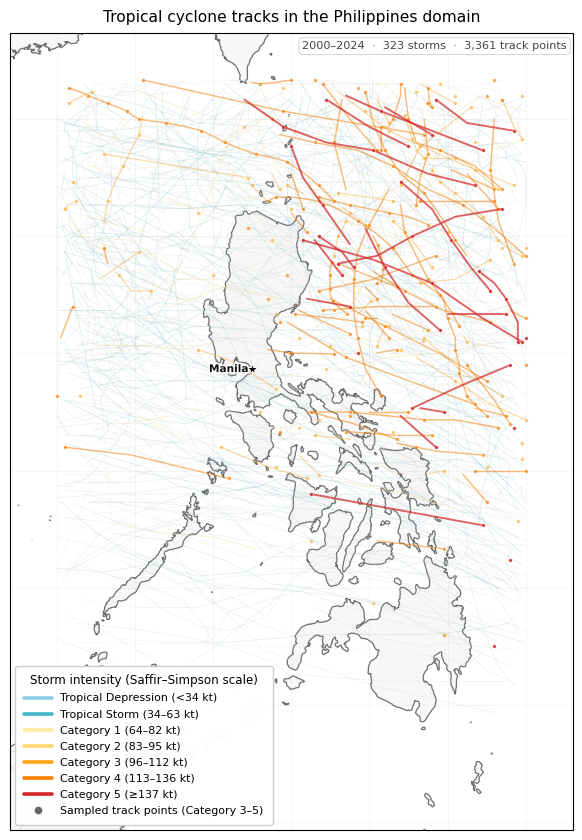

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================
# Category styling (full names)
# =========================
CAT_META = {
    "Tropical Depression": dict(color="#8ecae6", lw=0.45, alpha=0.10, zorder=2,
                               label="Tropical Depression (<34 kt)"),
    "Tropical Storm": dict(color="#41b6c4", lw=0.50, alpha=0.14, zorder=2,
                          label="Tropical Storm (34–63 kt)"),
    "Category 1": dict(color="#feec9f", lw=0.55, alpha=0.18, zorder=3,
                       label="Category 1 (64–82 kt)"),
    "Category 2": dict(color="#fdd870", lw=0.65, alpha=0.24, zorder=3,
                       label="Category 2 (83–95 kt)"),
    "Category 3": dict(color="#fca311", lw=0.85, alpha=0.36, zorder=4,
                       label="Category 3 (96–112 kt)"),
    "Category 4": dict(color="#f77f00", lw=1.05, alpha=0.50, zorder=5,
                       label="Category 4 (113–136 kt)"),
    "Category 5": dict(color="#d62828", lw=1.35, alpha=0.72, zorder=6,
                       label="Category 5 (≥137 kt)"),
}

CAT_ORDER = list(CAT_META.keys())

CITIES = [
    dict(name="Manila", lat=14.5995, lon=120.9842, anchor=(-0.08, 0.0)),
]

def classify_cat(v):
    if pd.isna(v): return None
    if v < 34:     return "Tropical Depression"
    elif v < 64:   return "Tropical Storm"
    elif v < 83:   return "Category 1"
    elif v < 96:   return "Category 2"
    elif v < 113:  return "Category 3"
    elif v < 137:  return "Category 4"
    else:          return "Category 5"

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(9, 8.5), subplot_kw={"projection": proj}, facecolor="white")

# =========================
# Base map
# =========================
pad = 1.2
ax.set_extent([
    PH_BOUNDS["lon_min"] - pad, PH_BOUNDS["lon_max"] + pad,
    PH_BOUNDS["lat_min"] - pad, PH_BOUNDS["lat_max"] + pad,
], crs=proj)

ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="#f7f7f7", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.9, edgecolor="#6f6f6f", zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.45, edgecolor="#9a9a9a", alpha=0.5, zorder=1)
ax.gridlines(draw_labels=False, alpha=0.15, linewidth=0.6)

# =========================
# Prepare data
# =========================
ph_points_plot = ph_points.copy()

required_cols = ["storm_id", "year", "lat", "lon", "wind_kt", "point_index"]
missing = [c for c in required_cols if c not in ph_points_plot.columns]
if missing:
    raise ValueError(f"ph_points is missing required columns: {missing}")

ph_points_plot = ph_points_plot.loc[ph_points_plot["year"] >= 2000].copy()

if ph_points_plot.empty:
    raise ValueError("No PH track points remain after filtering to year >= 2000.")

ph_points_plot["category"] = ph_points_plot["wind_kt"].apply(classify_cat)
ph_points_plot = ph_points_plot.sort_values(["storm_id", "point_index"])

n_storms = ph_points_plot["storm_id"].nunique()
n_points = len(ph_points_plot)
y0 = int(ph_points_plot["year"].min())
y1 = int(ph_points_plot["year"].max())

# =========================
# Grey underlay (all tracks)
# =========================
for sid, grp in ph_points_plot.groupby("storm_id"):
    grp = grp.sort_values("point_index")
    if len(grp) >= 2:
        ax.plot(
            grp["lon"].values, grp["lat"].values,
            color="#d3d3d3", lw=0.45, alpha=0.22,
            solid_capstyle="round", solid_joinstyle="round",
            transform=proj, zorder=1.5
        )

# =========================
# Category line overlays
# =========================
for cat in CAT_ORDER:
    st = CAT_META[cat]
    for sid, grp in ph_points_plot.groupby("storm_id"):
        grp = grp.reset_index(drop=True)
        grp["cat_block"] = (grp["category"] != grp["category"].shift()).cumsum()

        for (c, _), seg in grp.groupby(["category", "cat_block"]):
            if c != cat or len(seg) < 2:
                continue

            ax.plot(
                seg["lon"].values, seg["lat"].values,
                color=st["color"], lw=st["lw"], alpha=st["alpha"],
                solid_capstyle="round", solid_joinstyle="round",
                transform=proj, zorder=st["zorder"]
            )

# =========================
# Sampled track points (Category 3–5 only)
# =========================
POINT_CATS = ["Category 3", "Category 4", "Category 5"]
POINT_EVERY = 2

for cat in POINT_CATS:
    st = CAT_META[cat]

    pts = (
        ph_points_plot.loc[ph_points_plot["category"] == cat]
        .sort_values(["storm_id", "point_index"])
        .groupby("storm_id", group_keys=False)
        .apply(lambda g: g.iloc[::POINT_EVERY])
        .reset_index(drop=True)
    )

    if len(pts) == 0:
        continue

    ax.scatter(
        pts["lon"],
        pts["lat"],
        s=6.2,
        c=st["color"],
        alpha=min(0.9, st["alpha"] + 0.22),
        edgecolors="white",
        linewidths=0.20,
        transform=proj,
        zorder=st["zorder"] + 0.25,
    )

# =========================
# Cities
# =========================
for city in CITIES:
    ax.plot(
        city["lon"], city["lat"],
        marker="*", markersize=8,
        color="black", markeredgecolor="white",
        markeredgewidth=0.6,
        transform=proj, zorder=20,
    )

    dx, dy = city["anchor"]
    ha = "right" if dx < 0 else "left"

    txt = ax.text(
        city["lon"] + dx, city["lat"] + dy,
        city["name"],
        fontsize=7.6, ha=ha, va="center",
        color="#111111", fontweight="bold",
        transform=proj, zorder=21,
    )
    txt.set_path_effects([
        patheffects.withStroke(linewidth=2.0, foreground="white")
    ])

# =========================
# Legend
# =========================
handles = [
    Line2D([0], [0],
           color=CAT_META[cat]["color"], lw=2.6,
           label=CAT_META[cat]["label"],
           solid_capstyle="round")
    for cat in CAT_ORDER
]

handles.append(
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="#666666",
        markeredgecolor="white",
        markeredgewidth=0.3,
        markersize=5.8,
        label="Sampled track points (Category 3–5)"
    )
)

ax.legend(
    handles=handles,
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=0.98,
    fontsize=7.9,
    title="Storm intensity (Saffir–Simpson scale)",
    title_fontsize=8.6,
    handlelength=2.5,
    borderpad=0.8,
    labelspacing=0.55,
)

# =========================
# Stats box
# =========================
ax.text(
    0.99, 0.99,
    f"{y0}–{y1}  ·  {n_storms} storms  ·  {n_points:,} track points",
    transform=ax.transAxes,
    ha="right", va="top",
    fontsize=8.1, color="#444444",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="#cccccc",
        linewidth=0.6,
        alpha=0.95
    ),
    zorder=10
)

ax.set_title(
    "Tropical cyclone tracks in the Philippines domain",
    fontsize=11.2, pad=8
)

plt.tight_layout()
plt.savefig(
    "ph_tracks_full_points_cat3to5.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

### Distribution + annual trend

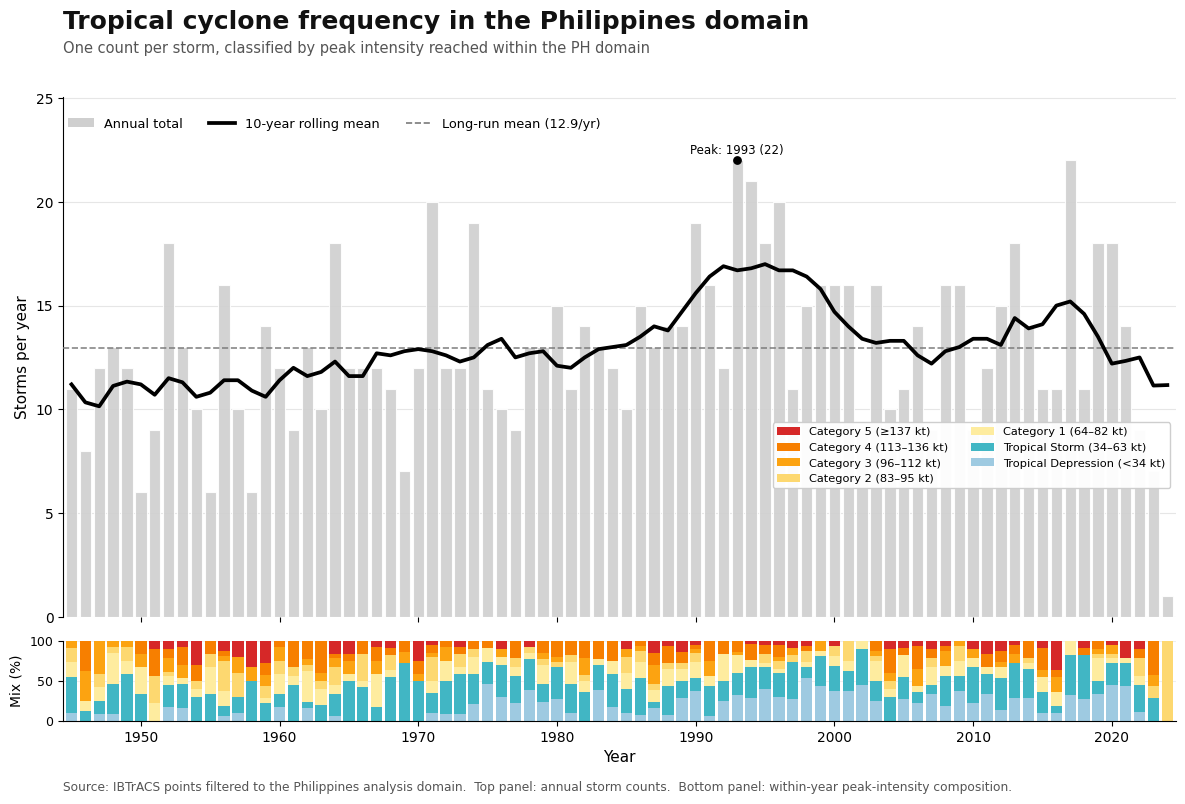

In [ ]:
# =========================
# Hero Plot — Annual frequency + category composition
# Cleaned layout / hierarchy version
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

CAT_META = {
    "TD": dict(color="#9ecae1", label="Tropical Depression (<34 kt)"),
    "TS": dict(color="#41b6c4", label="Tropical Storm (34–63 kt)"),
    "Category 1": dict(color="#feec9f", label="Category 1 (64–82 kt)"),
    "Category 2": dict(color="#fdd870", label="Category 2 (83–95 kt)"),
    "Category 3": dict(color="#fca311", label="Category 3 (96–112 kt)"),
    "Category 4": dict(color="#f77f00", label="Category 4 (113–136 kt)"),
    "Category 5": dict(color="#d62828", label="Category 5 (≥137 kt)"),
}

cats = ["TD", "TS", "Category 1", "Category 2", "Category 3", "Category 4", "Category 5"]

def classify_cat(v):
    if pd.isna(v): return None
    if v < 34:     return "TD"
    elif v < 64:   return "TS"
    elif v < 83:   return "Category 1"
    elif v < 96:   return "Category 2"
    elif v < 113:  return "Category 3"
    elif v < 137:  return "Category 4"
    else:          return "Category 5"

# ── per-storm peak ────────────────────────────────────────────────────────
ph_points_plot = ph_points.copy()
ph_points_plot["category"] = ph_points_plot["wind_kt"].apply(classify_cat)

peak_idx = (
    ph_points_plot
    .dropna(subset=["storm_id", "wind_kt", "category", "year"])
    .groupby("storm_id")["wind_kt"]
    .idxmax()
)

storm_peak = (
    ph_points_plot.loc[peak_idx, ["storm_id", "year", "category", "wind_kt"]]
    .rename(columns={"category": "peak_cat"})
    .sort_values(["year", "storm_id"])
    .reset_index(drop=True)
)

y0 = int(storm_peak["year"].min())
y1 = int(storm_peak["year"].max())
all_years = np.arange(y0, y1 + 1)

annual = (
    storm_peak
    .groupby(["year", "peak_cat"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=all_years, columns=cats, fill_value=0)
)

annual_total  = annual.sum(axis=1)
roll10        = annual_total.rolling(10, center=True, min_periods=5).mean()
mean_annual   = annual_total.mean()
annual_pct    = annual.div(annual_total.replace(0, np.nan), axis=0).fillna(0)
max_year      = int(annual_total.idxmax())
max_val       = int(annual_total.max())

# ── figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12.5, 8.0), facecolor="white")

gs = fig.add_gridspec(
    nrows=2, ncols=1,
    height_ratios=[5.2, 0.8],
    hspace=0.08,
)

ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

# ── top panel ─────────────────────────────────────────────────────────────
ax_top.bar(all_years, annual_total.values,
           width=0.82, color="#cfcfcf", alpha=0.9,
           edgecolor="white", linewidth=0.8, zorder=2)

ax_top.plot(all_years, roll10.values,
            color="black", linewidth=2.7, zorder=4)

ax_top.axhline(mean_annual, color="#7a7a7a", linestyle="--",
               linewidth=1.2, alpha=0.9, zorder=3)

ax_top.scatter([max_year], [max_val], color="black", s=28, zorder=5)
ax_top.text(max_year, max_val + 0.2,
            f"Peak: {max_year} ({max_val})",
            ha="center", va="bottom", fontsize=8.5, color="black")

ax_top.set_ylabel("Storms per year", fontsize=11)
ax_top.set_ylim(0, max(max_val, np.nanmax(roll10)) * 1.14)
ax_top.grid(axis="y", color="#e6e6e6", linewidth=0.8)
ax_top.grid(axis="x", visible=False)
ax_top.spines[["top", "right", "bottom"]].set_visible(False)
ax_top.tick_params(axis="x", labelbottom=False)

legend_items = [
    Patch(facecolor="#cfcfcf", edgecolor="none", label="Annual total"),
    Line2D([0], [0], color="black", lw=2.7, label="10-year rolling mean"),
    Line2D([0], [0], color="#7a7a7a", lw=1.2, ls="--",
           label=f"Long-run mean ({mean_annual:.1f}/yr)"),
]
ax_top.legend(handles=legend_items, loc="upper left", frameon=False,
              fontsize=9.3, ncol=3,
              bbox_to_anchor=(0.0, 0.97), borderaxespad=0.0)

# ── bottom panel ──────────────────────────────────────────────────────────
bottom = np.zeros(len(all_years), dtype=float)
for cat in cats:
    vals = annual_pct[cat].values * 100.0
    ax_bot.bar(all_years, vals, bottom=bottom, width=0.82,
               color=CAT_META[cat]["color"], edgecolor="none", zorder=2)
    bottom += vals

ax_bot.set_ylim(0, 100)
ax_bot.set_ylabel("Mix (%)", fontsize=10)
ax_bot.set_xlabel("Year", fontsize=11)
ax_bot.set_yticks([0, 50, 100])
ax_bot.set_yticklabels(["0", "50", "100"], fontsize=9)
ax_bot.grid(axis="y", color="#eeeeee", linewidth=0.8)
ax_bot.grid(axis="x", visible=False)
ax_bot.spines[["top", "right"]].set_visible(False)
ax_bot.set_xlim(y0 - 0.6, y1 + 0.6)

# ── category legend — placed INSIDE bottom panel, upper right ─────────────
cat_handles = [
    Patch(facecolor=CAT_META[c]["color"], edgecolor="none",
          label=CAT_META[c]["label"])
    for c in cats[::-1]
]
ax_bot.legend(
    handles=cat_handles,
    loc="upper right",
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=0.95,
    fontsize=8.2,
    bbox_to_anchor=(1.0, 3.8),   # pushes it up into the top panel's lower area
)

# ── titles — stacked with enough vertical clearance ───────────────────────
fig.subplots_adjust(top=0.88, bottom=0.10, left=0.09, right=0.98)

fig.text(0.09, 0.965,
         "Tropical cyclone frequency in the Philippines domain",
         ha="left", fontsize=18, fontweight="bold", color="#111111")

fig.text(0.09, 0.935,
         "One count per storm, classified by peak intensity reached within the PH domain",
         ha="left", fontsize=10.5, color="#555555")

fig.text(0.09, 0.012,
         "Source: IBTrACS points filtered to the Philippines analysis domain.  "
         "Top panel: annual storm counts.  Bottom panel: within-year peak-intensity composition.",
         ha="left", fontsize=8.8, color="#555555")

plt.savefig("ph_hero_plot_two_panel_clean.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
# =========================
# Cell 11 — Load benchmark network and population
# =========================
# Here we read PyPSA-PH buses, lines, generators, and WorldPop,
# then build:
# - a line table with endpoint coordinates
# - a benchmark graph
# - sampled line points
# - nearest-bus population assignments

# --- Buses ---
buses = pd.read_csv(BUSES_CSV).rename(columns={"name": "bus_id", "x": "lon", "y": "lat"}).copy()
for c in ["lon", "lat", "v_nom"]:
    if c in buses.columns:
        buses[c] = pd.to_numeric(buses[c], errors="coerce")

buses = buses.dropna(subset=["bus_id", "lon", "lat"]).copy()
buses["bus_id"] = buses["bus_id"].astype(str)

# --- Lines ---
lines = pd.read_csv(LINES_CSV).copy()
lines["bus0"] = lines["bus0"].astype(str)
lines["bus1"] = lines["bus1"].astype(str)

# --- Generators ---
generators = pd.read_csv(GENERATORS_CSV).copy()
if "bus" in generators.columns:
    generators["bus"] = generators["bus"].astype(str)

print("Buses:", len(buses))
print("Lines:", len(lines))
print("Generators:", len(generators))

display(buses.head())
display(lines.head())
display(generators.head())

# Build a geographic line table by joining bus coordinates to line endpoints
line_df = lines.merge(
    buses[["bus_id", "lat", "lon"]],
    left_on="bus0",
    right_on="bus_id",
    how="left",
).rename(columns={"lat": "lat0", "lon": "lon0"}).drop(columns=["bus_id"])

line_df = line_df.merge(
    buses[["bus_id", "lat", "lon"]],
    left_on="bus1",
    right_on="bus_id",
    how="left",
).rename(columns={"lat": "lat1", "lon": "lon1"}).drop(columns=["bus_id"])

line_df = line_df.dropna(subset=["lat0", "lon0", "lat1", "lon1"]).copy()
line_df["lat_mid"] = (line_df["lat0"] + line_df["lat1"]) / 2.0
line_df["lon_mid"] = (line_df["lon0"] + line_df["lon1"]) / 2.0
line_df["line_id"] = np.arange(len(line_df)).astype(str)

# Build the benchmark topology graph
G_base = nx.Graph()
for _, b in buses.iterrows():
    G_base.add_node(b["bus_id"])
for _, l in line_df.iterrows():
    G_base.add_edge(l["bus0"], l["bus1"], line_id=l["line_id"])

# Sample points along each transmission line
line_samples = build_line_samples(line_df, n_samples=LINE_SAMPLE_POINTS)

# Load and crop WorldPop
worldpop = load_worldpop_xyz(WORLDPOP_CSV)
pop_ph = worldpop[
    worldpop["lat"].between(PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"])
    & worldpop["lon"].between(PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"])
    & (worldpop["pop_value"] > 0)
].copy()

# Assign each population cell to one nearest bus
buses_nb, pop_assignment = assign_population_to_nearest_bus(pop_ph=pop_ph, buses=buses)

print("Graph nodes:", G_base.number_of_nodes())
print("Graph edges:", G_base.number_of_edges())
print("Population rows in PH box:", len(pop_ph))
print("Population rows assigned:", len(pop_assignment))
print("Unique buses receiving population:", int((buses_nb["bus_pop_local_nb"] > 0).sum()))
print("Assigned total population:", f"{buses_nb['bus_pop_local_nb'].sum():,.0f}")
print("True total population in pop_ph:", f"{pop_ph['pop_value'].sum():,.0f}")

display(
    buses_nb[["bus_id", "lat", "lon", "bus_pop_local_nb"]]
    .sort_values("bus_pop_local_nb", ascending=False)
    .head(15)
)

Buses: 192
Lines: 236
Generators: 425


,bus_id,lon,lat,v_nom
0,01AMBKLAO,120.741167,16.458580,230
1,01ANGAT,121.030976,14.922529,230
2,01ANGSJO_TP2,121.166303,14.907693,115
3,01ANGSJO_TP4,121.166303,14.907693,115
4,01BAKUN,120.823858,16.763519,230


,name,cables,bus0,bus1,s_nom,x,r
0,115_01BNTAY_01CURIMAO,1,01BNTAY,01CURIMAO,115.0,10.669251,5.109878
1,115_01BNTAY_01SNESTBN,1,01BNTAY,01SNESTBN,115.0,6.439971,3.084327
2,115_01CURIMAO_01LAOAG,1,01CURIMAO,01LAOAG,115.0,5.641781,2.702046
3,115_01LAOAG_01PASUQUIN,1,01LAOAG,01PASUQUIN,115.0,3.341738,1.600475
4,115_01LAOAG_01BURGOS,1,01LAOAG,01BURGOS,115.0,38.691844,18.530878


,name,bus,p_nom,carrier,build_year
0,01ACNPC_G01,01CNCEPCN,3.2,Biomass,2017
1,01AMBUK_U01,01AMBKLAO,37.5,Hydro,1956
2,01AMBUK_U02,01AMBKLAO,37.5,Hydro,1956
3,01AMBUK_U03,01AMBKLAO,37.5,Hydro,1956
4,01AMPHAW_G01,01LATRINI,12.5,Hydro,1991


Graph nodes: 192
Graph edges: 233
Population rows in PH box: 372755
Population rows assigned: 372755
Unique buses receiving population: 187
Assigned total population: 154,555,313
True total population in pop_ph: 154,555,313


,bus_id,lat,lon,bus_pop_local_nb
59,02QUEZON,14.665666,121.021695,5.562161e+06
145,08NABAS,11.814408,122.095481,4.499376e+06
152,09PITOG,6.940741,121.991801,4.008819e+06
55,02DOLORES,14.572693,121.141174,3.957143e+06
191,14TACUR,6.669240,124.687087,3.408102e+06
60,02ZAPOTE,14.484570,120.987479,3.117837e+06
71,03DASMAEHV,14.312346,120.951042,2.968677e+06
57,02MANILA,14.580731,120.999348,2.783354e+06
56,02DONAIMELDA,14.622157,121.015571,2.621333e+06
26,01EHVSJOS,14.821626,121.048310,2.393120e+06


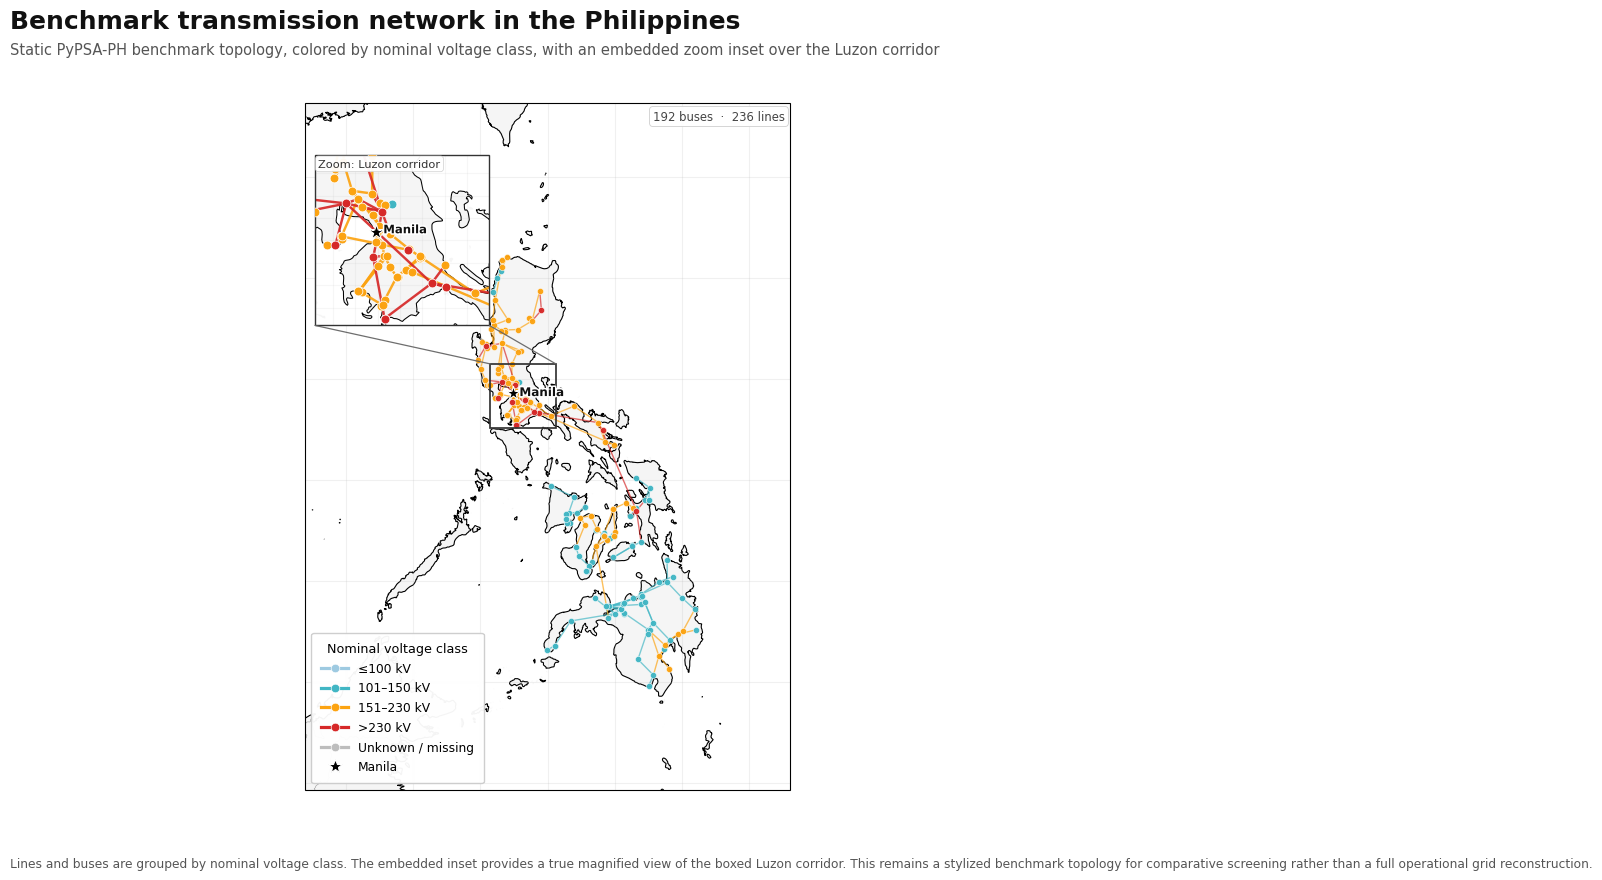

In [ ]:
# =========================
# Hero Map — Benchmark network with embedded true zoom inset + Manila
# Upper-left inset INSIDE main map, pushed higher
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, ConnectionPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()

# ── Manila ────────────────────────────────────────────────────────────────
MANILA = {
    "name": "Manila",
    "lon": 120.9842,
    "lat": 14.5995,
}

# ── voltage classification ────────────────────────────────────────────────
def classify_voltage(v):
    if pd.isna(v):
        return "Unknown"
    elif v <= 100:
        return "≤100 kV"
    elif v <= 150:
        return "101–150 kV"
    elif v <= 230:
        return "151–230 kV"
    else:
        return ">230 kV"

VOLT_META = {
    "≤100 kV":    {"color": "#9ecae1", "label": "≤100 kV"},
    "101–150 kV": {"color": "#41b6c4", "label": "101–150 kV"},
    "151–230 kV": {"color": "#fca311", "label": "151–230 kV"},
    ">230 kV":    {"color": "#d62828", "label": ">230 kV"},
    "Unknown":    {"color": "#bdbdbd", "label": "Unknown / missing"},
}
CLASS_ORDER = ["≤100 kV", "101–150 kV", "151–230 kV", ">230 kV", "Unknown"]

# ── prepare buses ─────────────────────────────────────────────────────────
buses_plot = buses_nb.copy()
buses_plot["volt_class"] = buses_plot["v_nom"].apply(classify_voltage)

# ── prepare lines ─────────────────────────────────────────────────────────
line_plot = line_df.copy()

if "v_nom" in line_plot.columns:
    line_plot["volt_class"] = line_plot["v_nom"].apply(classify_voltage)
else:
    bus_v = buses_plot.set_index("bus_id")["v_nom"].to_dict()

    def infer_line_v(row):
        v0 = bus_v.get(row["bus0"], np.nan) if "bus0" in row.index else np.nan
        v1 = bus_v.get(row["bus1"], np.nan) if "bus1" in row.index else np.nan
        vals = [v for v in [v0, v1] if pd.notna(v)]
        return max(vals) if vals else np.nan

    if {"bus0", "bus1"}.issubset(line_plot.columns):
        line_plot["v_nom_inferred"] = line_plot.apply(infer_line_v, axis=1)
        line_plot["volt_class"] = line_plot["v_nom_inferred"].apply(classify_voltage)
    else:
        line_plot["volt_class"] = "Unknown"

required_line_cols = {"lon0", "lat0", "lon1", "lat1"}
missing_cols = required_line_cols - set(line_plot.columns)
if missing_cols:
    raise ValueError(f"line_df is missing required columns: {missing_cols}")

# ── helpers ───────────────────────────────────────────────────────────────
def setup_map_clean(ax, extent, coastline_lw=0.75, border_lw=0.4, grid_alpha=0.14):
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=coastline_lw, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=border_lw, alpha=0.35, zorder=1)
    ax.gridlines(draw_labels=False, alpha=grid_alpha)

def line_intersects_box(df, lon_min, lon_max, lat_min, lat_max):
    end0_in = df["lon0"].between(lon_min, lon_max) & df["lat0"].between(lat_min, lat_max)
    end1_in = df["lon1"].between(lon_min, lon_max) & df["lat1"].between(lat_min, lat_max)

    bbox_overlap = (
        (df[["lon0", "lon1"]].max(axis=1) >= lon_min) &
        (df[["lon0", "lon1"]].min(axis=1) <= lon_max) &
        (df[["lat0", "lat1"]].max(axis=1) >= lat_min) &
        (df[["lat0", "lat1"]].min(axis=1) <= lat_max)
    )
    return end0_in | end1_in | bbox_overlap

def plot_manila(ax, star_size=90, font_size=8.2, dx=0.12, dy=0.05):
    ax.scatter(
        [MANILA["lon"]],
        [MANILA["lat"]],
        s=star_size,
        marker="*",
        c="black",
        edgecolors="white",
        linewidths=0.8,
        transform=proj,
        zorder=20,
    )
    txt = ax.text(
        MANILA["lon"] + dx,
        MANILA["lat"] + dy,
        MANILA["name"],
        transform=proj,
        ha="left",
        va="center",
        fontsize=font_size,
        color="#111111",
        fontweight="bold",
        zorder=21,
    )
    txt.set_path_effects([
        patheffects.withStroke(linewidth=2.2, foreground="white")
    ])

# ── extents ───────────────────────────────────────────────────────────────
main_extent = [
    PH_BOUNDS["lon_min"] - 1.2,
    PH_BOUNDS["lon_max"] + 1.2,
    PH_BOUNDS["lat_min"] - 1.2,
    PH_BOUNDS["lat_max"] + 1.2,
]

zoom_bounds = {
    "lon_min": 120.30,
    "lon_max": 122.25,
    "lat_min": 13.55,
    "lat_max": 15.45,
}
zoom_extent = [
    zoom_bounds["lon_min"],
    zoom_bounds["lon_max"],
    zoom_bounds["lat_min"],
    zoom_bounds["lat_max"],
]

# ── figure and main map ───────────────────────────────────────────────────
fig = plt.figure(figsize=(12.5, 8.8), facecolor="white")
ax = fig.add_subplot(1, 1, 1, projection=proj)

setup_map_clean(ax, main_extent, coastline_lw=0.8, border_lw=0.45, grid_alpha=0.18)

# main lines
for vc in CLASS_ORDER:
    sub = line_plot[line_plot["volt_class"] == vc]
    if len(sub) == 0:
        continue

    lw = 1.0 if vc != "Unknown" else 0.7
    alpha = 0.68 if vc != "Unknown" else 0.42

    for _, row in sub.iterrows():
        ax.plot(
            [row["lon0"], row["lon1"]],
            [row["lat0"], row["lat1"]],
            color=VOLT_META[vc]["color"],
            linewidth=lw,
            alpha=alpha,
            transform=proj,
            zorder=2,
            solid_capstyle="round",
        )

# main buses
for vc in CLASS_ORDER:
    sub = buses_plot[buses_plot["volt_class"] == vc]
    if len(sub) == 0:
        continue

    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=20,
        c=VOLT_META[vc]["color"],
        edgecolors="white",
        linewidths=0.38,
        alpha=0.96,
        transform=proj,
        zorder=3,
    )

# Manila on main map
plot_manila(ax, star_size=105, font_size=8.6, dx=0.18, dy=0.00)

# zoom box on main map
zoom_rect = Rectangle(
    (zoom_bounds["lon_min"], zoom_bounds["lat_min"]),
    zoom_bounds["lon_max"] - zoom_bounds["lon_min"],
    zoom_bounds["lat_max"] - zoom_bounds["lat_min"],
    linewidth=1.25,
    edgecolor="#333333",
    facecolor="none",
    linestyle="-",
    transform=proj,
    zorder=8,
)
ax.add_patch(zoom_rect)

# stats box
ax.text(
    0.99, 0.99,
    f"{len(buses_plot):,} buses  ·  {len(line_plot):,} lines",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8.4,
    color="#444444",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="#cccccc",
        linewidth=0.6,
        alpha=0.95,
    ),
    zorder=10,
)

# legend
legend_handles = [
    Line2D(
        [0], [0],
        color=VOLT_META[k]["color"],
        lw=2.3,
        marker="o",
        markersize=6.2,
        markerfacecolor=VOLT_META[k]["color"],
        markeredgecolor="white",
        markeredgewidth=0.5,
        label=VOLT_META[k]["label"],
    )
    for k in CLASS_ORDER
]
legend_handles.append(
    Line2D(
        [0], [0],
        marker="*",
        color="black",
        markerfacecolor="black",
        markeredgecolor="white",
        markeredgewidth=0.8,
        linestyle="None",
        markersize=10,
        label="Manila",
    )
)

ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=0.96,
    fontsize=8.8,
    title="Nominal voltage class",
    title_fontsize=9.2,
    borderpad=0.8,
    labelspacing=0.55,
    handlelength=2.2,
)

fig.subplots_adjust(top=0.88, bottom=0.10, left=0.06, right=0.98)

fig.text(
    0.09, 0.965,
    "Benchmark transmission network in the Philippines",
    ha="left",
    fontsize=18,
    fontweight="bold",
    color="#111111",
)

fig.text(
    0.09, 0.935,
    "Static PyPSA-PH benchmark topology, colored by nominal voltage class, with an embedded zoom inset over the Luzon corridor",
    ha="left",
    fontsize=10.5,
    color="#555555",
)

fig.text(
    0.09, 0.012,
    "Lines and buses are grouped by nominal voltage class. "
    "The embedded inset provides a true magnified view of the boxed Luzon corridor. "
    "This remains a stylized benchmark topology for comparative screening rather than a full operational grid reconstruction.",
    ha="left",
    fontsize=8.8,
    color="#555555",
)

# ── embedded inset: UPPER LEFT INSIDE main map, moved HIGHER ─────────────
fig.canvas.draw()
axpos = ax.get_position()

inset_w = axpos.width * 0.36
inset_h = axpos.height * 0.36

inset_left = axpos.x0 + axpos.width * 0.02
inset_bottom = axpos.y0 + axpos.height * 0.62   # moved higher from 0.56

in_ax = fig.add_axes(
    [inset_left, inset_bottom, inset_w, inset_h],
    projection=proj
)

setup_map_clean(in_ax, zoom_extent, coastline_lw=0.75, border_lw=0.35, grid_alpha=0.10)

# subset zoom data
line_zoom = line_plot[
    line_intersects_box(
        line_plot,
        zoom_bounds["lon_min"], zoom_bounds["lon_max"],
        zoom_bounds["lat_min"], zoom_bounds["lat_max"]
    )
].copy()

buses_zoom = buses_plot[
    buses_plot["lon"].between(zoom_bounds["lon_min"], zoom_bounds["lon_max"]) &
    buses_plot["lat"].between(zoom_bounds["lat_min"], zoom_bounds["lat_max"])
].copy()

# inset lines
for vc in CLASS_ORDER:
    sub = line_zoom[line_zoom["volt_class"] == vc]
    if len(sub) == 0:
        continue

    lw = 1.75 if vc != "Unknown" else 1.0
    alpha = 0.92 if vc != "Unknown" else 0.55

    for _, row in sub.iterrows():
        in_ax.plot(
            [row["lon0"], row["lon1"]],
            [row["lat0"], row["lat1"]],
            color=VOLT_META[vc]["color"],
            linewidth=lw,
            alpha=alpha,
            transform=proj,
            zorder=2,
            solid_capstyle="round",
        )

# inset buses
for vc in CLASS_ORDER:
    sub = buses_zoom[buses_zoom["volt_class"] == vc]
    if len(sub) == 0:
        continue

    in_ax.scatter(
        sub["lon"],
        sub["lat"],
        s=40,
        c=VOLT_META[vc]["color"],
        edgecolors="white",
        linewidths=0.55,
        alpha=0.99,
        transform=proj,
        zorder=3,
    )

# Manila on inset
plot_manila(in_ax, star_size=130, font_size=8.4, dx=0.08, dy=0.02)

# inset border
for spine in in_ax.spines.values():
    spine.set_edgecolor("#333333")
    spine.set_linewidth(1.0)

in_ax.text(
    0.02, 0.98,
    "Zoom: Luzon corridor",
    transform=in_ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.2,
    color="#333333",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="#cccccc",
        linewidth=0.5,
        alpha=0.95,
    ),
    zorder=10,
)

# connectors from zoom box to inset
con1 = ConnectionPatch(
    xyA=(zoom_bounds["lon_min"], zoom_bounds["lat_max"]), coordsA=ax.transData,
    xyB=(0, 0), coordsB=in_ax.transAxes,
    color="#666666", linewidth=0.9, alpha=0.95, zorder=7
)
con2 = ConnectionPatch(
    xyA=(zoom_bounds["lon_max"], zoom_bounds["lat_max"]), coordsA=ax.transData,
    xyB=(1, 0), coordsB=in_ax.transAxes,
    color="#666666", linewidth=0.9, alpha=0.95, zorder=7
)
fig.add_artist(con1)
fig.add_artist(con2)

plt.savefig(
    "ph_benchmark_network_embedded_zoom_luzon_corridor_upperleft.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

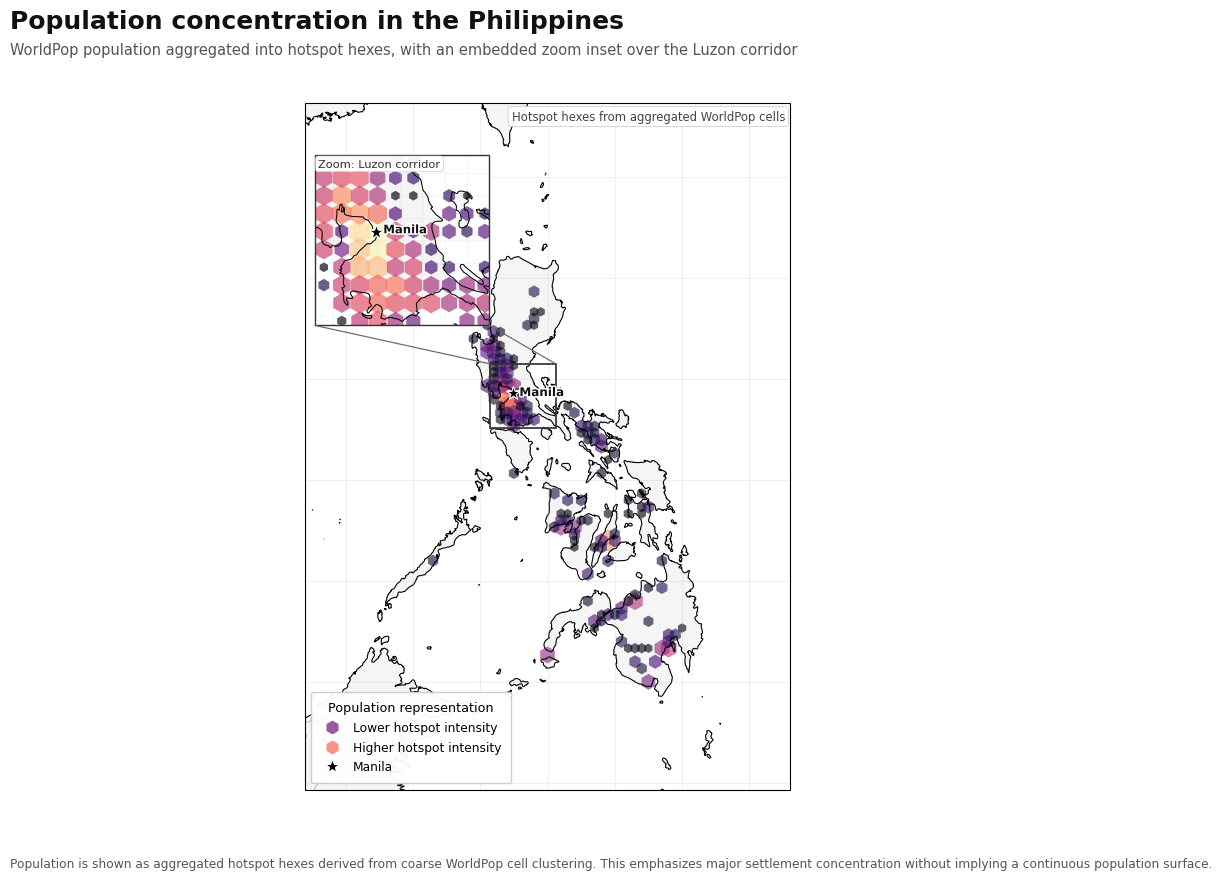

In [ ]:
# =========================
# Hero Map — Population hotspots only
# Same hotspot-cell logic, but HEX markers instead of bubbles
# Same projection, Luzon inset + Manila
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, ConnectionPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()

MANILA = {
    "name": "Manila",
    "lon": 120.9842,
    "lat": 14.5995,
}

def setup_map_clean(ax, extent, coastline_lw=0.75, border_lw=0.4, grid_alpha=0.14):
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=coastline_lw, zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=border_lw, alpha=0.35, zorder=2)
    ax.gridlines(draw_labels=False, alpha=grid_alpha)

def plot_manila(ax, star_size=90, font_size=8.2, dx=0.12, dy=0.05):
    ax.scatter(
        [MANILA["lon"]],
        [MANILA["lat"]],
        s=star_size,
        marker="*",
        c="black",
        edgecolors="white",
        linewidths=0.8,
        transform=proj,
        zorder=20,
    )
    txt = ax.text(
        MANILA["lon"] + dx,
        MANILA["lat"] + dy,
        MANILA["name"],
        transform=proj,
        ha="left",
        va="center",
        fontsize=font_size,
        color="#111111",
        fontweight="bold",
        zorder=21,
    )
    txt.set_path_effects([
        patheffects.withStroke(linewidth=2.2, foreground="white")
    ])

if "pop_ph" not in globals() or pop_ph.empty:
    raise ValueError("pop_ph is missing or empty. Run the WorldPop loading cell first.")

main_extent = [
    PH_BOUNDS["lon_min"] - 1.2,
    PH_BOUNDS["lon_max"] + 1.2,
    PH_BOUNDS["lat_min"] - 1.2,
    PH_BOUNDS["lat_max"] + 1.2,
]

zoom_bounds = {
    "lon_min": 120.30,
    "lon_max": 122.25,
    "lat_min": 13.55,
    "lat_max": 15.45,
}
zoom_extent = [
    zoom_bounds["lon_min"],
    zoom_bounds["lon_max"],
    zoom_bounds["lat_min"],
    zoom_bounds["lat_max"],
]

# --- Aggregate WorldPop into coarse hotspot cells ---
LON_STEP = 0.20
LAT_STEP = 0.20
TOP_N_MAIN = 140
TOP_N_ZOOM = 80

pop_plot = pop_ph.copy()

pop_plot["lon_bin"] = (np.floor(pop_plot["lon"] / LON_STEP) * LON_STEP).round(4)
pop_plot["lat_bin"] = (np.floor(pop_plot["lat"] / LAT_STEP) * LAT_STEP).round(4)

hotspots = (
    pop_plot.groupby(["lon_bin", "lat_bin"], as_index=False)["pop_value"]
    .sum()
    .rename(columns={"lon_bin": "lon", "lat_bin": "lat", "pop_value": "pop_sum"})
)

hotspots = hotspots[hotspots["pop_sum"] > 0].copy()
hotspots["pop_log"] = np.log1p(hotspots["pop_sum"])

# keep strongest cells only
hotspots_main = hotspots.nlargest(TOP_N_MAIN, "pop_sum").copy()

# hex marker size scaling
pmin = hotspots_main["pop_log"].min()
pmax = hotspots_main["pop_log"].max()
if pmax > pmin:
    hotspots_main["size"] = 45 + 260 * (hotspots_main["pop_log"] - pmin) / (pmax - pmin)
else:
    hotspots_main["size"] = 80.0

# zoom subset
hotspots_zoom = hotspots[
    hotspots["lon"].between(zoom_bounds["lon_min"], zoom_bounds["lon_max"]) &
    hotspots["lat"].between(zoom_bounds["lat_min"], zoom_bounds["lat_max"])
].copy()

if len(hotspots_zoom) > 0:
    hotspots_zoom = hotspots_zoom.nlargest(min(TOP_N_ZOOM, len(hotspots_zoom)), "pop_sum").copy()
    pmin_z = hotspots_zoom["pop_log"].min()
    pmax_z = hotspots_zoom["pop_log"].max()
    if pmax_z > pmin_z:
        hotspots_zoom["size"] = 40 + 300 * (hotspots_zoom["pop_log"] - pmin_z) / (pmax_z - pmin_z)
    else:
        hotspots_zoom["size"] = 90.0

fig = plt.figure(figsize=(12.5, 8.8), facecolor="white")
ax = fig.add_subplot(1, 1, 1, projection=proj)

setup_map_clean(ax, main_extent, coastline_lw=0.8, border_lw=0.45, grid_alpha=0.18)

# main HEX marker layer
ax.scatter(
    hotspots_main["lon"],
    hotspots_main["lat"],
    s=hotspots_main["size"],
    c=hotspots_main["pop_log"],
    cmap="magma",
    alpha=0.62,
    marker="h",
    edgecolors="none",
    transform=proj,
    zorder=1.5,
)

plot_manila(ax, star_size=105, font_size=8.6, dx=0.18, dy=0.00)

zoom_rect = Rectangle(
    (zoom_bounds["lon_min"], zoom_bounds["lat_min"]),
    zoom_bounds["lon_max"] - zoom_bounds["lon_min"],
    zoom_bounds["lat_max"] - zoom_bounds["lat_min"],
    linewidth=1.25,
    edgecolor="#333333",
    facecolor="none",
    linestyle="-",
    transform=proj,
    zorder=8,
)
ax.add_patch(zoom_rect)

# safer wording than "155 million people"
ax.text(
    0.99, 0.99,
    "Hotspot hexes from aggregated WorldPop cells",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8.4,
    color="#444444",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="#cccccc",
        linewidth=0.6,
        alpha=0.95,
    ),
    zorder=10,
)

legend_handles = [
    Line2D(
        [0], [0],
        marker="h",
        linestyle="None",
        markerfacecolor=plt.cm.magma(0.35),
        markeredgecolor="none",
        alpha=0.75,
        markersize=10,
        label="Lower hotspot intensity",
    ),
    Line2D(
        [0], [0],
        marker="h",
        linestyle="None",
        markerfacecolor=plt.cm.magma(0.70),
        markeredgecolor="none",
        alpha=0.75,
        markersize=10,
        label="Higher hotspot intensity",
    ),
    Line2D(
        [0], [0],
        marker="*",
        color="black",
        markerfacecolor="black",
        markeredgecolor="white",
        markeredgewidth=0.8,
        linestyle="None",
        markersize=10,
        label="Manila",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=0.96,
    fontsize=8.8,
    title="Population representation",
    title_fontsize=9.2,
    borderpad=0.8,
    labelspacing=0.55,
    handlelength=1.8,
)

fig.subplots_adjust(top=0.88, bottom=0.10, left=0.06, right=0.98)

fig.text(
    0.09, 0.965,
    "Population concentration in the Philippines",
    ha="left",
    fontsize=18,
    fontweight="bold",
    color="#111111",
)

fig.text(
    0.09, 0.935,
    "WorldPop population aggregated into hotspot hexes, with an embedded zoom inset over the Luzon corridor",
    ha="left",
    fontsize=10.5,
    color="#555555",
)

fig.text(
    0.09, 0.012,
    "Population is shown as aggregated hotspot hexes derived from coarse WorldPop cell clustering. This emphasizes major settlement concentration without implying a continuous population surface.",
    ha="left",
    fontsize=8.8,
    color="#555555",
)

# inset
fig.canvas.draw()
axpos = ax.get_position()

inset_w = axpos.width * 0.36
inset_h = axpos.height * 0.36
inset_left = axpos.x0 + axpos.width * 0.02
inset_bottom = axpos.y0 + axpos.height * 0.62

in_ax = fig.add_axes([inset_left, inset_bottom, inset_w, inset_h], projection=proj)
setup_map_clean(in_ax, zoom_extent, coastline_lw=0.75, border_lw=0.35, grid_alpha=0.10)

if len(hotspots_zoom) > 0:
    in_ax.scatter(
        hotspots_zoom["lon"],
        hotspots_zoom["lat"],
        s=hotspots_zoom["size"],
        c=hotspots_zoom["pop_log"],
        cmap="magma",
        alpha=0.68,
        marker="h",
        edgecolors="none",
        transform=proj,
        zorder=1.5,
    )

plot_manila(in_ax, star_size=130, font_size=8.4, dx=0.08, dy=0.02)

for spine in in_ax.spines.values():
    spine.set_edgecolor("#333333")
    spine.set_linewidth(1.0)

in_ax.text(
    0.02, 0.98,
    "Zoom: Luzon corridor",
    transform=in_ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.2,
    color="#333333",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="#cccccc",
        linewidth=0.5,
        alpha=0.95,
    ),
    zorder=10,
)

con1 = ConnectionPatch(
    xyA=(zoom_bounds["lon_min"], zoom_bounds["lat_max"]), coordsA=ax.transData,
    xyB=(0, 0), coordsB=in_ax.transAxes,
    color="#666666", linewidth=0.9, alpha=0.95, zorder=7
)
con2 = ConnectionPatch(
    xyA=(zoom_bounds["lon_max"], zoom_bounds["lat_max"]), coordsA=ax.transData,
    xyB=(1, 0), coordsB=in_ax.transAxes,
    color="#666666", linewidth=0.9, alpha=0.95, zorder=7
)
fig.add_artist(con1)
fig.add_artist(con2)

plt.savefig(
    "ph_population_hotspots_hexes_luzon_corridor.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

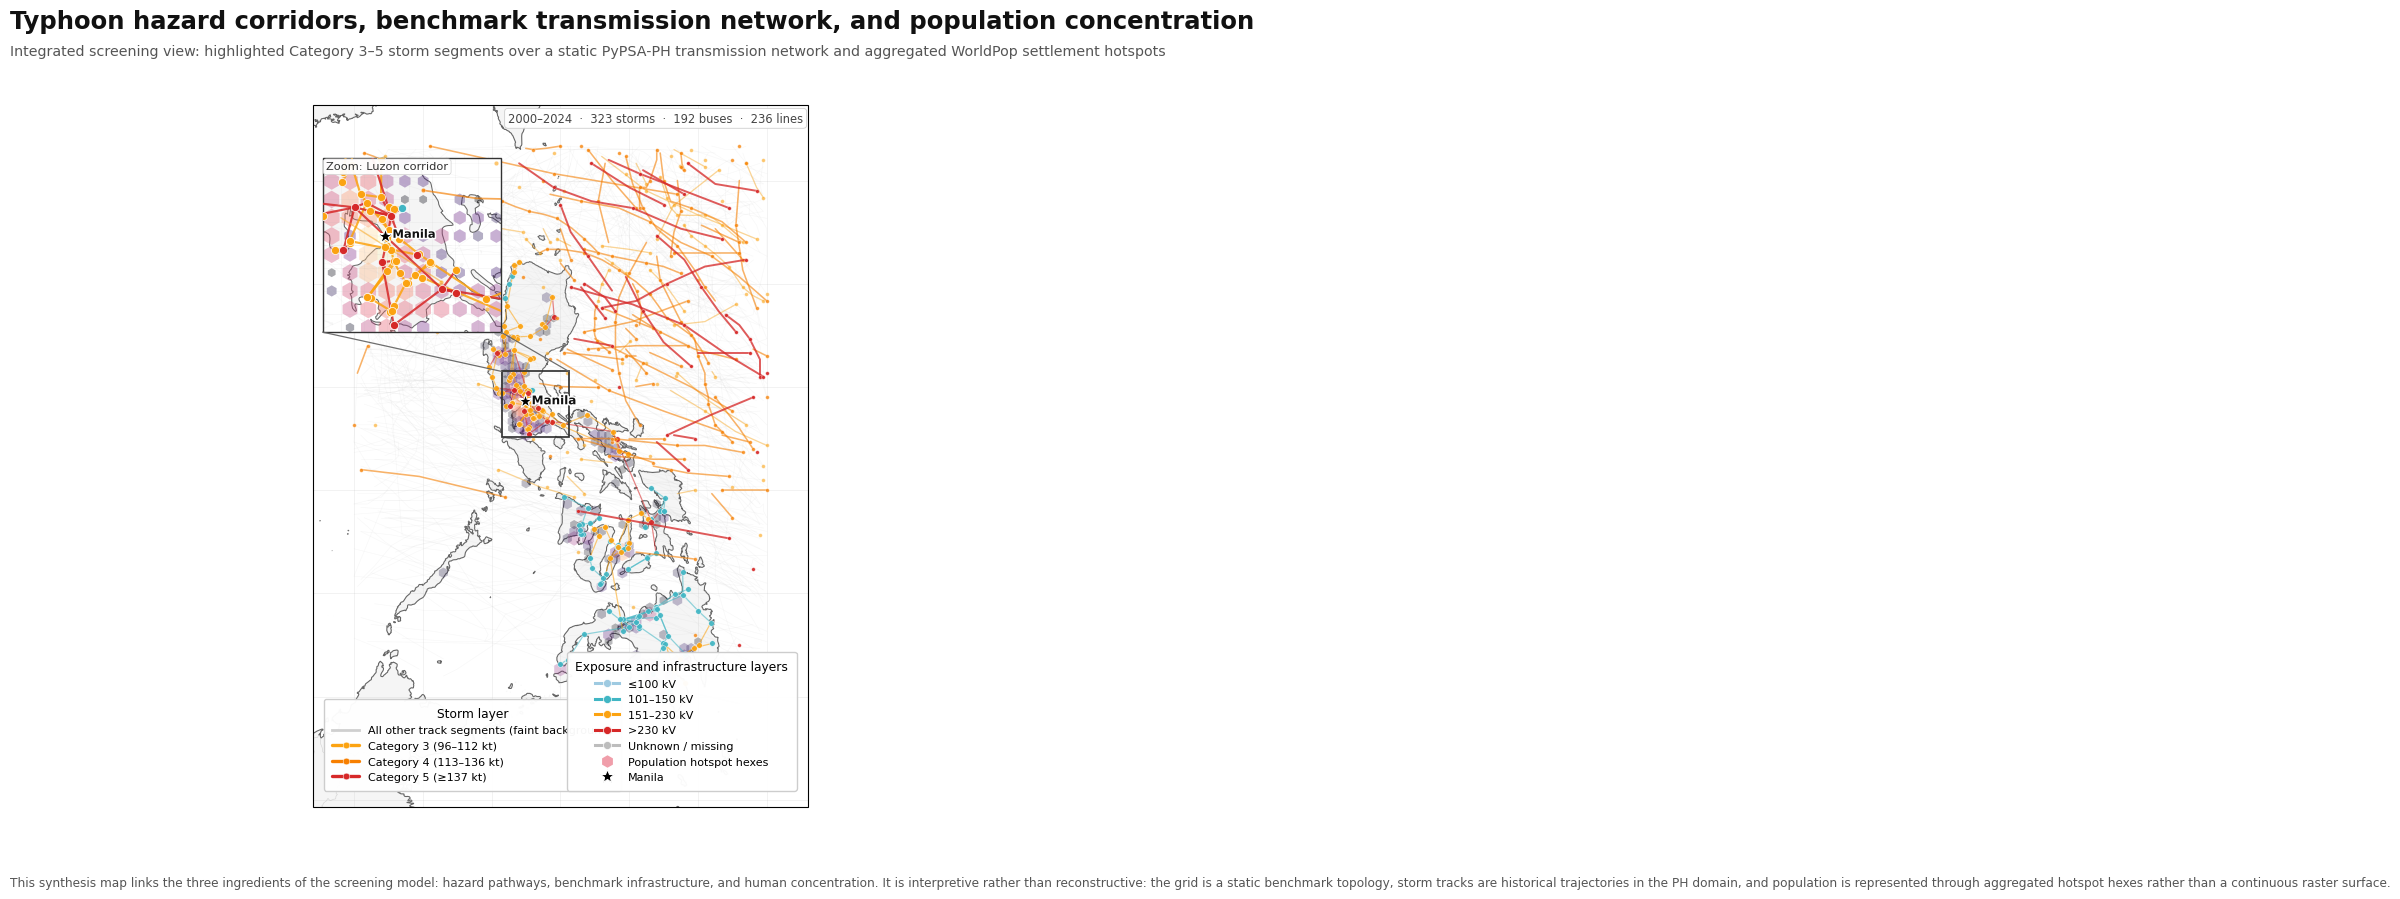

In [ ]:
# =========================
# Integrated Hero Map — Hazard × Grid × Population
# Population hexes + benchmark network + highlighted Cat 3–5 storm tracks
# With embedded true zoom inset over the Luzon corridor
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, ConnectionPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()

# ── Manila ────────────────────────────────────────────────────────────────
MANILA = {
    "name": "Manila",
    "lon": 120.9842,
    "lat": 14.5995,
}

# ── helpers: storms ───────────────────────────────────────────────────────
CAT_META = {
    "Tropical Depression": dict(color="#8ecae6", lw=0.45, alpha=0.08, zorder=4,
                                label="Tropical Depression (<34 kt)"),
    "Tropical Storm": dict(color="#41b6c4", lw=0.50, alpha=0.10, zorder=4,
                           label="Tropical Storm (34–63 kt)"),
    "Category 1": dict(color="#feec9f", lw=0.55, alpha=0.12, zorder=4,
                       label="Category 1 (64–82 kt)"),
    "Category 2": dict(color="#fdd870", lw=0.65, alpha=0.16, zorder=5,
                       label="Category 2 (83–95 kt)"),
    "Category 3": dict(color="#fca311", lw=0.95, alpha=0.42, zorder=6,
                       label="Category 3 (96–112 kt)"),
    "Category 4": dict(color="#f77f00", lw=1.15, alpha=0.58, zorder=7,
                       label="Category 4 (113–136 kt)"),
    "Category 5": dict(color="#d62828", lw=1.40, alpha=0.76, zorder=8,
                       label="Category 5 (≥137 kt)"),
}
CAT_ORDER = list(CAT_META.keys())
HIGHLIGHT_CATS = ["Category 3", "Category 4", "Category 5"]

def classify_cat(v):
    if pd.isna(v):
        return None
    if v < 34:
        return "Tropical Depression"
    elif v < 64:
        return "Tropical Storm"
    elif v < 83:
        return "Category 1"
    elif v < 96:
        return "Category 2"
    elif v < 113:
        return "Category 3"
    elif v < 137:
        return "Category 4"
    else:
        return "Category 5"

# ── helpers: voltage ──────────────────────────────────────────────────────
def classify_voltage(v):
    if pd.isna(v):
        return "Unknown"
    elif v <= 100:
        return "≤100 kV"
    elif v <= 150:
        return "101–150 kV"
    elif v <= 230:
        return "151–230 kV"
    else:
        return ">230 kV"

VOLT_META = {
    "≤100 kV":    {"color": "#9ecae1", "label": "≤100 kV"},
    "101–150 kV": {"color": "#41b6c4", "label": "101–150 kV"},
    "151–230 kV": {"color": "#fca311", "label": "151–230 kV"},
    ">230 kV":    {"color": "#d62828", "label": ">230 kV"},
    "Unknown":    {"color": "#bdbdbd", "label": "Unknown / missing"},
}
CLASS_ORDER = ["≤100 kV", "101–150 kV", "151–230 kV", ">230 kV", "Unknown"]

# ── generic map helpers ───────────────────────────────────────────────────
def setup_map_clean(ax, extent, coastline_lw=0.75, border_lw=0.4, grid_alpha=0.14):
    ax.set_extent(extent, crs=proj)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=coastline_lw, edgecolor="#666666", zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=border_lw, edgecolor="#999999", alpha=0.35, zorder=1)
    ax.gridlines(draw_labels=False, alpha=grid_alpha, linewidth=0.6)

def plot_manila(ax, star_size=95, font_size=8.2, dx=0.12, dy=0.05):
    ax.scatter(
        [MANILA["lon"]],
        [MANILA["lat"]],
        s=star_size,
        marker="*",
        c="black",
        edgecolors="white",
        linewidths=0.8,
        transform=proj,
        zorder=20,
    )
    txt = ax.text(
        MANILA["lon"] + dx,
        MANILA["lat"] + dy,
        MANILA["name"],
        transform=proj,
        ha="left",
        va="center",
        fontsize=font_size,
        color="#111111",
        fontweight="bold",
        zorder=21,
    )
    txt.set_path_effects([
        patheffects.withStroke(linewidth=2.2, foreground="white")
    ])

def line_intersects_box(df, lon_min, lon_max, lat_min, lat_max):
    end0_in = df["lon0"].between(lon_min, lon_max) & df["lat0"].between(lat_min, lat_max)
    end1_in = df["lon1"].between(lon_min, lon_max) & df["lat1"].between(lat_min, lat_max)

    bbox_overlap = (
        (df[["lon0", "lon1"]].max(axis=1) >= lon_min) &
        (df[["lon0", "lon1"]].min(axis=1) <= lon_max) &
        (df[["lat0", "lat1"]].max(axis=1) >= lat_min) &
        (df[["lat0", "lat1"]].min(axis=1) <= lat_max)
    )
    return end0_in | end1_in | bbox_overlap

# ── validate required inputs ──────────────────────────────────────────────
if "ph_points" not in globals() or ph_points.empty:
    raise ValueError("ph_points is missing or empty.")
if "buses_nb" not in globals() or buses_nb.empty:
    raise ValueError("buses_nb is missing or empty.")
if "line_df" not in globals() or line_df.empty:
    raise ValueError("line_df is missing or empty.")
if "pop_ph" not in globals() or pop_ph.empty:
    raise ValueError("pop_ph is missing or empty.")
if "PH_BOUNDS" not in globals():
    raise ValueError("PH_BOUNDS is missing.")

# ── prepare storm data ────────────────────────────────────────────────────
ph_points_plot = ph_points.copy()

required_cols = ["storm_id", "year", "lat", "lon", "wind_kt", "point_index"]
missing = [c for c in required_cols if c not in ph_points_plot.columns]
if missing:
    raise ValueError(f"ph_points is missing required columns: {missing}")

ph_points_plot = ph_points_plot.loc[ph_points_plot["year"] >= 2000].copy()
if ph_points_plot.empty:
    raise ValueError("No PH track points remain after filtering to year >= 2000.")

ph_points_plot["category"] = ph_points_plot["wind_kt"].apply(classify_cat)
ph_points_plot = ph_points_plot.sort_values(["storm_id", "point_index"]).copy()

n_storms = ph_points_plot["storm_id"].nunique()
n_points = len(ph_points_plot)
y0 = int(ph_points_plot["year"].min())
y1 = int(ph_points_plot["year"].max())

# ── prepare bus data ──────────────────────────────────────────────────────
buses_plot = buses_nb.copy()
if "v_nom" not in buses_plot.columns:
    raise ValueError("buses_nb must contain 'v_nom'.")
buses_plot["volt_class"] = buses_plot["v_nom"].apply(classify_voltage)

# ── prepare line data ─────────────────────────────────────────────────────
line_plot = line_df.copy()

required_line_cols = {"lon0", "lat0", "lon1", "lat1"}
missing_line_cols = required_line_cols - set(line_plot.columns)
if missing_line_cols:
    raise ValueError(f"line_df is missing required columns: {missing_line_cols}")

if "v_nom" in line_plot.columns:
    line_plot["volt_class"] = line_plot["v_nom"].apply(classify_voltage)
else:
    bus_v = buses_plot.set_index("bus_id")["v_nom"].to_dict()

    def infer_line_v(row):
        v0 = bus_v.get(row["bus0"], np.nan) if "bus0" in row.index else np.nan
        v1 = bus_v.get(row["bus1"], np.nan) if "bus1" in row.index else np.nan
        vals = [v for v in [v0, v1] if pd.notna(v)]
        return max(vals) if vals else np.nan

    if {"bus0", "bus1"}.issubset(line_plot.columns):
        line_plot["v_nom_inferred"] = line_plot.apply(infer_line_v, axis=1)
        line_plot["volt_class"] = line_plot["v_nom_inferred"].apply(classify_voltage)
    else:
        line_plot["volt_class"] = "Unknown"

# ── prepare population hotspots ───────────────────────────────────────────
LON_STEP = 0.20
LAT_STEP = 0.20
TOP_N_MAIN = 140
TOP_N_ZOOM = 80

pop_plot = pop_ph.copy()
pop_plot = pop_plot.loc[pop_plot["pop_value"] > 0].copy()

pop_plot["lon_bin"] = (np.floor(pop_plot["lon"] / LON_STEP) * LON_STEP).round(4)
pop_plot["lat_bin"] = (np.floor(pop_plot["lat"] / LAT_STEP) * LAT_STEP).round(4)

hotspots = (
    pop_plot.groupby(["lon_bin", "lat_bin"], as_index=False)["pop_value"]
    .sum()
    .rename(columns={"lon_bin": "lon", "lat_bin": "lat", "pop_value": "pop_sum"})
)

hotspots = hotspots.loc[hotspots["pop_sum"] > 0].copy()
hotspots["pop_log"] = np.log1p(hotspots["pop_sum"])

hotspots_main = hotspots.nlargest(TOP_N_MAIN, "pop_sum").copy()
pmin = hotspots_main["pop_log"].min()
pmax = hotspots_main["pop_log"].max()
if pmax > pmin:
    hotspots_main["size"] = 38 + 170 * (hotspots_main["pop_log"] - pmin) / (pmax - pmin)
else:
    hotspots_main["size"] = 75.0

# ── extents ───────────────────────────────────────────────────────────────
main_extent = [
    PH_BOUNDS["lon_min"] - 1.2,
    PH_BOUNDS["lon_max"] + 1.2,
    PH_BOUNDS["lat_min"] - 1.2,
    PH_BOUNDS["lat_max"] + 1.2,
]

zoom_bounds = {
    "lon_min": 120.30,
    "lon_max": 122.25,
    "lat_min": 13.55,
    "lat_max": 15.45,
}
zoom_extent = [
    zoom_bounds["lon_min"],
    zoom_bounds["lon_max"],
    zoom_bounds["lat_min"],
    zoom_bounds["lat_max"],
]

hotspots_zoom = hotspots[
    hotspots["lon"].between(zoom_bounds["lon_min"], zoom_bounds["lon_max"]) &
    hotspots["lat"].between(zoom_bounds["lat_min"], zoom_bounds["lat_max"])
].copy()

if len(hotspots_zoom) > 0:
    hotspots_zoom = hotspots_zoom.nlargest(min(TOP_N_ZOOM, len(hotspots_zoom)), "pop_sum").copy()
    pmin_z = hotspots_zoom["pop_log"].min()
    pmax_z = hotspots_zoom["pop_log"].max()
    if pmax_z > pmin_z:
        hotspots_zoom["size"] = 35 + 220 * (hotspots_zoom["pop_log"] - pmin_z) / (pmax_z - pmin_z)
    else:
        hotspots_zoom["size"] = 85.0

line_zoom = line_plot[
    line_intersects_box(
        line_plot,
        zoom_bounds["lon_min"], zoom_bounds["lon_max"],
        zoom_bounds["lat_min"], zoom_bounds["lat_max"]
    )
].copy()

buses_zoom = buses_plot[
    buses_plot["lon"].between(zoom_bounds["lon_min"], zoom_bounds["lon_max"]) &
    buses_plot["lat"].between(zoom_bounds["lat_min"], zoom_bounds["lat_max"])
].copy()

storm_zoom = ph_points_plot[
    ph_points_plot["lon"].between(zoom_bounds["lon_min"] - 0.3, zoom_bounds["lon_max"] + 0.3) &
    ph_points_plot["lat"].between(zoom_bounds["lat_min"] - 0.3, zoom_bounds["lat_max"] + 0.3)
].copy()

# ── figure ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12.8, 9.0), facecolor="white")
ax = fig.add_subplot(1, 1, 1, projection=proj)

setup_map_clean(ax, main_extent, coastline_lw=0.8, border_lw=0.45, grid_alpha=0.18)

# ========================================================================
# MAIN MAP LAYER 1 — population backdrop
# ========================================================================
ax.scatter(
    hotspots_main["lon"],
    hotspots_main["lat"],
    s=hotspots_main["size"],
    c=hotspots_main["pop_log"],
    cmap="magma",
    alpha=0.28,
    marker="h",
    edgecolors="none",
    transform=proj,
    zorder=1.4,
)

# ========================================================================
# MAIN MAP LAYER 2 — faint all-track underlay
# ========================================================================
for sid, grp in ph_points_plot.groupby("storm_id"):
    grp = grp.sort_values("point_index")
    if len(grp) >= 2:
        ax.plot(
            grp["lon"].values,
            grp["lat"].values,
            color="#cfcfcf",
            lw=0.42,
            alpha=0.16,
            solid_capstyle="round",
            solid_joinstyle="round",
            transform=proj,
            zorder=2.2,
        )

# ========================================================================
# MAIN MAP LAYER 3 — network
# ========================================================================
for vc in CLASS_ORDER:
    sub = line_plot[line_plot["volt_class"] == vc]
    if len(sub) == 0:
        continue

    lw = 0.90 if vc != "Unknown" else 0.65
    alpha = 0.56 if vc != "Unknown" else 0.34

    for _, row in sub.iterrows():
        ax.plot(
            [row["lon0"], row["lon1"]],
            [row["lat0"], row["lat1"]],
            color=VOLT_META[vc]["color"],
            linewidth=lw,
            alpha=alpha,
            transform=proj,
            zorder=3.0,
            solid_capstyle="round",
        )

for vc in CLASS_ORDER:
    sub = buses_plot[buses_plot["volt_class"] == vc]
    if len(sub) == 0:
        continue

    ax.scatter(
        sub["lon"],
        sub["lat"],
        s=16,
        c=VOLT_META[vc]["color"],
        edgecolors="white",
        linewidths=0.32,
        alpha=0.93,
        transform=proj,
        zorder=3.4,
    )

# ========================================================================
# MAIN MAP LAYER 4 — highlighted Cat 3–5 segments
# ========================================================================
for cat in HIGHLIGHT_CATS:
    st = CAT_META[cat]

    for sid, grp in ph_points_plot.groupby("storm_id"):
        grp = grp.reset_index(drop=True).copy()
        grp["cat_block"] = (grp["category"] != grp["category"].shift()).cumsum()

        for (c, _), seg in grp.groupby(["category", "cat_block"]):
            if c != cat or len(seg) < 2:
                continue

            ax.plot(
                seg["lon"].values,
                seg["lat"].values,
                color=st["color"],
                lw=st["lw"],
                alpha=st["alpha"],
                solid_capstyle="round",
                solid_joinstyle="round",
                transform=proj,
                zorder=st["zorder"],
            )

# sampled Cat 3–5 points
POINT_EVERY = 2
for cat in HIGHLIGHT_CATS:
    st = CAT_META[cat]

    pts = (
        ph_points_plot.loc[ph_points_plot["category"] == cat]
        .sort_values(["storm_id", "point_index"])
        .groupby("storm_id", group_keys=False)
        .apply(lambda g: g.iloc[::POINT_EVERY], include_groups=False if pd.__version__ >= "2.1.0" else None)
    )

    # compatibility fallback for older pandas behavior
    if not isinstance(pts, pd.DataFrame):
        pts = (
            ph_points_plot.loc[ph_points_plot["category"] == cat]
            .sort_values(["storm_id", "point_index"])
            .groupby("storm_id", group_keys=False)
            .apply(lambda g: g.iloc[::POINT_EVERY])
        )

    pts = pts.reset_index(drop=True)

    if len(pts) == 0:
        continue

    ax.scatter(
        pts["lon"],
        pts["lat"],
        s=7.0,
        c=st["color"],
        alpha=min(0.92, st["alpha"] + 0.18),
        edgecolors="white",
        linewidths=0.22,
        transform=proj,
        zorder=st["zorder"] + 0.25,
    )

# Manila + zoom box
plot_manila(ax, star_size=108, font_size=8.6, dx=0.18, dy=0.00)

zoom_rect = Rectangle(
    (zoom_bounds["lon_min"], zoom_bounds["lat_min"]),
    zoom_bounds["lon_max"] - zoom_bounds["lon_min"],
    zoom_bounds["lat_max"] - zoom_bounds["lat_min"],
    linewidth=1.25,
    edgecolor="#333333",
    facecolor="none",
    linestyle="-",
    transform=proj,
    zorder=12,
)
ax.add_patch(zoom_rect)

# stats box
ax.text(
    0.99, 0.99,
    f"{y0}–{y1}  ·  {n_storms} storms  ·  {len(buses_plot):,} buses  ·  {len(line_plot):,} lines",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8.3,
    color="#444444",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="#cccccc",
        linewidth=0.6,
        alpha=0.96,
    ),
    zorder=15,
)

# ── legends ───────────────────────────────────────────────────────────────
storm_handles = [
    Line2D(
        [0], [0],
        color=CAT_META[cat]["color"],
        lw=2.4,
        marker="o",
        markersize=4.8,
        markerfacecolor=CAT_META[cat]["color"],
        markeredgecolor="white",
        markeredgewidth=0.35,
        solid_capstyle="round",
        label=CAT_META[cat]["label"],
    )
    for cat in HIGHLIGHT_CATS
]

storm_handles.insert(
    0,
    Line2D(
        [0], [0],
        color="#cfcfcf",
        lw=2.0,
        label="All other track segments (faint background)"
    )
)

legend1 = ax.legend(
    handles=storm_handles,
    loc="lower left",
    bbox_to_anchor=(0.012, 0.015),
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=0.97,
    fontsize=8.0,
    title="Storm layer",
    title_fontsize=8.8,
    borderpad=0.75,
    labelspacing=0.50,
    handlelength=2.4,
)

voltage_handles = [
    Line2D(
        [0], [0],
        color=VOLT_META[k]["color"],
        lw=2.2,
        marker="o",
        markersize=5.8,
        markerfacecolor=VOLT_META[k]["color"],
        markeredgecolor="white",
        markeredgewidth=0.5,
        label=VOLT_META[k]["label"],
    )
    for k in CLASS_ORDER
]

voltage_handles.append(
    Line2D(
        [0], [0],
        marker="h",
        linestyle="None",
        markerfacecolor=plt.cm.magma(0.62),
        markeredgecolor="none",
        alpha=0.55,
        markersize=9,
        label="Population hotspot hexes",
    )
)

voltage_handles.append(
    Line2D(
        [0], [0],
        marker="*",
        color="black",
        markerfacecolor="black",
        markeredgecolor="white",
        markeredgewidth=0.8,
        linestyle="None",
        markersize=10,
        label="Manila",
    )
)

legend2 = ax.legend(
    handles=voltage_handles,
    loc="lower right",
    bbox_to_anchor=(0.988, 0.015),
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    framealpha=0.97,
    fontsize=8.0,
    title="Exposure and infrastructure layers",
    title_fontsize=8.8,
    borderpad=0.75,
    labelspacing=0.50,
    handlelength=2.2,
)

ax.add_artist(legend1)

# ── titles / notes ────────────────────────────────────────────────────────
fig.subplots_adjust(top=0.88, bottom=0.10, left=0.06, right=0.98)

fig.text(
    0.09, 0.965,
    "Typhoon hazard corridors, benchmark transmission network, and population concentration",
    ha="left",
    fontsize=17.5,
    fontweight="bold",
    color="#111111",
)

fig.text(
    0.09, 0.935,
    "Integrated screening view: highlighted Category 3–5 storm segments over a static PyPSA-PH transmission network and aggregated WorldPop settlement hotspots",
    ha="left",
    fontsize=10.3,
    color="#555555",
)

fig.text(
    0.09, 0.012,
    "This synthesis map links the three ingredients of the screening model: hazard pathways, benchmark infrastructure, and human concentration. "
    "It is interpretive rather than reconstructive: the grid is a static benchmark topology, storm tracks are historical trajectories in the PH domain, "
    "and population is represented through aggregated hotspot hexes rather than a continuous raster surface.",
    ha="left",
    fontsize=8.7,
    color="#555555",
)

# ── inset: upper left inside map ──────────────────────────────────────────
fig.canvas.draw()
axpos = ax.get_position()

inset_w = axpos.width * 0.36
inset_h = axpos.height * 0.36
inset_left = axpos.x0 + axpos.width * 0.02
inset_bottom = axpos.y0 + axpos.height * 0.62

in_ax = fig.add_axes([inset_left, inset_bottom, inset_w, inset_h], projection=proj)
setup_map_clean(in_ax, zoom_extent, coastline_lw=0.75, border_lw=0.35, grid_alpha=0.10)

# inset population
if len(hotspots_zoom) > 0:
    in_ax.scatter(
        hotspots_zoom["lon"],
        hotspots_zoom["lat"],
        s=hotspots_zoom["size"],
        c=hotspots_zoom["pop_log"],
        cmap="magma",
        alpha=0.34,
        marker="h",
        edgecolors="none",
        transform=proj,
        zorder=1.4,
    )

# inset faint tracks
for sid, grp in storm_zoom.groupby("storm_id"):
    grp = grp.sort_values("point_index")
    if len(grp) >= 2:
        in_ax.plot(
            grp["lon"].values,
            grp["lat"].values,
            color="#cfcfcf",
            lw=0.45,
            alpha=0.16,
            solid_capstyle="round",
            solid_joinstyle="round",
            transform=proj,
            zorder=2.2,
        )

# inset network
for vc in CLASS_ORDER:
    sub = line_zoom[line_zoom["volt_class"] == vc]
    if len(sub) == 0:
        continue

    lw = 1.55 if vc != "Unknown" else 0.95
    alpha = 0.86 if vc != "Unknown" else 0.46

    for _, row in sub.iterrows():
        in_ax.plot(
            [row["lon0"], row["lon1"]],
            [row["lat0"], row["lat1"]],
            color=VOLT_META[vc]["color"],
            linewidth=lw,
            alpha=alpha,
            transform=proj,
            zorder=3.0,
            solid_capstyle="round",
        )

for vc in CLASS_ORDER:
    sub = buses_zoom[buses_zoom["volt_class"] == vc]
    if len(sub) == 0:
        continue

    in_ax.scatter(
        sub["lon"],
        sub["lat"],
        s=34,
        c=VOLT_META[vc]["color"],
        edgecolors="white",
        linewidths=0.52,
        alpha=0.99,
        transform=proj,
        zorder=3.5,
    )

# inset highlighted storm segments
for cat in HIGHLIGHT_CATS:
    st = CAT_META[cat]

    for sid, grp in storm_zoom.groupby("storm_id"):
        grp = grp.reset_index(drop=True).copy()
        grp["cat_block"] = (grp["category"] != grp["category"].shift()).cumsum()

        for (c, _), seg in grp.groupby(["category", "cat_block"]):
            if c != cat or len(seg) < 2:
                continue

            in_ax.plot(
                seg["lon"].values,
                seg["lat"].values,
                color=st["color"],
                lw=max(1.05, st["lw"] + 0.10),
                alpha=min(0.90, st["alpha"] + 0.08),
                solid_capstyle="round",
                solid_joinstyle="round",
                transform=proj,
                zorder=st["zorder"],
            )

# inset sampled points
for cat in HIGHLIGHT_CATS:
    st = CAT_META[cat]

    pts = (
        storm_zoom.loc[storm_zoom["category"] == cat]
        .sort_values(["storm_id", "point_index"])
        .groupby("storm_id", group_keys=False)
        .apply(lambda g: g.iloc[::POINT_EVERY], include_groups=False if pd.__version__ >= "2.1.0" else None)
    )

    if not isinstance(pts, pd.DataFrame):
        pts = (
            storm_zoom.loc[storm_zoom["category"] == cat]
            .sort_values(["storm_id", "point_index"])
            .groupby("storm_id", group_keys=False)
            .apply(lambda g: g.iloc[::POINT_EVERY])
        )

    pts = pts.reset_index(drop=True)

    if len(pts) == 0:
        continue

    in_ax.scatter(
        pts["lon"],
        pts["lat"],
        s=10,
        c=st["color"],
        alpha=min(0.95, st["alpha"] + 0.18),
        edgecolors="white",
        linewidths=0.25,
        transform=proj,
        zorder=st["zorder"] + 0.25,
    )

plot_manila(in_ax, star_size=128, font_size=8.3, dx=0.08, dy=0.02)

for spine in in_ax.spines.values():
    spine.set_edgecolor("#333333")
    spine.set_linewidth(1.0)

in_ax.text(
    0.02, 0.98,
    "Zoom: Luzon corridor",
    transform=in_ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.2,
    color="#333333",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="#cccccc",
        linewidth=0.5,
        alpha=0.95,
    ),
    zorder=10,
)

# connectors
con1 = ConnectionPatch(
    xyA=(zoom_bounds["lon_min"], zoom_bounds["lat_max"]), coordsA=ax.transData,
    xyB=(0, 0), coordsB=in_ax.transAxes,
    color="#666666", linewidth=0.9, alpha=0.95, zorder=11
)
con2 = ConnectionPatch(
    xyA=(zoom_bounds["lon_max"], zoom_bounds["lat_max"]), coordsA=ax.transData,
    xyB=(1, 0), coordsB=in_ax.transAxes,
    color="#666666", linewidth=0.9, alpha=0.95, zorder=11
)
fig.add_artist(con1)
fig.add_artist(con2)

plt.savefig(
    "ph_integrated_hazard_grid_population_hero_map.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

GLOBAL_MAX_WIND: 314.84000000000003
Baseline adequacy stats: {'population_proxy': 154555312.94631407, 'gen_capacity_mw': 27013.600000000002, 'mw_per_person_proxy': 0.0001747827330231176}


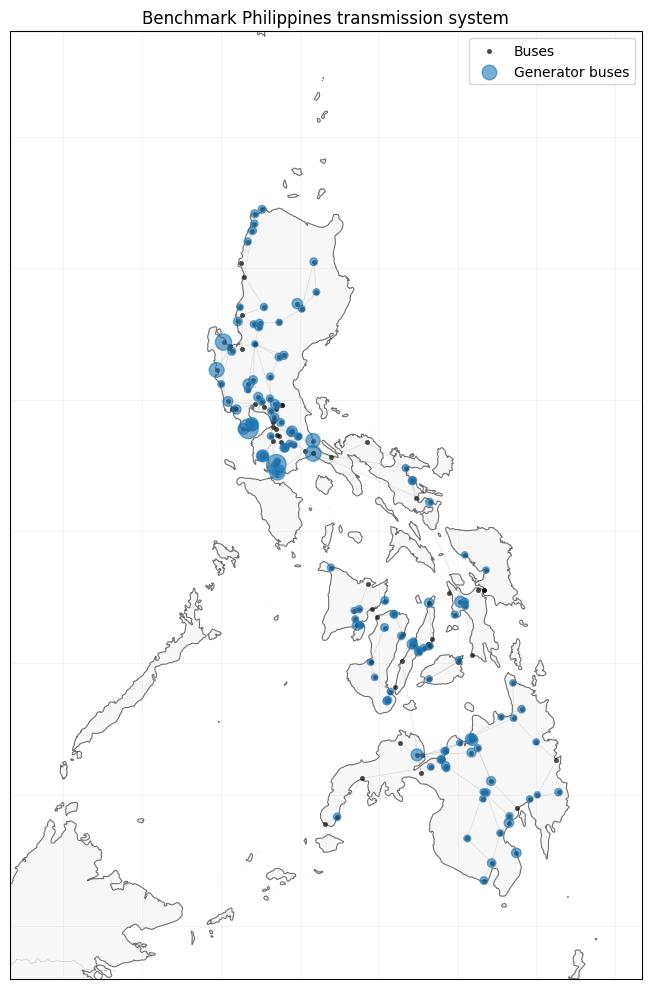

In [ ]:
# =========================
# Cell 13 — Baseline adequacy statistics and generator map
# =========================
# Compute the intact-system adequacy benchmark and visualize generator buses.

gen_bus_cap = build_generator_bus_capacity(generators=generators, capacity_col=GEN_CAPACITY_COL)

baseline_stats = compute_system_baseline_mw_per_person_proxy(
    G_base=G_base,
    buses=buses_nb,
    gen_bus_cap=gen_bus_cap,
    bus_pop_col="bus_pop_local_nb",
)

GLOBAL_MAX_WIND = ph_points["wind_kph"].max()
if pd.isna(GLOBAL_MAX_WIND) or GLOBAL_MAX_WIND <= 0:
    GLOBAL_MAX_WIND = 1.0

print("GLOBAL_MAX_WIND:", GLOBAL_MAX_WIND)
print("Baseline adequacy stats:", baseline_stats)

gen_bus_plot = buses_nb.merge(gen_bus_cap, on="bus_id", how="left")
gen_bus_plot["gen_capacity_mw"] = gen_bus_plot["gen_capacity_mw"].fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(ax, title="Benchmark Philippines transmission system")

plot_lines(ax, line_df, color="gray", alpha=0.20, linewidth=0.6, zorder=3)
plot_buses(ax, buses_nb, size=10, color="black", alpha=0.7, label="Buses", zorder=4)

gen_only = gen_bus_plot[gen_bus_plot["gen_capacity_mw"] > 0].copy()
if not gen_only.empty:
    size_scale = 20 + 180 * (gen_only["gen_capacity_mw"] / gen_only["gen_capacity_mw"].max())
    ax.scatter(
        gen_only["lon"],
        gen_only["lat"],
        s=size_scale,
        alpha=0.6,
        label="Generator buses",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

ax.legend()
plt.tight_layout()
plt.show()

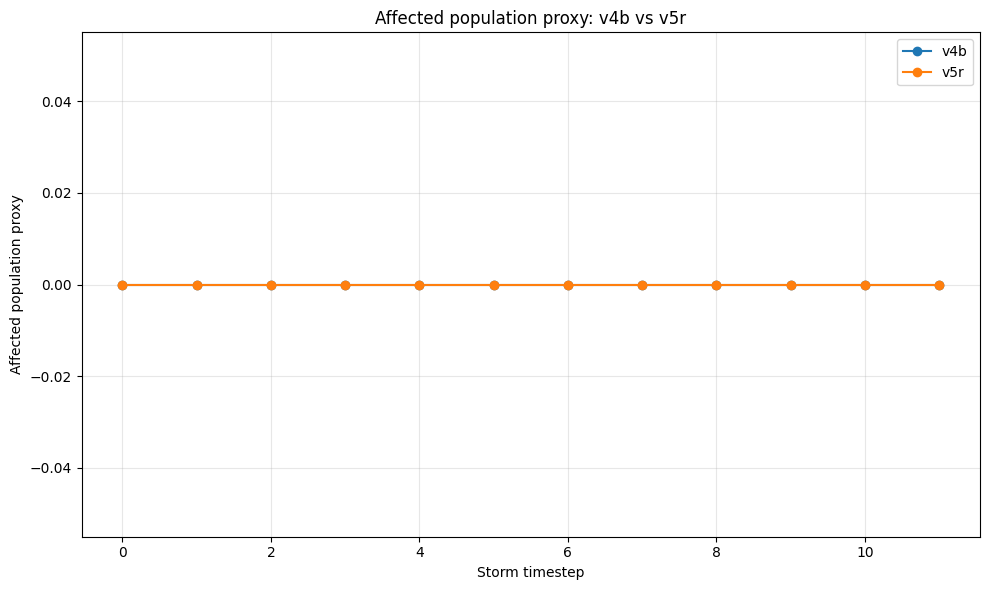

,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step
0,WP011946,BARBARA,1946,0,1,0,0.0,0,0.0,0.0,0.0,1,1,0,0.0
1,WP011946,BARBARA,1946,1,2,0,0.0,0,0.0,0.0,0.0,1,1,0,0.0
2,WP011946,BARBARA,1946,2,3,0,0.0,0,0.0,0.0,0.0,1,1,0,0.0
3,WP011946,BARBARA,1946,3,4,0,0.0,0,0.0,0.0,0.0,1,1,0,0.0
4,WP011946,BARBARA,1946,4,5,0,0.0,0,0.0,0.0,0.0,1,1,0,0.0


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step
7,WP011946,BARBARA,1946,7,8,0,0.0,0,0.0,0.0,0.0,1,1,0,0.407748
8,WP011946,BARBARA,1946,8,9,0,0.0,0,0.0,0.0,0.0,1,1,0,0.407748
9,WP011946,BARBARA,1946,9,10,0,0.0,0,0.0,0.0,0.0,1,1,0,0.407748
10,WP011946,BARBARA,1946,10,11,0,0.0,0,0.0,0.0,0.0,1,1,0,0.407748
11,WP011946,BARBARA,1946,11,12,0,0.0,0,0.0,0.0,0.0,1,1,0,0.407748


In [ ]:
# =========================
# Cell 14 — One-storm diagnostics: v4b benchmark vs v5r preferred
# =========================
# Run the first storm in the sample to compare the simpler service rule (v4b)
# against the preferred adequacy-aware service rule (v5r).

storm_id_demo = ph_points["storm_id"].iloc[0]
storm_year_demo = int(ph_points.loc[ph_points["storm_id"] == storm_id_demo, "year"].iloc[0])

gen_buses_demo = get_generator_buses_for_storm_year(
    generators=generators,
    graph_nodes=G_base.nodes(),
    storm_year=storm_year_demo,
    use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
    year_col=GENERATOR_YEAR_COLUMN,
)

ts_demo_v4b, steps_demo_v4b = simulate_grid_impact_timeseries_v4b(
    storm_id=storm_id_demo,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_buses=gen_buses_demo,
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
)

ts_demo_v5r, steps_demo_v5r = simulate_grid_impact_timeseries_v5r(
    storm_id=storm_id_demo,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_bus_cap=gen_bus_cap,
    baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
    min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
    min_total_gen_mw=MIN_TOTAL_GEN_MW,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_demo_v4b["t"], ts_demo_v4b["affected_population_proxy"], marker="o", label="v4b")
ax.plot(ts_demo_v5r["t"], ts_demo_v5r["affected_population_proxy"], marker="o", label="v5r")
ax.set_title("Affected population proxy: v4b vs v5r")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(ts_demo_v5r.head())
display(ts_demo_v5r.tail())

In [ ]:
# =========================
# Cell 15 — Run all storms and rank events
# =========================
# This is the main production cell.
# It runs:
# - deterministic v4b
# - deterministic v5r
# - one seeded stochastic v5r realization per storm

storm_summaries_v4b = []
storm_summaries_v5r = []
storm_summaries_v5r_stoch = []

storm_ts_store_v4b = {}
storm_ts_store_v5r = {}
storm_ts_store_v5r_stoch = {}

for storm_counter, (_, meta) in enumerate(storm_meta.iterrows()):
    storm_id = meta["storm_id"]
    storm_year = int(meta["year"])

    try:
        gen_buses_y = get_generator_buses_for_storm_year(
            generators=generators,
            graph_nodes=G_base.nodes(),
            storm_year=storm_year,
            use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
            year_col=GENERATOR_YEAR_COLUMN,
        )

        # --- Deterministic v4b ---
        ts_df_v4b, _ = simulate_grid_impact_timeseries_v4b(
            storm_id=storm_id,
            ph_points=ph_points,
            line_df=line_df,
            line_samples=line_samples,
            buses=buses_nb,
            G_base=G_base,
            gen_buses=gen_buses_y,
            search_radius_km=SEARCH_RADIUS_KM,
            global_max_wind_kph=GLOBAL_MAX_WIND,
            fail_threshold=FAIL_THRESHOLD,
            rmax_km_default=RMAX_KM_DEFAULT,
            rmax_scaling=RMAX_SCALING,
            inner_core_floor=INNER_CORE_FLOOR,
            outer_decay_power=OUTER_DECAY_POWER,
            min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
            bus_pop_col="bus_pop_local_nb",
        )
        storm_ts_store_v4b[storm_id] = ts_df_v4b.copy()
        storm_summaries_v4b.append(summarize_storm_timeseries(ts_df_v4b))

        # --- Deterministic v5r ---
        ts_df_v5r, _ = simulate_grid_impact_timeseries_v5r(
            storm_id=storm_id,
            ph_points=ph_points,
            line_df=line_df,
            line_samples=line_samples,
            buses=buses_nb,
            G_base=G_base,
            gen_bus_cap=gen_bus_cap,
            baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
            search_radius_km=SEARCH_RADIUS_KM,
            global_max_wind_kph=GLOBAL_MAX_WIND,
            fail_threshold=FAIL_THRESHOLD,
            rmax_km_default=RMAX_KM_DEFAULT,
            rmax_scaling=RMAX_SCALING,
            inner_core_floor=INNER_CORE_FLOOR,
            outer_decay_power=OUTER_DECAY_POWER,
            min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
            bus_pop_col="bus_pop_local_nb",
            min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
            min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
            min_total_gen_mw=MIN_TOTAL_GEN_MW,
        )
        storm_ts_store_v5r[storm_id] = ts_df_v5r.copy()
        storm_summaries_v5r.append(summarize_storm_timeseries(ts_df_v5r))

        # --- Stochastic v5r (one reproducible draw per storm) ---
        rng_storm = np.random.default_rng(10000 + storm_counter)

        ts_df_v5r_stoch, _ = simulate_grid_impact_timeseries_v5r_stochastic(
            storm_id=storm_id,
            ph_points=ph_points,
            line_df=line_df,
            line_samples=line_samples,
            buses=buses_nb,
            G_base=G_base,
            gen_bus_cap=gen_bus_cap,
            baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
            search_radius_km=SEARCH_RADIUS_KM,
            global_max_wind_kph=GLOBAL_MAX_WIND,
            fragility_h0=FAIL_THRESHOLD,
            fragility_k=18.0,
            rmax_km_default=RMAX_KM_DEFAULT,
            rmax_scaling=RMAX_SCALING,
            inner_core_floor=INNER_CORE_FLOOR,
            outer_decay_power=OUTER_DECAY_POWER,
            min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
            bus_pop_col="bus_pop_local_nb",
            min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
            min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
            min_total_gen_mw=MIN_TOTAL_GEN_MW,
            rng=rng_storm,
        )
        storm_ts_store_v5r_stoch[storm_id] = ts_df_v5r_stoch.copy()
        storm_summaries_v5r_stoch.append(summarize_storm_timeseries(ts_df_v5r_stoch))

    except Exception as exc:
        print(f"Skipping {storm_id}: {exc}")

rank_df_v4b = pd.DataFrame(storm_summaries_v4b)
rank_df_v5r = pd.DataFrame(storm_summaries_v5r)
rank_df_v5r_stoch = pd.DataFrame(storm_summaries_v5r_stoch)

# Build composite screening scores
for df, metric_name in [
    (rank_df_v4b, "grid_impact_index_v4b"),
    (rank_df_v5r, "grid_impact_index_v5r"),
    (rank_df_v5r_stoch, "grid_impact_index_v5r_stoch"),
]:
    if df.empty:
        continue

    df["peak_affected_population_proxy_norm"] = minmax_normalize(df["peak_affected_population_proxy"])
    df["peak_n_failed_lines_norm"] = minmax_normalize(df["peak_n_failed_lines_cumulative"])
    df["peak_n_unserved_buses_norm"] = minmax_normalize(df["peak_n_unserved_buses"])

    # Screening index weights:
    # population is primary, but line failure and unserved buses still matter
    df[metric_name] = (
        0.60 * df["peak_affected_population_proxy_norm"]
        + 0.25 * df["peak_n_failed_lines_norm"]
        + 0.15 * df["peak_n_unserved_buses_norm"]
    )

    df.sort_values(metric_name, ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)
    df["rank_index"] = df.index + 1

print("Completed storms:")
print("v4b:", len(rank_df_v4b))
print("v5r deterministic:", len(rank_df_v5r))
print("v5r stochastic:", len(rank_df_v5r_stoch))

display(
    rank_df_v5r[
        [
            "rank_index",
            "storm_id",
            "storm_name",
            "year",
            "grid_impact_index_v5r",
            "peak_affected_population_proxy",
            "peak_n_failed_lines_cumulative",
            "peak_n_unserved_buses",
            "peak_t",
        ]
    ].head(25)
)

display(
    rank_df_v5r_stoch[
        [
            "rank_index",
            "storm_id",
            "storm_name",
            "year",
            "grid_impact_index_v5r_stoch",
            "peak_affected_population_proxy",
            "peak_n_failed_lines_cumulative",
            "peak_n_unserved_buses",
            "peak_t",
        ]
    ].head(25)
)

KeyboardInterrupt: 

,storm_id,storm_name,year,grid_impact_index_v4b,grid_impact_index_v5r,rank_v4b,rank_v5r,rank_shift,abs_rank_shift
17,WP302019,PHANFONE,2019,0.006098,0.170124,18.0,10.0,8.0,8.0
18,WP072008,FENGSHEN,2008,0.006098,0.170124,18.0,10.0,8.0,8.0
7,WP252020,VAMCO,2020,0.101783,0.061566,8.0,15.0,-7.0,7.0
13,WP262018,MANGKHUT,2018,0.030488,0.030488,12.0,18.0,-6.0,6.0
8,WP242006,DURIAN,2006,0.079268,0.400801,9.0,4.0,5.0,5.0
10,WP222006,CIMARON,2006,0.042683,0.276032,11.0,7.0,4.0,4.0
11,WP112013,UTOR,2013,0.030488,0.059905,12.0,16.0,-4.0,4.0
14,WP242015,KOPPU,2015,0.018293,0.018293,15.0,19.0,-4.0,4.0
5,WP292019,KAMMURI,2019,0.271033,0.209147,6.0,9.0,-3.0,3.0
15,WP152010,MEGI,2010,0.018293,0.151783,15.0,12.0,3.0,3.0


,storm_id,storm_name,year,grid_impact_index_v5r,grid_impact_index_v5r_stoch,rank_v5r_det,rank_v5r_stoch,rank_shift,abs_rank_shift
19,WP202016,MEGI,2016,0.0,0.0,20.0,85.0,-65.0,65.0
20,WP182016,MALAKAS,2016,0.0,0.0,20.0,85.0,-65.0,65.0
21,WP162016,MERANTI,2016,0.0,0.0,20.0,85.0,-65.0,65.0
22,WP152016,NAMTHEUN,2016,0.0,0.0,20.0,85.0,-65.0,65.0
24,WP022016,NEPARTAK,2016,0.0,0.0,20.0,85.0,-65.0,65.0
26,WP222015,MUJIGAE,2015,0.0,0.0,20.0,85.0,-65.0,65.0
27,WP162015,GONI,2015,0.0,0.0,20.0,85.0,-65.0,65.0
28,WP122015,UNNAMED,2015,0.0,0.0,20.0,85.0,-65.0,65.0
29,WP062016,NIDA,2016,0.0,0.0,20.0,85.0,-65.0,65.0
30,WP212017,DOKSURI,2017,0.0,0.0,20.0,85.0,-65.0,65.0


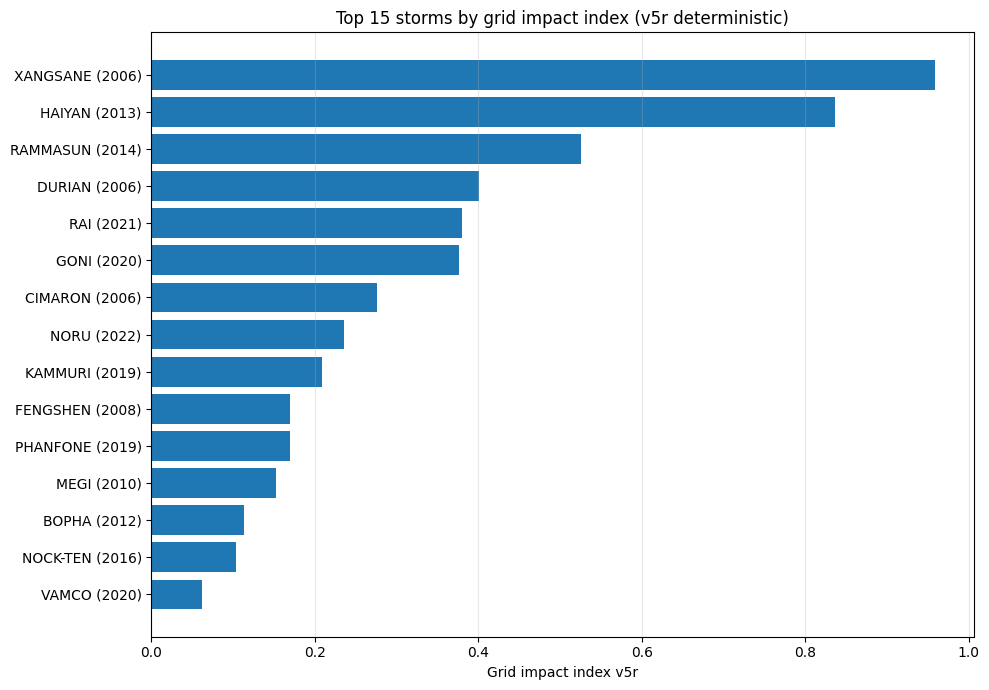

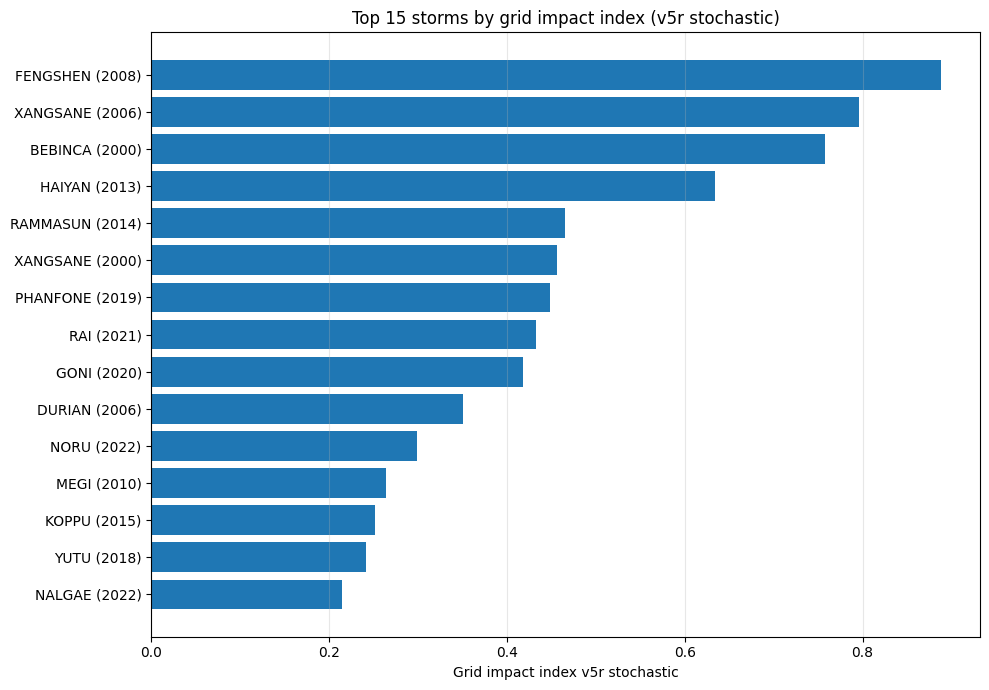

In [ ]:
# =========================
# Cell 16 — Rank comparisons
# =========================
# Compare how rankings shift:
# - from v4b to v5r
# - from deterministic v5r to stochastic v5r

compare_v4b_v5r = rank_df_v4b[
    ["storm_id", "storm_name", "year", "grid_impact_index_v4b"]
].merge(
    rank_df_v5r[["storm_id", "grid_impact_index_v5r"]],
    on="storm_id",
    how="inner",
)

compare_v4b_v5r["rank_v4b"] = compare_v4b_v5r["grid_impact_index_v4b"].rank(
    ascending=False,
    method="min",
)
compare_v4b_v5r["rank_v5r"] = compare_v4b_v5r["grid_impact_index_v5r"].rank(
    ascending=False,
    method="min",
)
compare_v4b_v5r["rank_shift"] = compare_v4b_v5r["rank_v4b"] - compare_v4b_v5r["rank_v5r"]
compare_v4b_v5r["abs_rank_shift"] = compare_v4b_v5r["rank_shift"].abs()

display(
    compare_v4b_v5r.sort_values(
        ["abs_rank_shift", "rank_v5r"],
        ascending=[False, True],
    ).head(30)
)

compare_det_stoch = rank_df_v5r[
    ["storm_id", "storm_name", "year", "grid_impact_index_v5r"]
].merge(
    rank_df_v5r_stoch[["storm_id", "grid_impact_index_v5r_stoch"]],
    on="storm_id",
    how="inner",
)

compare_det_stoch["rank_v5r_det"] = compare_det_stoch["grid_impact_index_v5r"].rank(
    ascending=False,
    method="min",
)
compare_det_stoch["rank_v5r_stoch"] = compare_det_stoch["grid_impact_index_v5r_stoch"].rank(
    ascending=False,
    method="min",
)
compare_det_stoch["rank_shift"] = (
    compare_det_stoch["rank_v5r_det"] - compare_det_stoch["rank_v5r_stoch"]
)
compare_det_stoch["abs_rank_shift"] = compare_det_stoch["rank_shift"].abs()

display(
    compare_det_stoch.sort_values(
        ["abs_rank_shift", "rank_v5r_stoch"],
        ascending=[False, True],
    ).head(30)
)

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = rank_df_v5r.head(15).sort_values("grid_impact_index_v5r")
labels = plot_df["storm_name"] + " (" + plot_df["year"].astype(int).astype(str) + ")"
ax.barh(labels, plot_df["grid_impact_index_v5r"])
ax.set_title("Top 15 storms by grid impact index (v5r deterministic)")
ax.set_xlabel("Grid impact index v5r")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = rank_df_v5r_stoch.head(15).sort_values("grid_impact_index_v5r_stoch")
labels = plot_df["storm_name"] + " (" + plot_df["year"].astype(int).astype(str) + ")"
ax.barh(labels, plot_df["grid_impact_index_v5r_stoch"])
ax.set_title("Top 15 storms by grid impact index (v5r stochastic)")
ax.set_xlabel("Grid impact index v5r stochastic")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

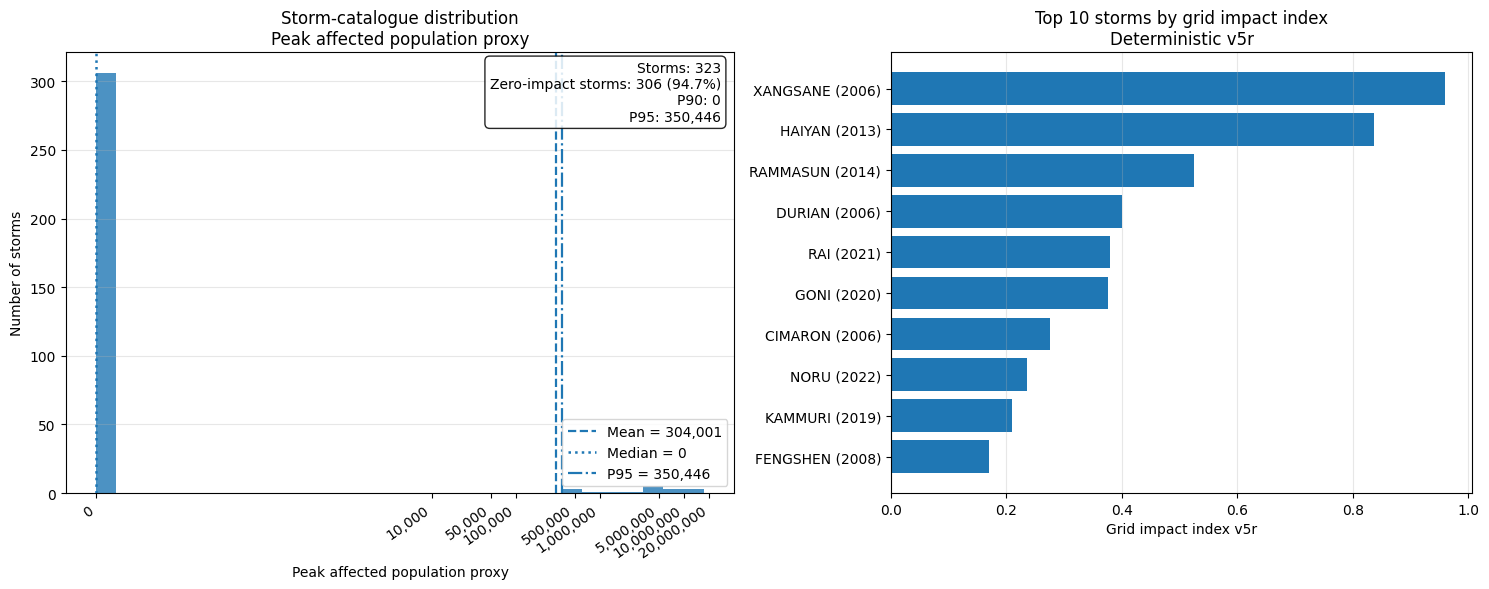

In [ ]:
# =========================
# New Cell — Prettier catalogue-wide impact view
# =========================
# Two-panel figure:
# 1) distribution of peak affected population proxy across all storms
# 2) top-10 storms by deterministic v5r grid impact index

if "rank_df_v5r" not in globals() or rank_df_v5r.empty:
    raise ValueError("rank_df_v5r is missing or empty. Run the all-storm ranking cell first.")

plot_col = "peak_affected_population_proxy"
score_col = "grid_impact_index_v5r"
top_n = 10

plot_df = rank_df_v5r.copy()
plot_df = plot_df[np.isfinite(plot_df[plot_col])].copy()

if plot_df.empty:
    raise ValueError(f"No finite values found in {plot_col}.")

# log1p transform for readable distribution with many zeros / heavy tail
plot_df["plot_log1p"] = np.log1p(plot_df[plot_col])

mean_val = plot_df[plot_col].mean()
median_val = plot_df[plot_col].median()
p90_val = np.percentile(plot_df[plot_col], 90)
p95_val = np.percentile(plot_df[plot_col], 95)

mean_log = np.log1p(mean_val)
median_log = np.log1p(median_val)
p90_log = np.log1p(p90_val)
p95_log = np.log1p(p95_val)

top_df = (
    plot_df.nlargest(top_n, score_col)
    .sort_values(score_col, ascending=True)
    .copy()
)

top_df["label"] = top_df["storm_name"] + " (" + top_df["year"].astype(int).astype(str) + ")"

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1.15, 1]}
)

# -------------------------
# Left panel: catalogue distribution
# -------------------------
ax1.hist(plot_df["plot_log1p"], bins=30, alpha=0.8)

ax1.axvline(mean_log, linestyle="--", linewidth=1.6, label=f"Mean = {mean_val:,.0f}")
ax1.axvline(median_log, linestyle=":", linewidth=1.8, label=f"Median = {median_val:,.0f}")
ax1.axvline(p95_log, linestyle="-.", linewidth=1.6, label=f"P95 = {p95_val:,.0f}")

# readable tick labels back-transformed to original scale
tick_vals = np.array([0, 1e4, 5e4, 1e5, 5e5, 1e6, 5e6, 1e7, 2e7], dtype=float)
tick_pos = np.log1p(tick_vals)
tick_mask = tick_pos <= plot_df["plot_log1p"].max() + 0.2

ax1.set_xticks(tick_pos[tick_mask])
ax1.set_xticklabels([f"{int(v):,}" for v in tick_vals[tick_mask]], rotation=35, ha="right")

ax1.set_title("Storm-catalogue distribution\nPeak affected population proxy")
ax1.set_xlabel("Peak affected population proxy")
ax1.set_ylabel("Number of storms")
ax1.grid(True, axis="y", alpha=0.3)
ax1.legend()

# small annotation box
n_zero = int((plot_df[plot_col] == 0).sum())
share_zero = n_zero / len(plot_df)

txt = (
    f"Storms: {len(plot_df)}\n"
    f"Zero-impact storms: {n_zero} ({share_zero:.1%})\n"
    f"P90: {p90_val:,.0f}\n"
    f"P95: {p95_val:,.0f}"
)
ax1.text(
    0.98, 0.98, txt,
    transform=ax1.transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85)
)

# -------------------------
# Right panel: top storms
# -------------------------
ax2.barh(top_df["label"], top_df[score_col])
ax2.set_title(f"Top {top_n} storms by grid impact index\nDeterministic v5r")
ax2.set_xlabel("Grid impact index v5r")
ax2.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Running stochastic simulation for storm: WP012001


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_failed_lines_new,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step,mean_line_p_fail_this_step,max_line_p_fail_this_step
0,WP012001,UNNAMED,2001,0,1,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.013822,0.000050,0.000064
1,WP012001,UNNAMED,2001,1,2,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.033556,0.000052,0.000092
2,WP012001,UNNAMED,2001,2,3,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146453,0.000079,0.000700
3,WP012001,UNNAMED,2001,3,4,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000090,0.000704
4,WP012001,UNNAMED,2001,4,5,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000099,0.000704


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_failed_lines_new,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step,mean_line_p_fail_this_step,max_line_p_fail_this_step
13,WP012001,UNNAMED,2001,13,14,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000109,0.000704
14,WP012001,UNNAMED,2001,14,15,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000110,0.000704
15,WP012001,UNNAMED,2001,15,16,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000112,0.000704
16,WP012001,UNNAMED,2001,16,17,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000113,0.000704
17,WP012001,UNNAMED,2001,17,18,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000113,0.000704


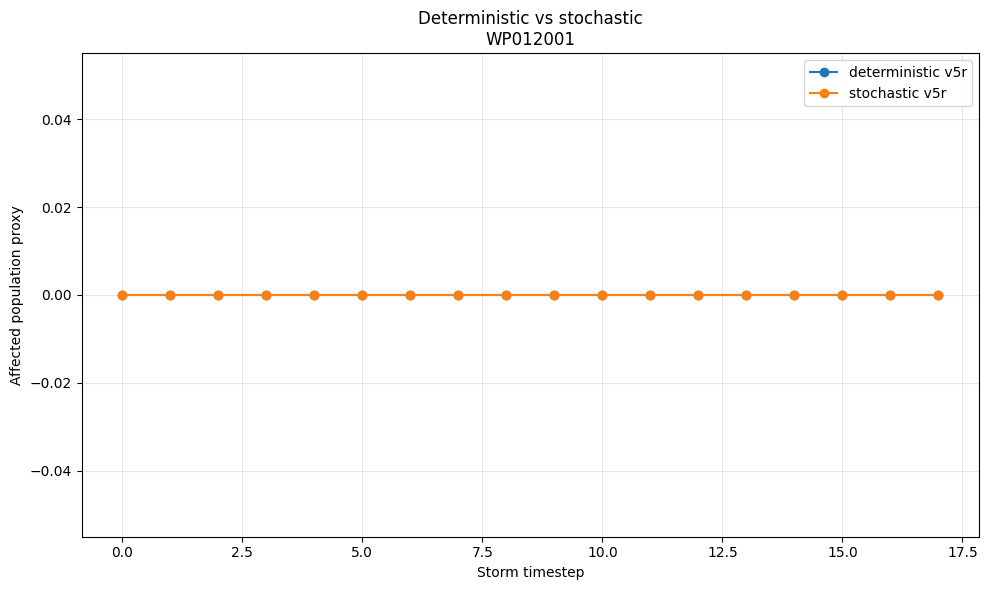

Running ensemble for storm: WP012001 (N=100)

--- Ensemble Results: Peak affected population proxy ---
Mean: 480,253
Std:  1,769,944
P10:  0
P50:  0
P90:  67,706


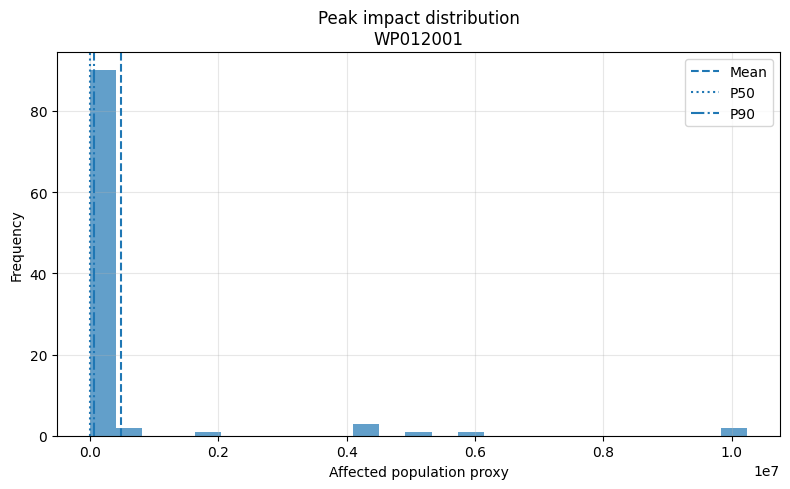

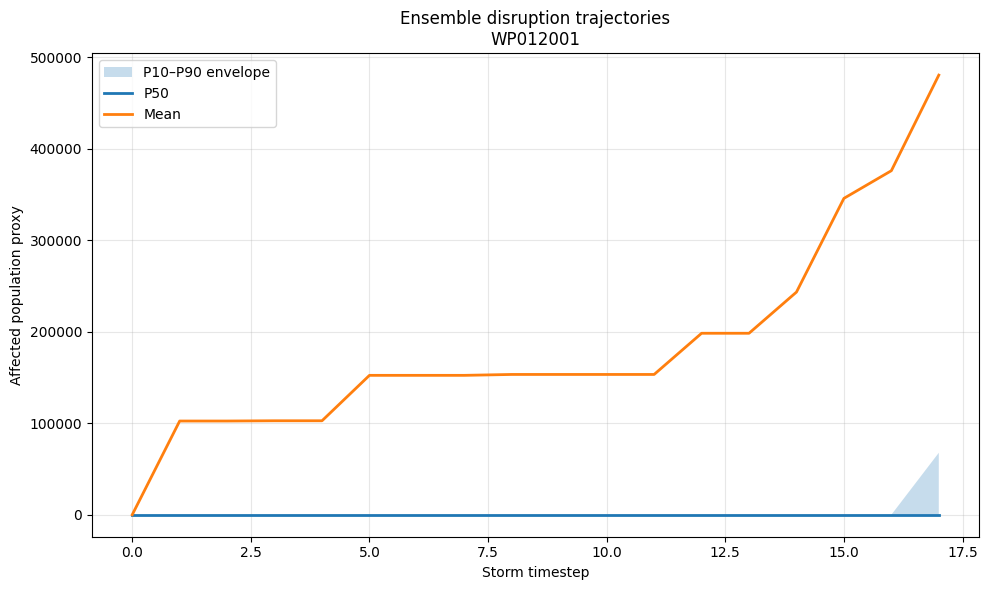

,storm_id,n_runs,mean_peak_affected_population_proxy,std_peak_affected_population_proxy,p10_peak_affected_population_proxy,p50_peak_affected_population_proxy,p90_peak_affected_population_proxy,deterministic_peak_affected_population_proxy,stochastic_demo_peak_affected_population_proxy
0,WP012001,100,480252.549282,1.769944e+06,0.0,0.0,67705.578582,0.0,0.0


In [ ]:
# =========================
# Cell 17 — One-storm stochastic demo + ensemble
# =========================
# This section is optional but useful for showing that the screening
# outcome can be framed probabilistically rather than as one hard path.

storm_id_demo = ph_points["storm_id"].iloc[0]
print("Running stochastic simulation for storm:", storm_id_demo)

# --- One reproducible stochastic run ---
rng_demo = np.random.default_rng(123)

ts_demo_stoch, steps_demo_stoch = simulate_grid_impact_timeseries_v5r_stochastic(
    storm_id=storm_id_demo,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_bus_cap=gen_bus_cap,
    baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fragility_h0=FAIL_THRESHOLD,
    fragility_k=18.0,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
    min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
    min_total_gen_mw=MIN_TOTAL_GEN_MW,
    rng=rng_demo,
)

display(ts_demo_stoch.head())
display(ts_demo_stoch.tail())

# Deterministic counterpart for direct comparison
ts_demo_det, _ = simulate_grid_impact_timeseries_v5r(
    storm_id=storm_id_demo,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_bus_cap=gen_bus_cap,
    baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
    min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
    min_total_gen_mw=MIN_TOTAL_GEN_MW,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    ts_demo_det["t"],
    ts_demo_det["affected_population_proxy"],
    marker="o",
    label="deterministic v5r",
)
ax.plot(
    ts_demo_stoch["t"],
    ts_demo_stoch["affected_population_proxy"],
    marker="o",
    label="stochastic v5r",
)
ax.set_title(f"Deterministic vs stochastic\n{storm_id_demo}")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# --- Ensemble experiment ---
N_RUNS = 100
print(f"Running ensemble for storm: {storm_id_demo} (N={N_RUNS})")

peak_impacts = []
final_impacts = []
all_runs_ts = []

for i in range(N_RUNS):
    rng_i = np.random.default_rng(1000 + i)

    ts_i, _ = simulate_grid_impact_timeseries_v5r_stochastic(
        storm_id=storm_id_demo,
        ph_points=ph_points,
        line_df=line_df,
        line_samples=line_samples,
        buses=buses_nb,
        G_base=G_base,
        gen_bus_cap=gen_bus_cap,
        baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
        search_radius_km=SEARCH_RADIUS_KM,
        global_max_wind_kph=GLOBAL_MAX_WIND,
        fragility_h0=FAIL_THRESHOLD,
        fragility_k=18.0,
        rmax_km_default=RMAX_KM_DEFAULT,
        rmax_scaling=RMAX_SCALING,
        inner_core_floor=INNER_CORE_FLOOR,
        outer_decay_power=OUTER_DECAY_POWER,
        min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
        bus_pop_col="bus_pop_local_nb",
        min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
        min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
        min_total_gen_mw=MIN_TOTAL_GEN_MW,
        rng=rng_i,
    )

    peak_impacts.append(ts_i["affected_population_proxy"].max())
    final_impacts.append(ts_i.iloc[-1]["affected_population_proxy"])
    all_runs_ts.append(ts_i.copy())

peak_impacts = np.array(peak_impacts, dtype=float)
final_impacts = np.array(final_impacts, dtype=float)

mean_peak = peak_impacts.mean()
std_peak = peak_impacts.std()
p10_peak = np.percentile(peak_impacts, 10)
p50_peak = np.percentile(peak_impacts, 50)
p90_peak = np.percentile(peak_impacts, 90)

print("\n--- Ensemble Results: Peak affected population proxy ---")
print(f"Mean: {mean_peak:,.0f}")
print(f"Std:  {std_peak:,.0f}")
print(f"P10:  {p10_peak:,.0f}")
print(f"P50:  {p50_peak:,.0f}")
print(f"P90:  {p90_peak:,.0f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(peak_impacts, bins=25, alpha=0.7)
ax.axvline(mean_peak, linestyle="--", label="Mean")
ax.axvline(p50_peak, linestyle=":", label="P50")
ax.axvline(p90_peak, linestyle="-.", label="P90")
ax.set_title(f"Peak impact distribution\n{storm_id_demo}")
ax.set_xlabel("Affected population proxy")
ax.set_ylabel("Frequency")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Collapse all trajectories into a percentile envelope
all_ts_concat = pd.concat(
    [
        ts.assign(run_id=i)[["run_id", "t", "affected_population_proxy"]]
        for i, ts in enumerate(all_runs_ts)
    ],
    ignore_index=True,
)

traj_summary = (
    all_ts_concat.groupby("t")["affected_population_proxy"]
    .agg(
        p10=lambda x: np.percentile(x, 10),
        p50=lambda x: np.percentile(x, 50),
        p90=lambda x: np.percentile(x, 90),
        mean="mean",
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(
    traj_summary["t"],
    traj_summary["p10"],
    traj_summary["p90"],
    alpha=0.25,
    label="P10–P90 envelope",
)
ax.plot(traj_summary["t"], traj_summary["p50"], linewidth=2, label="P50")
ax.plot(traj_summary["t"], traj_summary["mean"], linewidth=2, label="Mean")
ax.set_title(f"Ensemble disruption trajectories\n{storm_id_demo}")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

ensemble_summary_demo = pd.DataFrame(
    {
        "storm_id": [storm_id_demo],
        "n_runs": [N_RUNS],
        "mean_peak_affected_population_proxy": [mean_peak],
        "std_peak_affected_population_proxy": [std_peak],
        "p10_peak_affected_population_proxy": [p10_peak],
        "p50_peak_affected_population_proxy": [p50_peak],
        "p90_peak_affected_population_proxy": [p90_peak],
        "deterministic_peak_affected_population_proxy": [
            ts_demo_det["affected_population_proxy"].max()
        ],
        "stochastic_demo_peak_affected_population_proxy": [
            ts_demo_stoch["affected_population_proxy"].max()
        ],
    }
)

display(ensemble_summary_demo)

Top deterministic v5r storm: WP182006
Top stochastic v5r storm: WP072008


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_failed_lines_new,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step,mean_line_p_fail_this_step,max_line_p_fail_this_step
0,WP072008,FENGSHEN,2008,0,1,0,0.000000,0,0,0.000000,0.0,0.0,1,1,0,0.000000,0.000050,0.000050
1,WP072008,FENGSHEN,2008,1,2,0,0.000000,0,0,0.000000,0.0,0.0,1,1,0,0.050094,0.000052,0.000124
2,WP072008,FENGSHEN,2008,2,3,1,0.004237,1,1,0.005208,0.0,0.0,2,1,1,0.440243,0.002111,0.121786
3,WP072008,FENGSHEN,2008,3,4,1,0.004237,0,1,0.005208,0.0,0.0,2,1,1,0.470074,0.004294,0.191750
4,WP072008,FENGSHEN,2008,4,5,2,0.008475,1,1,0.005208,0.0,0.0,3,2,1,0.470074,0.004366,0.191750


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_failed_lines_new,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step,mean_line_p_fail_this_step,max_line_p_fail_this_step
12,WP072008,FENGSHEN,2008,12,13,21,0.088983,5,11,0.057292,2.000371e+07,0.129427,15,6,9,0.60956,0.026947,0.744991
13,WP072008,FENGSHEN,2008,13,14,22,0.093220,1,11,0.057292,2.000371e+07,0.129427,16,7,9,0.60956,0.026947,0.744991
14,WP072008,FENGSHEN,2008,14,15,23,0.097458,1,11,0.057292,2.000371e+07,0.129427,16,7,9,0.60956,0.026947,0.744991
15,WP072008,FENGSHEN,2008,15,16,24,0.101695,1,11,0.057292,2.000371e+07,0.129427,17,8,9,0.60956,0.026947,0.744991
16,WP072008,FENGSHEN,2008,16,17,26,0.110169,2,12,0.062500,2.083117e+07,0.134781,18,8,10,0.60956,0.026947,0.744991


Saved animation to: /home/krawalker/coding/KRITIS-PH/outputs/storm_animation_top_stochastic_WP072008.gif
Saved animation: /home/krawalker/coding/KRITIS-PH/outputs/storm_animation_top_stochastic_WP072008.gif


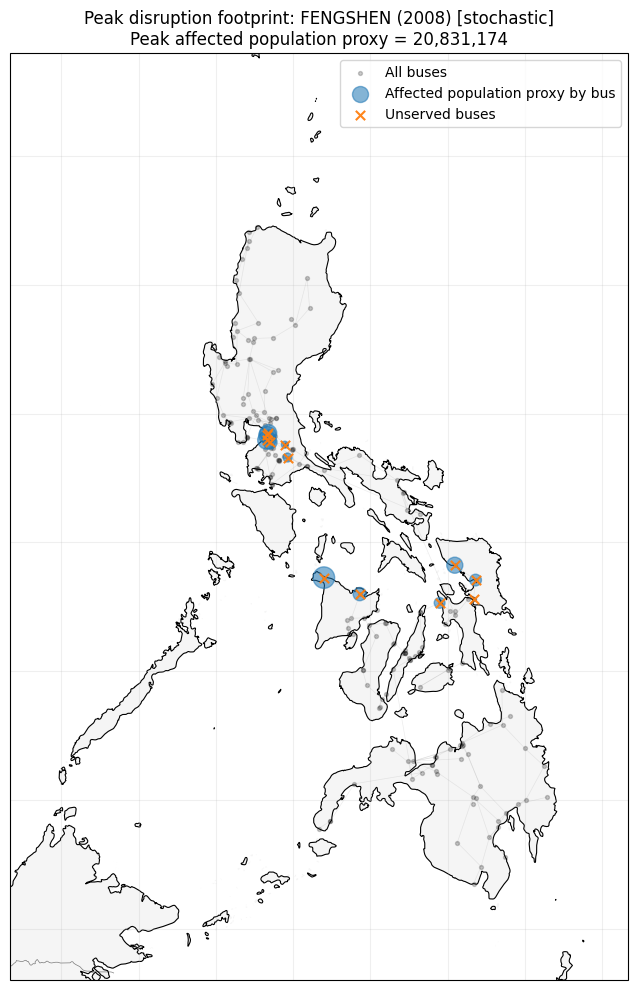

,bus_id,unserved,bus_pop_local_nb,affected_population_proxy,n_affected_cells
145,08NABAS,True,4.499376e+06,4.499376e+06,16916
60,02ZAPOTE,True,3.117837e+06,3.117837e+06,193
57,02MANILA,True,2.783354e+06,2.783354e+06,110
56,02DONAIMELDA,True,2.621333e+06,2.621333e+06,88
97,04CALBAYOG,True,2.327941e+06,2.327941e+06,7898
58,02MUNTINLUPA,True,1.605273e+06,1.605273e+06,102
146,08PANITAN,True,1.443907e+06,1.443907e+06,3400
102,04PARANAS,True,1.056476e+06,1.056476e+06,6060
105,04TABANGO,True,8.274684e+05,8.274684e+05,1666
86,03PALAYAN,True,4.393862e+05,4.393862e+05,557


,component_id,bus_ids,n_buses,n_generator_buses,population_proxy,gen_capacity_mw,mw_per_person_proxy,relative_adequacy,required_relative_ratio,served_component
0,6,"[02DONAIMELDA, 02MANILA]",2,0,5.404687e+06,0.0,0.000000,0.000000,0.35,False
1,17,[08NABAS],1,1,4.499376e+06,74.1,0.000016,0.094225,0.75,False
2,13,"[04PARANAS, 04CALBAYOG]",2,2,3.384418e+06,26.2,0.000008,0.044291,0.35,False
3,8,[02ZAPOTE],1,0,3.117837e+06,0.0,0.000000,0.000000,0.75,False
4,7,[02MUNTINLUPA],1,0,1.605273e+06,0.0,0.000000,0.000000,0.75,False
5,18,[08PANITAN],1,0,1.443907e+06,0.0,0.000000,0.000000,0.75,False
6,15,[04TABANGO],1,0,8.274684e+05,0.0,0.000000,0.000000,0.75,False
7,12,[03PALAYAN],1,1,4.393862e+05,31.0,0.000071,0.403661,0.75,False
8,4,[01BPC],1,0,1.088207e+05,0.0,0.000000,0.000000,0.75,False
9,14,[04STARITA],1,0,0.000000e+00,0.0,NaN,NaN,0.75,False


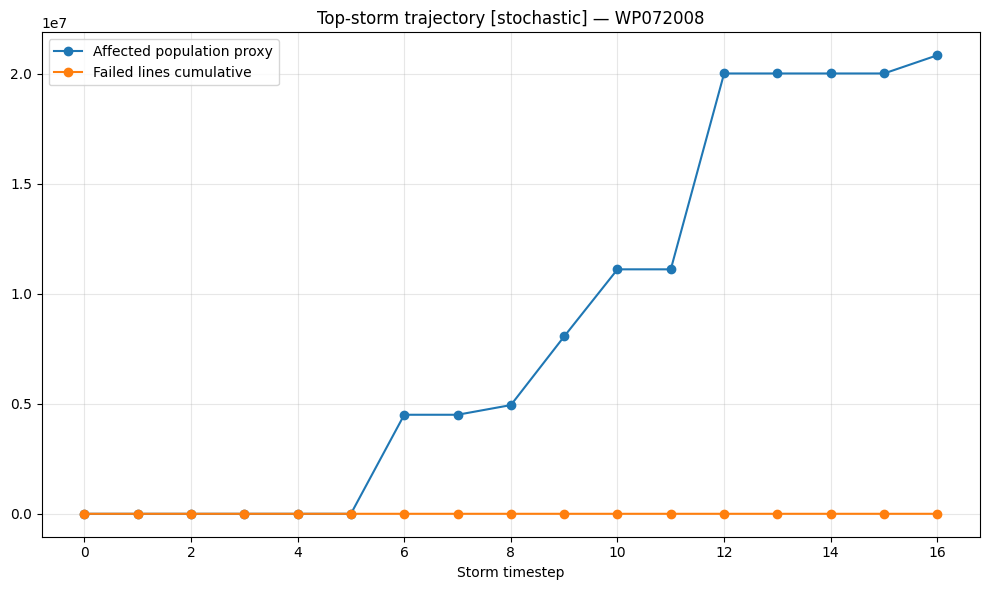

In [ ]:
# =========================
# Cell 18 — Top-event dynamic animation and peak footprint
# =========================
# Animate either the top deterministic event or the top stochastic event.

top_storm_id_v5r = rank_df_v5r.iloc[0]["storm_id"]
top_storm_id_v5r_stoch = rank_df_v5r_stoch.iloc[0]["storm_id"]

print("Top deterministic v5r storm:", top_storm_id_v5r)
print("Top stochastic v5r storm:", top_storm_id_v5r_stoch)

USE_STOCHASTIC_TOP_STORM = True

if USE_STOCHASTIC_TOP_STORM:
    selected_top_storm_id = top_storm_id_v5r_stoch
    selected_label = "stochastic"
    rng_top = np.random.default_rng(2026)

    ts_top, steps_top = simulate_grid_impact_timeseries_v5r_stochastic(
        storm_id=selected_top_storm_id,
        ph_points=ph_points,
        line_df=line_df,
        line_samples=line_samples,
        buses=buses_nb,
        G_base=G_base,
        gen_bus_cap=gen_bus_cap,
        baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
        search_radius_km=SEARCH_RADIUS_KM,
        global_max_wind_kph=GLOBAL_MAX_WIND,
        fragility_h0=FAIL_THRESHOLD,
        fragility_k=18.0,
        rmax_km_default=RMAX_KM_DEFAULT,
        rmax_scaling=RMAX_SCALING,
        inner_core_floor=INNER_CORE_FLOOR,
        outer_decay_power=OUTER_DECAY_POWER,
        min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
        bus_pop_col="bus_pop_local_nb",
        min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
        min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
        min_total_gen_mw=MIN_TOTAL_GEN_MW,
        rng=rng_top,
    )
else:
    selected_top_storm_id = top_storm_id_v5r
    selected_label = "deterministic"

    ts_top, steps_top = simulate_grid_impact_timeseries_v5r(
        storm_id=selected_top_storm_id,
        ph_points=ph_points,
        line_df=line_df,
        line_samples=line_samples,
        buses=buses_nb,
        G_base=G_base,
        gen_bus_cap=gen_bus_cap,
        baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
        search_radius_km=SEARCH_RADIUS_KM,
        global_max_wind_kph=GLOBAL_MAX_WIND,
        fail_threshold=FAIL_THRESHOLD,
        rmax_km_default=RMAX_KM_DEFAULT,
        rmax_scaling=RMAX_SCALING,
        inner_core_floor=INNER_CORE_FLOOR,
        outer_decay_power=OUTER_DECAY_POWER,
        min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
        bus_pop_col="bus_pop_local_nb",
        min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
        min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
        min_total_gen_mw=MIN_TOTAL_GEN_MW,
    )

display(ts_top.head())
display(ts_top.tail())

top_gif_busimpact_canonical = OUTPUT_DIR / (
    f"storm_animation_top_{selected_label}_{selected_top_storm_id}.gif"
)

anim_top_busimpact_canonical = animate_storm_bus_impact_canonical(
    step_outputs=steps_top,
    pop_assignment=pop_assignment,
    H_pop_log=H_pop_log,
    xedges_pop=xedges_pop,
    yedges_pop=yedges_pop,
    out_gif_path=top_gif_busimpact_canonical,
    interval=700,
    show_search_radius=True,
    search_radius_km=SEARCH_RADIUS_KM,
)

print("Saved animation:", top_gif_busimpact_canonical.resolve())
HTML(anim_top_busimpact_canonical.to_jshtml())

# --- Peak-step footprint extraction ---
peak_idx = ts_top["affected_population_proxy"].idxmax()
peak_t = int(ts_top.loc[peak_idx, "t"])
peak_step = next(s for s in steps_top if s["t"] == peak_t)

peak_bus_service = peak_step["bus_state"][["bus_id", "served", "unserved"]].copy()

pop_impact_peak = pop_assignment.merge(
    peak_bus_service,
    left_on="nearest_bus_id",
    right_on="bus_id",
    how="left",
)
pop_impact_peak["unserved"] = pop_impact_peak["unserved"].fillna(False)

affected_cells = pop_impact_peak.loc[pop_impact_peak["unserved"]].copy()
affected_pop_peak = float(affected_cells["pop_value"].sum())

affected_by_bus_peak = (
    affected_cells.groupby("nearest_bus_id", as_index=False)
    .agg(
        affected_population_proxy=("pop_value", "sum"),
        n_affected_cells=("pop_value", "size"),
    )
    .rename(columns={"nearest_bus_id": "bus_id"})
)

bus_impact_peak = buses_nb.merge(affected_by_bus_peak, on="bus_id", how="left")
bus_impact_peak["affected_population_proxy"] = bus_impact_peak["affected_population_proxy"].fillna(0.0)
bus_impact_peak["n_affected_cells"] = bus_impact_peak["n_affected_cells"].fillna(0).astype(int)

bus_impact_peak = bus_impact_peak.merge(peak_bus_service, on="bus_id", how="left")
bus_impact_peak["served"] = bus_impact_peak["served"].fillna(False)
bus_impact_peak["unserved"] = bus_impact_peak["unserved"].fillna(False)

# --- Footprint map ---
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(
    ax,
    title=(
        f"Peak disruption footprint: {peak_step['record']['storm_name']} "
        f"({peak_step['record']['year']}) [{selected_label}]\n"
        f"Peak affected population proxy = {affected_pop_peak:,.0f}"
    ),
)

plot_lines(ax, line_df, color="gray", alpha=0.15, linewidth=0.5, zorder=2)
plot_buses(ax, buses_nb, size=8, color="black", alpha=0.20, label="All buses", zorder=3)

impact_plot = bus_impact_peak[bus_impact_peak["affected_population_proxy"] > 0].copy()
if not impact_plot.empty:
    size_scale = 20 + 220 * (
        impact_plot["affected_population_proxy"] / impact_plot["affected_population_proxy"].max()
    )
    ax.scatter(
        impact_plot["lon"],
        impact_plot["lat"],
        s=size_scale,
        alpha=0.55,
        label="Affected population proxy by bus",
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

unserved_plot = bus_impact_peak[bus_impact_peak["unserved"]].copy()
if not unserved_plot.empty:
    ax.scatter(
        unserved_plot["lon"],
        unserved_plot["lat"],
        s=45,
        marker="x",
        alpha=0.95,
        label="Unserved buses",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

ax.legend()
plt.tight_layout()
plt.show()

display(
    bus_impact_peak[
        [
            "bus_id",
            "unserved",
            "bus_pop_local_nb",
            "affected_population_proxy",
            "n_affected_cells",
        ]
    ]
    .sort_values("affected_population_proxy", ascending=False)
    .head(25)
)

if "component_table" in peak_step:
    display(
        peak_step["component_table"]
        .sort_values(["served_component", "population_proxy"], ascending=[True, False])
        .reset_index(drop=True)
        .head(25)
    )

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_top["t"], ts_top["affected_population_proxy"], marker="o", label="Affected population proxy")
ax.plot(ts_top["t"], ts_top["n_failed_lines_cumulative"], marker="o", label="Failed lines cumulative")
ax.set_title(f"Top-storm trajectory [{selected_label}] — {selected_top_storm_id}")
ax.set_xlabel("Storm timestep")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Hotspot storms processed: 323
Mode: stochastic


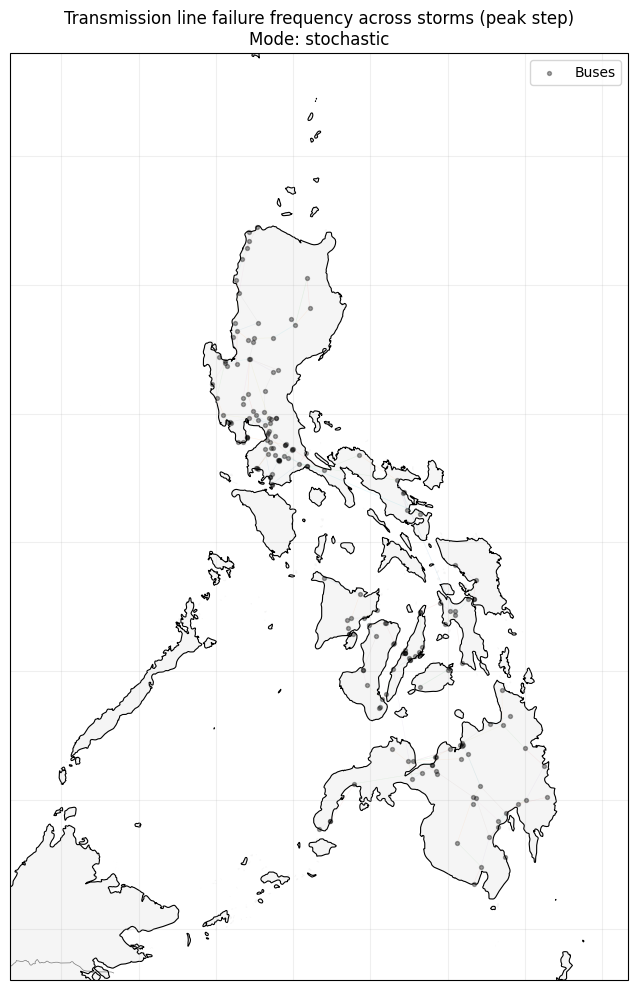

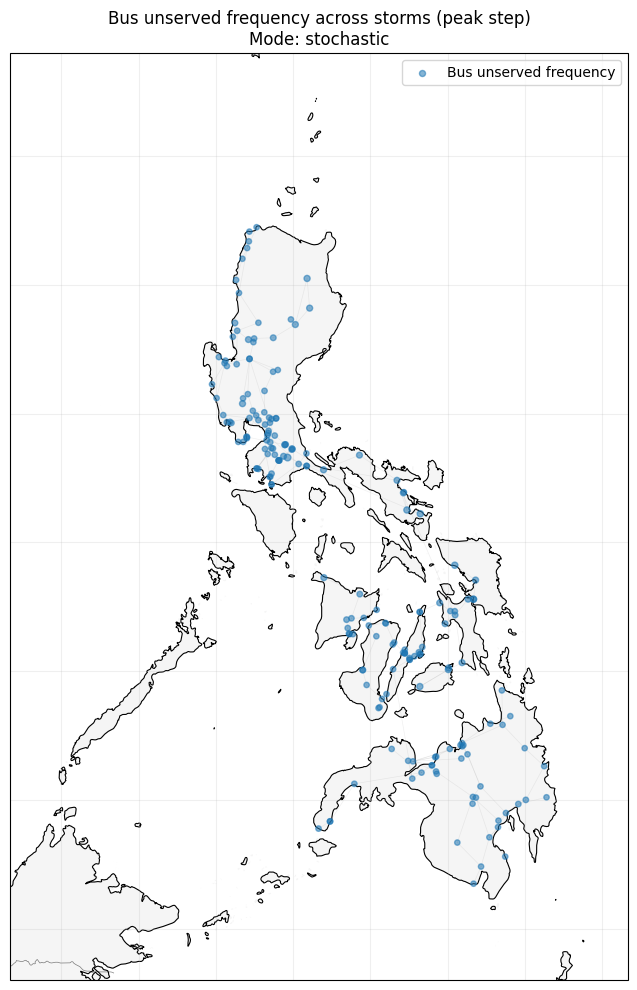

,line_id,bus0,bus1,failure_frequency
99,99,03BACMANGP,03PALAYAN,0.034056
100,100,03NAGA,04ORMOC,0.030960
97,97,03TIWI-C,03DARAGA,0.024768
22,22,01SNTGO,01TGEGARAO,0.021672
94,94,03NAGA,03DARAGA,0.021672
19,19,01BYOMBNG,01SNTGO,0.021672
98,98,03DARAGA,03BACMANGP,0.018576
101,101,03NAGA,03LABO,0.018576
11,11,01BAUANG,01LATRINI,0.018576
95,95,03NAGA,03TIWI-C,0.018576


,bus_id,bus_pop_local_nb,unserved_frequency
86,03PALAYAN,4.393862e+05,0.034056
63,03BACMANGP,1.790441e+06,0.021672
70,03DARAGA,2.358922e+06,0.021672
97,04CALBAYOG,2.327941e+06,0.021672
103,04STARITA,0.000000e+00,0.018576
13,01BPC,1.088207e+05,0.018576
54,01TGEGARAO,2.117532e+06,0.018576
136,07CORELLA,1.231223e+06,0.018576
102,04PARANAS,1.056476e+06,0.015480
95,03TIWI-C,1.169394e+06,0.015480


In [ ]:
# =========================
# Cell 19 — Ensemble hotspot statistics
# =========================
# Across storms, calculate how often:
# - each line is failed at the storm peak step
# - each bus is unserved at the storm peak step

USE_STOCHASTIC_HOTSPOTS = True
MAX_HOTSPOT_STORMS = None  # set e.g. to 30 for faster tests

line_fail_records = []
bus_unserved_records = []

storm_iter = storm_meta.copy()
if MAX_HOTSPOT_STORMS is not None:
    storm_iter = storm_iter.head(MAX_HOTSPOT_STORMS).copy()

for storm_counter, (_, meta) in enumerate(storm_iter.iterrows()):
    storm_id = meta["storm_id"]

    try:
        if USE_STOCHASTIC_HOTSPOTS:
            rng_hot = np.random.default_rng(50000 + storm_counter)

            ts_df_use, step_outputs = simulate_grid_impact_timeseries_v5r_stochastic(
                storm_id=storm_id,
                ph_points=ph_points,
                line_df=line_df,
                line_samples=line_samples,
                buses=buses_nb,
                G_base=G_base,
                gen_bus_cap=gen_bus_cap,
                baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
                search_radius_km=SEARCH_RADIUS_KM,
                global_max_wind_kph=GLOBAL_MAX_WIND,
                fragility_h0=FAIL_THRESHOLD,
                fragility_k=18.0,
                rmax_km_default=RMAX_KM_DEFAULT,
                rmax_scaling=RMAX_SCALING,
                inner_core_floor=INNER_CORE_FLOOR,
                outer_decay_power=OUTER_DECAY_POWER,
                min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
                bus_pop_col="bus_pop_local_nb",
                min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
                min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
                min_total_gen_mw=MIN_TOTAL_GEN_MW,
                rng=rng_hot,
            )
        else:
            ts_df_use, step_outputs = simulate_grid_impact_timeseries_v5r(
                storm_id=storm_id,
                ph_points=ph_points,
                line_df=line_df,
                line_samples=line_samples,
                buses=buses_nb,
                G_base=G_base,
                gen_bus_cap=gen_bus_cap,
                baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
                search_radius_km=SEARCH_RADIUS_KM,
                global_max_wind_kph=GLOBAL_MAX_WIND,
                fail_threshold=FAIL_THRESHOLD,
                rmax_km_default=RMAX_KM_DEFAULT,
                rmax_scaling=RMAX_SCALING,
                inner_core_floor=INNER_CORE_FLOOR,
                outer_decay_power=OUTER_DECAY_POWER,
                min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
                bus_pop_col="bus_pop_local_nb",
                min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
                min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
                min_total_gen_mw=MIN_TOTAL_GEN_MW,
            )

        if ts_df_use.empty:
            continue

        peak_idx = ts_df_use["affected_population_proxy"].idxmax()
        peak_t = int(ts_df_use.loc[peak_idx, "t"])
        peak_step = next(s for s in step_outputs if s["t"] == peak_t)

        lf_peak = peak_step["lf"][["line_id", "failed_cumulative"]].copy()
        lf_peak["storm_id"] = storm_id
        line_fail_records.append(lf_peak)

        bus_peak = peak_step["bus_state"][["bus_id", "unserved"]].copy()
        bus_peak["storm_id"] = storm_id
        bus_unserved_records.append(bus_peak)

    except Exception as exc:
        print(f"Skipping hotspot stats for {storm_id}: {exc}")

if not line_fail_records:
    raise ValueError("No line-failure hotspot records were produced.")
if not bus_unserved_records:
    raise ValueError("No bus-unserved hotspot records were produced.")

line_fail_all = pd.concat(line_fail_records, ignore_index=True)
line_fail_freq = (
    line_fail_all.groupby("line_id", as_index=False)["failed_cumulative"]
    .mean()
    .rename(columns={"failed_cumulative": "failure_frequency"})
)

line_fail_map = line_df.merge(line_fail_freq, on="line_id", how="left")
line_fail_map["failure_frequency"] = line_fail_map["failure_frequency"].fillna(0.0)

bus_unserved_all = pd.concat(bus_unserved_records, ignore_index=True)
bus_unserved_freq = (
    bus_unserved_all.groupby("bus_id", as_index=False)["unserved"]
    .mean()
    .rename(columns={"unserved": "unserved_frequency"})
)

bus_unserved_map = buses_nb.merge(bus_unserved_freq, on="bus_id", how="left")
bus_unserved_map["unserved_frequency"] = bus_unserved_map["unserved_frequency"].fillna(0.0)

print("Hotspot storms processed:", len(storm_iter))
print("Mode:", "stochastic" if USE_STOCHASTIC_HOTSPOTS else "deterministic")

# --- Line-failure frequency map ---
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(
    ax,
    title=(
        "Transmission line failure frequency across storms (peak step)\n"
        f"Mode: {'stochastic' if USE_STOCHASTIC_HOTSPOTS else 'deterministic'}"
    ),
)

for _, row in line_fail_map.iterrows():
    lw = 0.4 + 3.0 * row["failure_frequency"]
    alpha = 0.08 + 0.85 * row["failure_frequency"]
    ax.plot(
        [row["lon0"], row["lon1"]],
        [row["lat0"], row["lat1"]],
        linewidth=lw,
        alpha=alpha,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

plot_buses(ax, buses_nb, size=8, color="black", alpha=0.35, label="Buses", zorder=4)
ax.legend()
plt.tight_layout()
plt.show()

# --- Bus-unserved frequency map ---
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(
    ax,
    title=(
        "Bus unserved frequency across storms (peak step)\n"
        f"Mode: {'stochastic' if USE_STOCHASTIC_HOTSPOTS else 'deterministic'}"
    ),
)

plot_lines(ax, line_df, color="gray", alpha=0.12, linewidth=0.5, zorder=1)
size_scale = 15 + 240 * bus_unserved_map["unserved_frequency"]

ax.scatter(
    bus_unserved_map["lon"],
    bus_unserved_map["lat"],
    s=size_scale,
    alpha=0.55,
    label="Bus unserved frequency",
    transform=ccrs.PlateCarree(),
    zorder=3,
)

ax.legend()
plt.tight_layout()
plt.show()

display(
    line_fail_map[
        ["line_id", "bus0", "bus1", "failure_frequency"]
    ]
    .sort_values("failure_frequency", ascending=False)
    .head(25)
)

display(
    bus_unserved_map[
        ["bus_id", "bus_pop_local_nb", "unserved_frequency"]
    ]
    .sort_values("unserved_frequency", ascending=False)
    .head(25)
)

In [ ]:
# =========================
# Cell 20 — Save outputs
# =========================
# Export rankings, storm time series, comparison tables, hotspot tables,
# and ensemble summary to the outputs folder.

out_csv_v4b = OUTPUT_DIR / "storm_rank_grid_failure_timeseries_v4b_sampled_lines.csv"
out_csv_v5r = OUTPUT_DIR / "storm_rank_grid_failure_timeseries_v5r_sampled_lines.csv"
out_csv_v5r_stoch = OUTPUT_DIR / "storm_rank_grid_failure_timeseries_v5r_stochastic_sampled_lines.csv"

rank_df_v4b.to_csv(out_csv_v4b, index=False)
rank_df_v5r.to_csv(out_csv_v5r, index=False)

if "rank_df_v5r_stoch" in globals() and not rank_df_v5r_stoch.empty:
    rank_df_v5r_stoch.to_csv(out_csv_v5r_stoch, index=False)

for sid, ts_df_v4b in storm_ts_store_v4b.items():
    ts_path = OUTPUT_DIR / f"storm_timeseries_v4b_{sid}.csv"
    ts_df_v4b.to_csv(ts_path, index=False)

for sid, ts_df_v5r in storm_ts_store_v5r.items():
    ts_path = OUTPUT_DIR / f"storm_timeseries_v5r_{sid}.csv"
    ts_df_v5r.to_csv(ts_path, index=False)

if "storm_ts_store_v5r_stoch" in globals():
    for sid, ts_df_v5r_stoch in storm_ts_store_v5r_stoch.items():
        ts_path = OUTPUT_DIR / f"storm_timeseries_v5r_stochastic_{sid}.csv"
        ts_df_v5r_stoch.to_csv(ts_path, index=False)

if "compare_v4b_v5r" in globals():
    compare_v4b_v5r.to_csv(OUTPUT_DIR / "compare_v4b_vs_v5r.csv", index=False)

if "compare_det_stoch" in globals():
    compare_det_stoch.to_csv(OUTPUT_DIR / "compare_v5r_det_vs_stoch.csv", index=False)

if "line_fail_map" in globals():
    line_fail_map.to_csv(OUTPUT_DIR / "line_failure_frequency_map.csv", index=False)

if "bus_unserved_map" in globals():
    bus_unserved_map.to_csv(OUTPUT_DIR / "bus_unserved_frequency_map.csv", index=False)

if "ensemble_summary_demo" in globals():
    ensemble_summary_demo.to_csv(OUTPUT_DIR / "ensemble_summary_demo.csv", index=False)

print("Saved v4b ranking:", out_csv_v4b.resolve())
print("Saved v5r deterministic ranking:", out_csv_v5r.resolve())

if out_csv_v5r_stoch.exists():
    print("Saved v5r stochastic ranking:", out_csv_v5r_stoch.resolve())

print("Saved outputs to:", OUTPUT_DIR.resolve())

saved_files = sorted([p.name for p in OUTPUT_DIR.glob("*")])
print("\nOutput directory contents:")
for fname in saved_files[:200]:
    print(" -", fname)

Saved v4b ranking: /home/krawalker/coding/KRITIS-PH/outputs/storm_rank_grid_failure_timeseries_v4b_sampled_lines.csv
Saved v5r deterministic ranking: /home/krawalker/coding/KRITIS-PH/outputs/storm_rank_grid_failure_timeseries_v5r_sampled_lines.csv
Saved v5r stochastic ranking: /home/krawalker/coding/KRITIS-PH/outputs/storm_rank_grid_failure_timeseries_v5r_stochastic_sampled_lines.csv
Saved outputs to: /home/krawalker/coding/KRITIS-PH/outputs

Output directory contents:
 - bus_unserved_frequency_map.csv
 - compare_v4b_vs_v5r.csv
 - compare_v5r_det_vs_stoch.csv
 - ensemble_summary_demo.csv
 - geo_land_sea_scores.csv
 - line_failure_frequency_map.csv
 - presentation_figures
 - slide_anim_WP182006.gif
 - storm_animation_WP012001.gif
 - storm_animation_top_WP312013.gif
 - storm_animation_top_stochastic_WP072008.gif
 - storm_animation_top_v3_WP312013.gif
 - storm_animation_top_v4b_WP182006.gif
 - storm_animation_top_v5r_WP182006.gif
 - storm_animation_top_v5r_busimpact_canonical_WP182006.gif

### Limitations

This screening model intentionally does **not** represent:

- AC/DC power flow
- line loading, dispatch, voltage stability, or operational redispatch
- calibrated engineering fragility functions
- restoration dynamics
- event-year-specific network build-out
- direct outage validation against observed blackout records

In **v5r**, service adequacy is a proxy based on installed generation capacity relative to a bus-attached population proxy, normalized against the intact-system benchmark. It is useful as a **screening construct**, not as a full adequacy or outage model.